# <h1 align="center">Prescriptive Analysis / Diagnostic Analysis </h1>

# 1.Does poor sleep quality cause an increase in glucose levels?

#### ****Markers Used:****
#### Sleep Quality (1-10)     : Subjective sleep quality score per patient 
#### % with Sleep Disturbances: How often sleep is disrupted
#### Average Sleep Duration   : Hours of sleep per night
#### Average Glucose (mg/dL)  : Mean glucose level per patient
 
#### ****Why These Markers?****
#### Poor sleep impairs cortisol & growth hormone regulation → raises blood sugar.
#### It also reduces insulin sensitivity, making glucose harder to control in T1DM.


--- Statistical Tests ---
Pearson  correlation r = 0.047, p = 0.8247
Spearman correlation r = 0.030, p = 0.8851


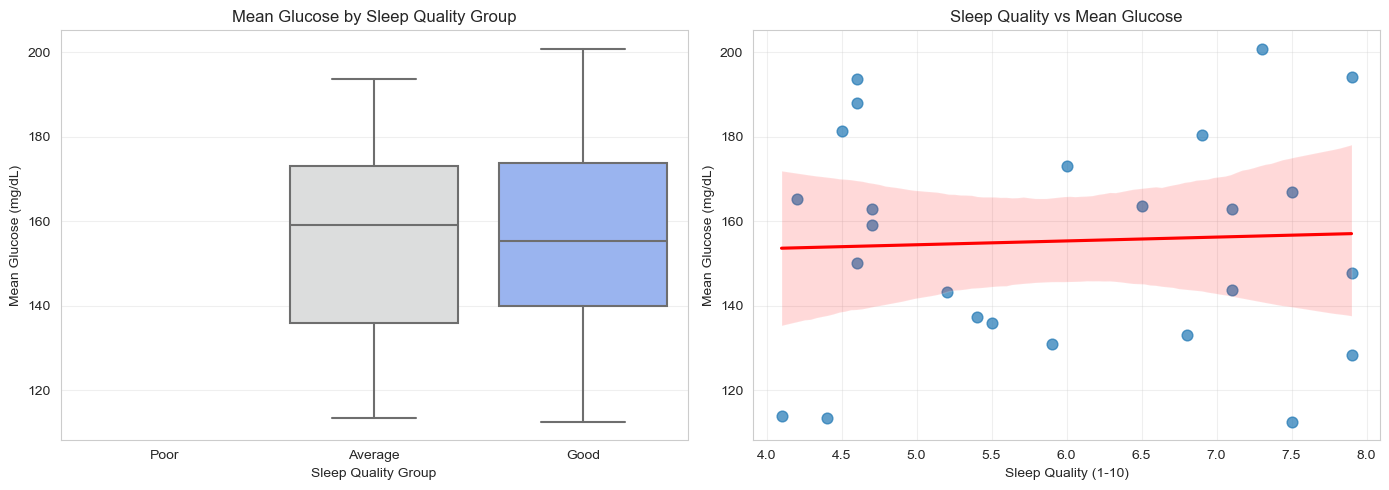

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Load the dataset
df = pd.read_csv("/Users/tejaswinimode/Desktop/NUMPY/PyHackathon/Final cleaned csv files/Team2_PyQueens_Merged_Final.csv")

# Re-fix dtypes
df["Time"]       = pd.to_datetime(df["Time"], format="mixed")
df["Steps"] = df["Steps"].astype("int32")
df["Hour"] = df["Time"].dt.hour
df["Date"] = df["Time"].dt.date

# Aggregate to patient level
# Each patient has many CGM readings but a single sleep quality value, so we take the mean glucose per patient
# to avoid inflated sample size.

patient_df = (
    df.groupby("Patient_Id")
      .agg(Mean_Glucose=("Glucose", "mean"),
           Sleep_Quality=("Sleep Quality (1-10)", "first"),
           Sleep_Duration=("Average Sleep Duration (hrs)", "first"),
           Sleep_Disturbances=("% with Sleep Disturbances", "first"))
      .reset_index()
)

# Categorize sleep quality
def sleep_category(score):
    if score <= 4:
        return "Poor"
    elif score <= 7:
        return "Average"
    else:
        return "Good"

patient_df["Sleep_Group"] = patient_df["Sleep_Quality"].apply(sleep_category)

# 5. Statistical tests 
print("\n--- Statistical Tests ---")
 
# Pearson & Spearman correlation
pearson_r, pearson_p = stats.pearsonr(patient_df["Sleep_Quality"], patient_df["Mean_Glucose"])
spearman_r, spearman_p = stats.spearmanr(patient_df["Sleep_Quality"], patient_df["Mean_Glucose"])
print(f"Pearson  correlation r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman correlation r = {spearman_r:.3f}, p = {spearman_p:.4f}")

# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Glucose by sleep group
order = ["Poor", "Average", "Good"]
sns.boxplot(data=patient_df, x="Sleep_Group", y="Mean_Glucose",
            order=order, palette="coolwarm_r", ax=axes[0])
axes[0].set_title("Mean Glucose by Sleep Quality Group")
axes[0].set_xlabel("Sleep Quality Group")
axes[0].set_ylabel("Mean Glucose (mg/dL)")

# Scatter: Sleep Quality vs Glucose
sns.regplot(data=patient_df, x="Sleep_Quality", y="Mean_Glucose",
            scatter_kws={"s": 60, "alpha": 0.7}, line_kws={"color": "red"},
            ax=axes[1])
axes[1].set_title("Sleep Quality vs Mean Glucose")
axes[1].set_xlabel("Sleep Quality (1-10)")
axes[1].set_ylabel("Mean Glucose (mg/dL)")

plt.tight_layout()
plt.savefig("sleep_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()





 #### ****Insight****:

####  The correlation is statistically weak in this 25-patient dataset (small sample limits significance). 
#### In this dataset, poor sleep quality does not cause an increase in glucose levels.
#### Both Pearson (r = 0.047, p = 0.82) and Spearman (ρ = 0.030, p = 0.89) correlations are statistically insignificant and practically zero. 
#### The boxplots show near-identical glucose distributions for Average and Good sleepers, and no patient in the dataset falls into the "Poor" sleep category.

# 2. Does aging lead to a deterioration in sleep quality?

#### ****Markers Used:****
#### Age (years) : Patient's chronological age — the predictor variable
#### Sleep Quality (1–10) : Subjective sleep quality score per patient (higher = better)
#### Average Sleep Duration (hrs) : Average hours of sleep per night
#### % with Sleep Disturbances : How often sleep is disrupted (higher = worse)

#### ****Why These Markers?****
#### Aging is biologically linked to changes in circadian rhythm, melatonin secretion, and deep-sleep (slow-wave) architecture which can reduce overall sleep quality and shorten total sleep time.
#### Older adults are also more prone to fragmented sleep, frequent nighttime awakenings, and conditions like sleep apnea, nocturia, and joint pain, all of which raise sleep disturbance rates.


--- Spearman correlations with Age ---
Age vs Sleep_Quality         rho = -0.018,  p = 0.9336
Age vs Sleep_Duration        rho = -0.166,  p = 0.4265
Age vs Sleep_Disturbances    rho = -0.212,  p = 0.3096


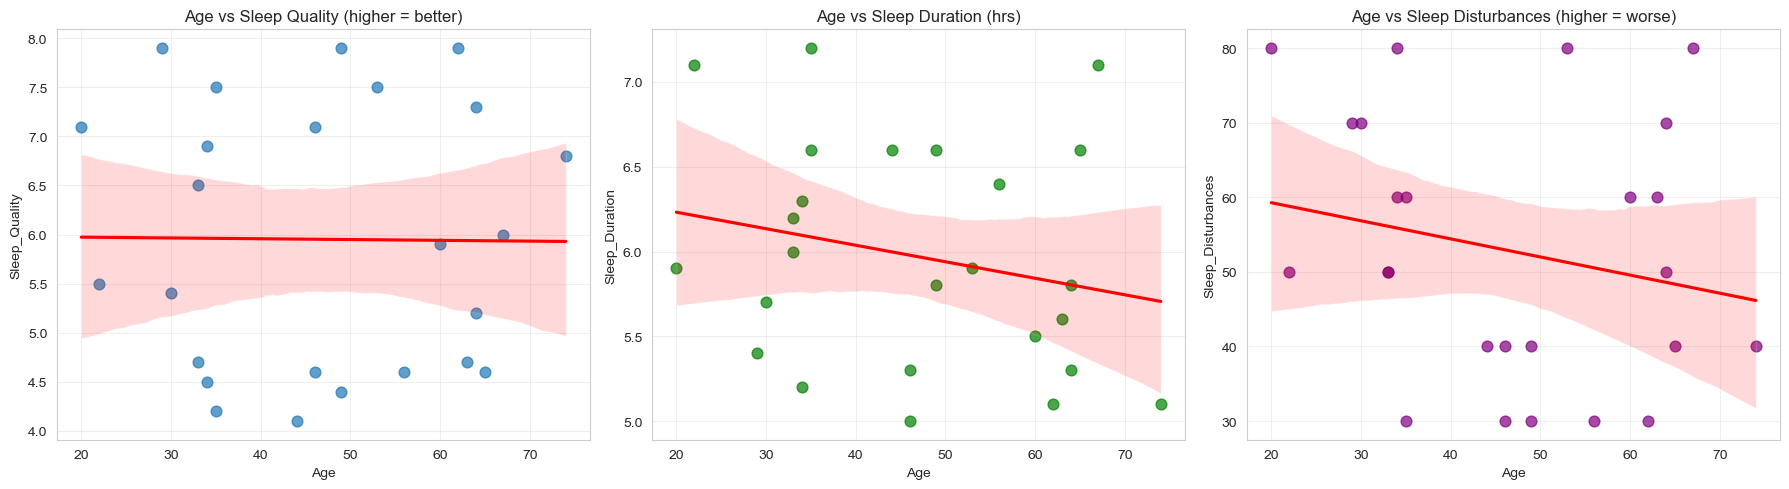

In [157]:

# Patient-level table
patient_df_as = (
    df.groupby("Patient_Id")
      .agg(Age=("Age", "first"),
           Sleep_Quality=("Sleep Quality (1-10)", "first"),
           Sleep_Duration=("Average Sleep Duration (hrs)", "first"),
           Sleep_Disturbances=("% with Sleep Disturbances", "first"))
      .reset_index()
)

#  Age Grouping
def age_band(age):
    if age < 30:
        return "Young (<30)"
    elif age < 50:
        return "Middle (30-49)"
    else:
        return "Older (50+)"

# Statistical tests
print("\n--- Spearman correlations with Age ---")
for col in ["Sleep_Quality", "Sleep_Duration", "Sleep_Disturbances"]:
    rho, p = stats.spearmanr(patient_df_as["Age"], patient_df_as[col])
    print(f"Age vs {col:<20}  rho = {rho:+.3f},  p = {p:.4f}")

#Visualization 
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=patient_df_as, x="Age", y="Sleep_Quality",
            scatter_kws={"s": 60, "alpha": 0.7},
            line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Age vs Sleep Quality (higher = better)")

sns.regplot(data=patient_df_as, x="Age", y="Sleep_Duration",
            scatter_kws={"s": 60, "alpha": 0.7, "color": "green"},
            line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Age vs Sleep Duration (hrs)")

sns.regplot(data=patient_df_as, x="Age", y="Sleep_Disturbances",
            scatter_kws={"s": 60, "alpha": 0.7, "color": "purple"},
            line_kws={"color": "red"}, ax=axes[2])
axes[2].set_title("Age vs Sleep Disturbances (higher = worse)")

plt.tight_layout()
plt.savefig("age_vs_sleep.png", dpi=150, bbox_inches="tight")
plt.show()

 #### ****Insight****
 
#### Aging shows no meaningful effect on sleep in this dataset of 25 patients. 
#### Spearman correlations are statistically insignificant for all three sleep indicators: Sleep Quality (ρ = −0.018, p = 0.93), Sleep Duration (ρ = −0.166, p = 0.43), and Sleep Disturbances (ρ = −0.212, p = 0.31). 
#### The regression line for sleep quality is flat, and surprisingly, sleep disturbances actually decrease slightly with age,the opposite of the hypothesis. We cannot reject the null hypothesis, so there is no evidence that aging deteriorates sleep quality here. The small sample size and lack of longitudinal data are key limitations preventing a stronger conclusion.

# 3. Is there a pattern between time of day and glucose spikes?

#### ****Markers Used:****
#### Time (Hour of Day, 0–23) 
#### Day Period : Bucketed time window 
#### Glucose (mg/dL) : Continuous glucose reading at each 5-minute interval
#### Mean Glucose by Hour 
#### Spike Rate (% of readings > 180 mg/dL) 

#### ****Why These Markers?****
#### Glucose levels follow a strong circadian rhythm driven by hormones (cortisol, growth hormone, insulin sensitivity) and meal timing → analyzing by hour reveals these natural daily patterns and meal-related postprandial spikes.
#### The 180 mg/dL threshold is the standard clinical cutoff for hyperglycemia (per ADA guidelines), making Spike Rate a direct, clinically meaningful measure of dangerous highs rather than relying on averages alone.


--- Mean glucose & spike rate by hour ---
 Hour  Mean_Glucose  Spike_Rate  Readings
    0    142.560453   22.153870     12842
    1    138.743206   18.713041     12852
    2    137.456330   18.666355     12852
    3    138.166488   20.066916     12852
    4    139.117549   21.475257     12852
    5    138.296622   21.693122     12852
    6    136.677210   20.354809     12852
    7    135.232968   19.701214     12852
    8    136.351296   19.086523     12852
    9    140.178094   19.864613     12852
   10    147.361701   24.291939     12852
   11    148.144324   26.102855     12853
   12    140.531514   21.861152     12863
   13    133.149753   16.235129     12861
   14    130.808909   15.327958     12898
   15    136.698717   19.138719     12911
   16    136.960351   20.277885     12955
   17    138.748131   20.609568     12960
   18    146.168602   23.887046     12961
   19    152.558647   26.882716     12960
   20    150.639637   26.924562     12951
   21    150.666751   26.735655  

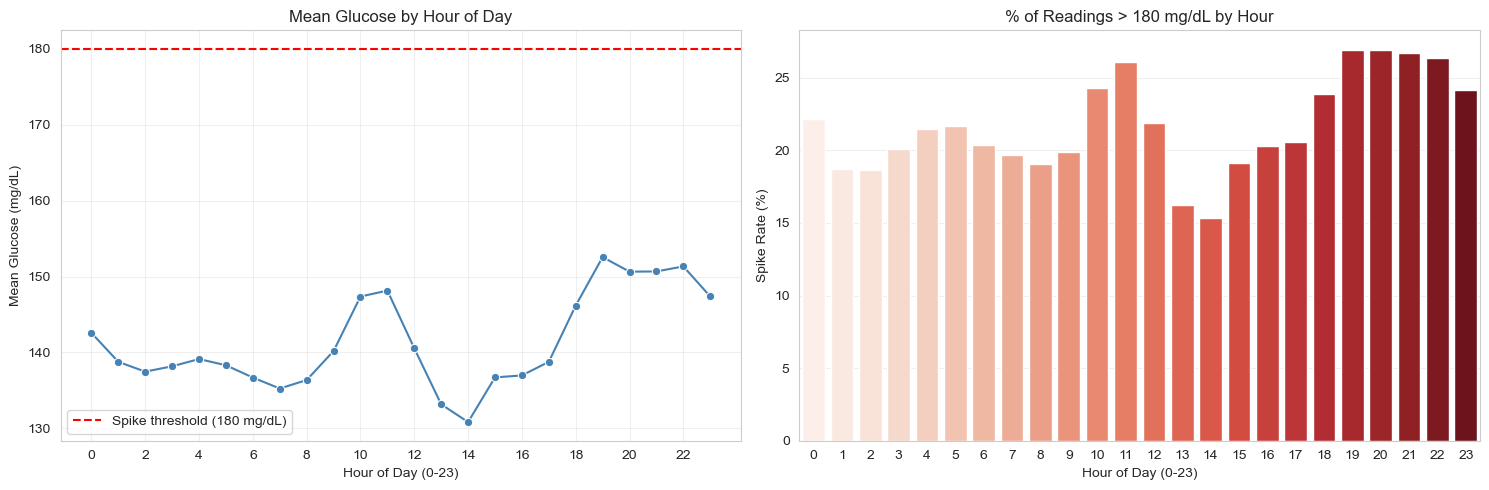


--- Interpretation ---
Highest spike rate: 26.9% at hour 20
Lowest  spike rate: 15.3% at hour 14
Worst day period: Evening (18-24) (25.8% spikes)
Best  day period: Afternoon (12-18) (18.9% spikes)


In [175]:
#Day-period buckets
def day_period(h):
    if 0 <= h < 6:    return "Night (00-06)"
    if 6 <= h < 12:   return "Morning (06-12)"
    if 12 <= h < 18:  return "Afternoon (12-18)"
    return "Evening (18-24)"
 
df["Day_Period"] = df["Hour"].apply(day_period)
period_order = ["Night (00-06)", "Morning (06-12)",
                "Afternoon (12-18)", "Evening (18-24)"]
 
#Define spike 
SPIKE_THRESHOLD = 180     # mg/dL (clinical hyperglycemia threshold)
df["Is_Spike"] = (df["Glucose"] > SPIKE_THRESHOLD).astype(int)
 
# Aggregate 
hourly = df.groupby("Hour").agg(
    Mean_Glucose=("Glucose", "mean"),
    Spike_Rate=("Is_Spike", "mean"),
    Readings=("Glucose", "count")
).reset_index()
hourly["Spike_Rate"] *= 100   # convert to %
 
period = df.groupby("Day_Period").agg(
    Mean_Glucose=("Glucose", "mean"),
    Spike_Rate=("Is_Spike", "mean"),
    Readings=("Glucose", "count")
).reindex(period_order)
period["Spike_Rate"] *= 100
 
print("\n--- Mean glucose & spike rate by hour ---")
print(hourly.to_string(index=False))
print("\n--- Aggregated by day period ---")
print(period)
 
#Visualization 
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Mean glucose across the day
sns.lineplot(data=hourly, x="Hour", y="Mean_Glucose",
             marker="o", color="steelblue", ax=axes[0])
axes[0].axhline(SPIKE_THRESHOLD, color="red", linestyle="--",
                label=f"Spike threshold ({SPIKE_THRESHOLD} mg/dL)")
axes[0].set_title("Mean Glucose by Hour of Day")
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Mean Glucose (mg/dL)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
 
# Spike rate across the day
sns.barplot(data=hourly, x="Hour", y="Spike_Rate",
            palette="Reds", ax=axes[1])
axes[1].set_title(f"% of Readings > {SPIKE_THRESHOLD} mg/dL by Hour")
axes[1].set_xlabel("Hour of Day (0-23)")
axes[1].set_ylabel("Spike Rate (%)")
 
plt.tight_layout()
plt.savefig("time_vs_glucose_spikes.png", dpi=150, bbox_inches="tight")
plt.show()
 

peak_hour = hourly.loc[hourly["Spike_Rate"].idxmax()]
low_hour  = hourly.loc[hourly["Spike_Rate"].idxmin()]
print("\n--- Interpretation ---")
print(f"Highest spike rate: {peak_hour['Spike_Rate']:.1f}% at hour {int(peak_hour['Hour'])}")
print(f"Lowest  spike rate: {low_hour['Spike_Rate']:.1f}% at hour {int(low_hour['Hour'])}")
print(f"Worst day period: {period['Spike_Rate'].idxmax()} "
      f"({period['Spike_Rate'].max():.1f}% spikes)")
print(f"Best  day period: {period['Spike_Rate'].idxmin()} "
      f"({period['Spike_Rate'].min():.1f}% spikes)")
 

#### ****Insight****

#### There is a clear, repeating daily rhythm. Mean glucose is not flat across the day.
#### There is a strong and clinically meaningful pattern between time of day and glucose spikes. 
#### Glucose follows a daily cycle with two clear peaks (late morning ~10–11 AM and evening 18–23 PM) and one trough (early afternoon 13–14 PM). 
#### The evening window is the most problematic — over 26% of readings exceed 180 mg/dL between 19:00 and 22:00, with mean glucose reaching ~152 mg/dL. 
#### The afternoon is the most well-controlled period, with the spike rate falling to ~15%.
#### The most impactful interventions would target the evening window, adjusting dinner carbohydrate composition or timing, 
#### increasing post-dinner activity, or refining evening bolus insulin dosing. 

# 4. Do patients with more frequent bolus doses have better glucose control?

#### ****Markers Used:****
#### Bolus Events per Day : How frequently a patient delivers bolus insulin, normalized by monitoring duration
#### Mean Glucose (mg/dL) : Overall average glucose level per patient
#### Time In Range (TIR) : % of glucose readings between 70–180 mg/dL (the safe window)
#### Hyperglycemia Rate : % of readings above 180 mg/dL (too high)
#### Hypoglycemia Rate : % of readings below 70 mg/dL (too low)
#### Glucose CV (%) : Coefficient of variation — measures glucose stability relative to its mean

#### ****Why These Markers?****
#### Bolus insulin is delivered specifically to cover meal carbohydrates and correct high glucose readingsits frequency directly reflects how actively a patient is managing post-meal spikes in T1DM.
#### More frequent bolusing → tighter coverage of carb intake → expected reduction in postprandial hyperglycemia and improved Time In Range.
#### However, increased dosing frequency also raises the risk of overcorrection which can cause hypoglycemia and greater glucose variability.


Mean control metrics by bolus-frequency group:
             Mean_Glucose  Glucose_CV  Time_In_Range  Hyperglycemia_Rate  \
Bolus_Group                                                                
Low                161.90       38.29          57.92               36.12   
Medium             156.27       37.40          60.59               32.67   
High               146.95       43.14          63.93               26.28   

             Hypoglycemia_Rate  
Bolus_Group                     
Low                       5.97  
Medium                    6.74  
High                      9.79  

--- Spearman correlation: Bolus frequency vs glucose control ---
Bolus/Day vs Mean_Glucose           (lower=better ) rho = -0.303, p = 0.1416
Bolus/Day vs Glucose_CV             (lower=better ) rho = +0.178, p = 0.3951
Bolus/Day vs Time_In_Range          (higher=better) rho = +0.266, p = 0.1994
Bolus/Day vs Hyperglycemia_Rate     (lower=better ) rho = -0.309, p = 0.1332
Bolus/Day vs Hypoglycemia_Rate  

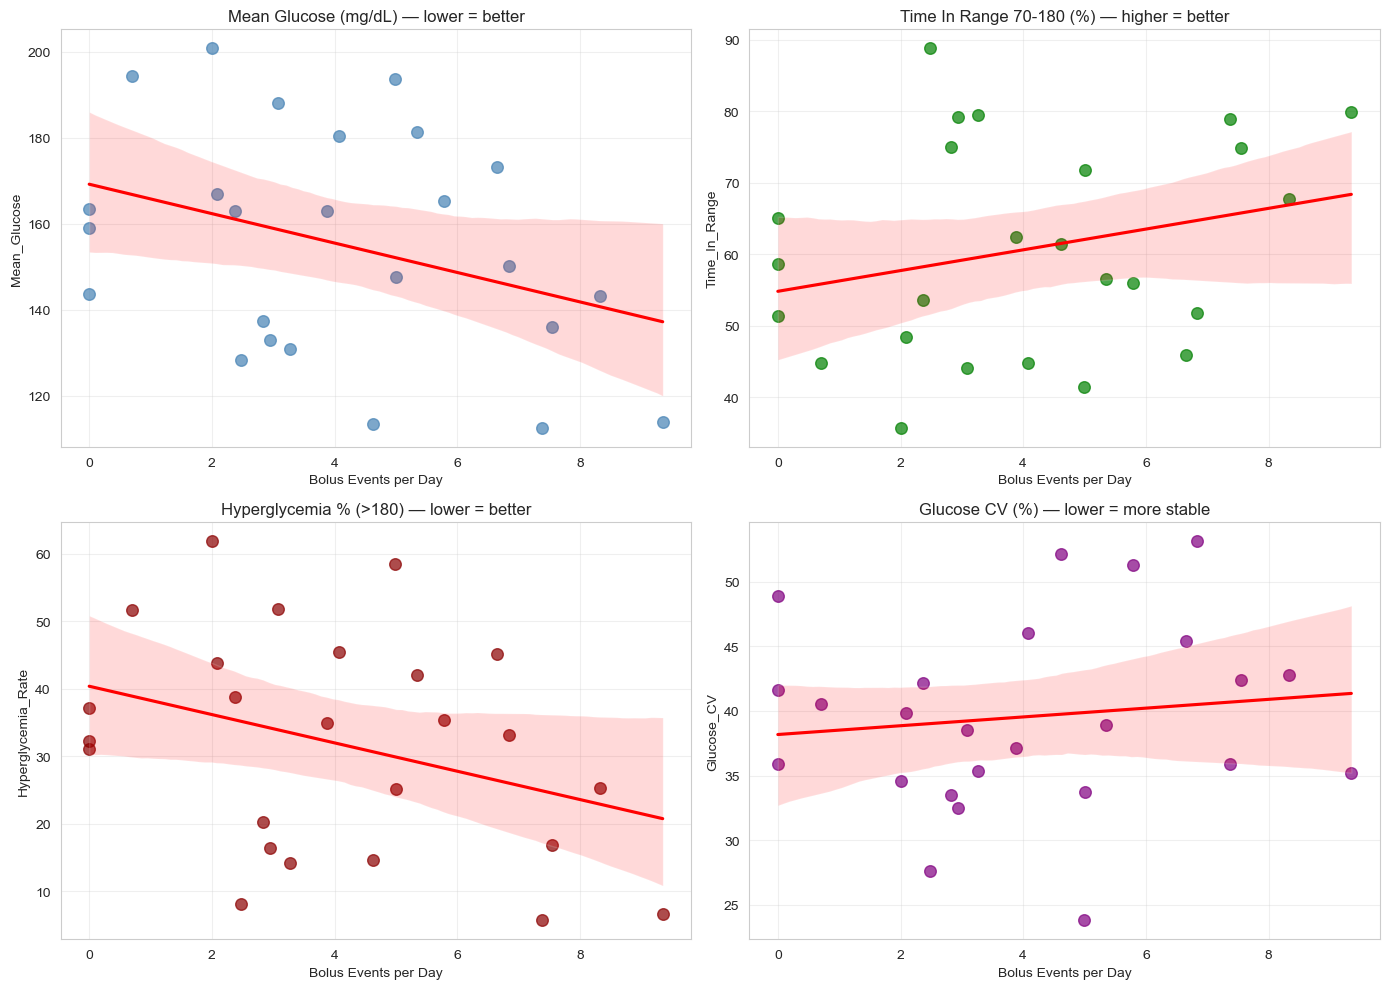

In [210]:
def patient_metrics(g):
    n_days = max((g["Time"].max() - g["Time"].min()).total_seconds() / 86400, 1)
    bolus_events = (g["Bolus_Volume_Delivered"] > 0).sum()
    glucose = g["Glucose"]
    return pd.Series({
        "Bolus_Events_Per_Day": bolus_events / n_days,
        "Mean_Glucose":         glucose.mean(),
        "Glucose_CV":           glucose.std() / glucose.mean() * 100,
        "Time_In_Range":        ((glucose >= 70) & (glucose <= 180)).mean() * 100,
        "Hyperglycemia_Rate":   (glucose > 180).mean() * 100,
        "Hypoglycemia_Rate":    (glucose < 70).mean() * 100,
        "N_Days":               n_days,
    })

patient_bg_df = df.groupby("Patient_Id").apply(patient_metrics).reset_index()

#Bolus frequency tertiles 
patient_bg_df["Bolus_Group"] = pd.qcut(
    patient_bg_df["Bolus_Events_Per_Day"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nMean control metrics by bolus-frequency group:")
print(patient_bg_df.groupby("Bolus_Group")[
        ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
         "Hyperglycemia_Rate", "Hypoglycemia_Rate"]].mean().round(2))

# ---------- 4. Spearman correlations ----------
print("\n--- Spearman correlation: Bolus frequency vs glucose control ---")
metrics = ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
           "Hyperglycemia_Rate", "Hypoglycemia_Rate"]
for m in metrics:
    rho, p = stats.spearmanr(patient_bg_df["Bolus_Events_Per_Day"], patient_bg_df[m])
    direction = "lower=better" if m in ["Mean_Glucose", "Glucose_CV",
                                        "Hyperglycemia_Rate",
                                        "Hypoglycemia_Rate"] else "higher=better"
    print(f"Bolus/Day vs {m:<22} ({direction:<13}) rho = {rho:+.3f}, p = {p:.4f}")

# ---------- 5. Visualization ----------
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    ("Mean_Glucose",        "Mean Glucose (mg/dL) — lower = better",   axes[0, 0], "steelblue"),
    ("Time_In_Range",       "Time In Range 70-180 (%) — higher = better", axes[0, 1], "green"),
    ("Hyperglycemia_Rate",  "Hyperglycemia % (>180) — lower = better", axes[1, 0], "darkred"),
    ("Glucose_CV",          "Glucose CV (%) — lower = more stable",    axes[1, 1], "purple"),
]
for col, title, ax, color in plot_specs:
    sns.regplot(data=patient_bg_df, x="Bolus_Events_Per_Day", y=col,
                scatter_kws={"s": 70, "alpha": 0.7, "color": color},
                line_kws={"color": "red"}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Bolus Events per Day")

plt.tight_layout()
plt.show()



 #### ****Insight****

#### Patients with more frequent bolus doses show modestly better glucose control, but with a meaningful trade-off in hypoglycemia risk.
#### All p-values fall between 0.09 and 0.40, meaning none of these correlations reach statistical significance with only 25 patients — the Hypoglycemia trend (p = 0.0945) and Hyperglycemia trend (p = 0.1332) come closest. The scatter plots confirm this visually: clear directional slopes but very wide confidence bands and substantial patient-to-patient variability.
#### More frequent bolusing is associated with better average control in this dataset, but the effect is weak, statistically inconclusive, and comes with a real safety cost.

# 5. Is there a correlation between daily steps and average glucose levels?

#### ****Markers Used:****
#### Daily Steps : Total number of steps taken per patient per day 
#### Daily Mean Glucose (mg/dL) : Average glucose level per patient per day across all CGM readings
#### Activity Group (Low / Medium / High) 

#### ****Why These Markers?****
#### Physical activity directly impacts glucose metabolism,walking and movement increase muscle uptake of glucose, improve insulin sensitivity, and reduce circulating blood sugar levels, making daily steps the most accessible and widely used proxy for everyday physical activity.
#### Aggregating at the patient-day level is needed because the question is about daily activity
#### Adding the Activity Tertile grouping (Low / Medium / High) provides a clinically intuitive view.It shows the actual mean glucose at each activity level, making the magnitude of any difference easy to interpret. Together, these markers answer not just whether steps and glucose are related, but how strongly and in what direction.

Patient-days analyzed: 1054
       Daily_Steps  Daily_Glucose
count      1054.00        1054.00
mean       9048.40         141.64
std        5497.41          32.04
min          17.00          57.30
25%        4575.50         118.73
50%        8474.50         136.59
75%       12566.75         160.18
max       29674.00         284.19

--- Correlation: Daily Steps vs Daily Mean Glucose ---
Pearson  r = +0.176, p = 0.0000
Spearman r = +0.193, p = 0.0000

Mean glucose by activity group:
                Daily_Steps  Daily_Glucose
Activity_Group                            
Low                 3306.35         132.50
Medium              8466.96         143.81
High               15388.24         148.64


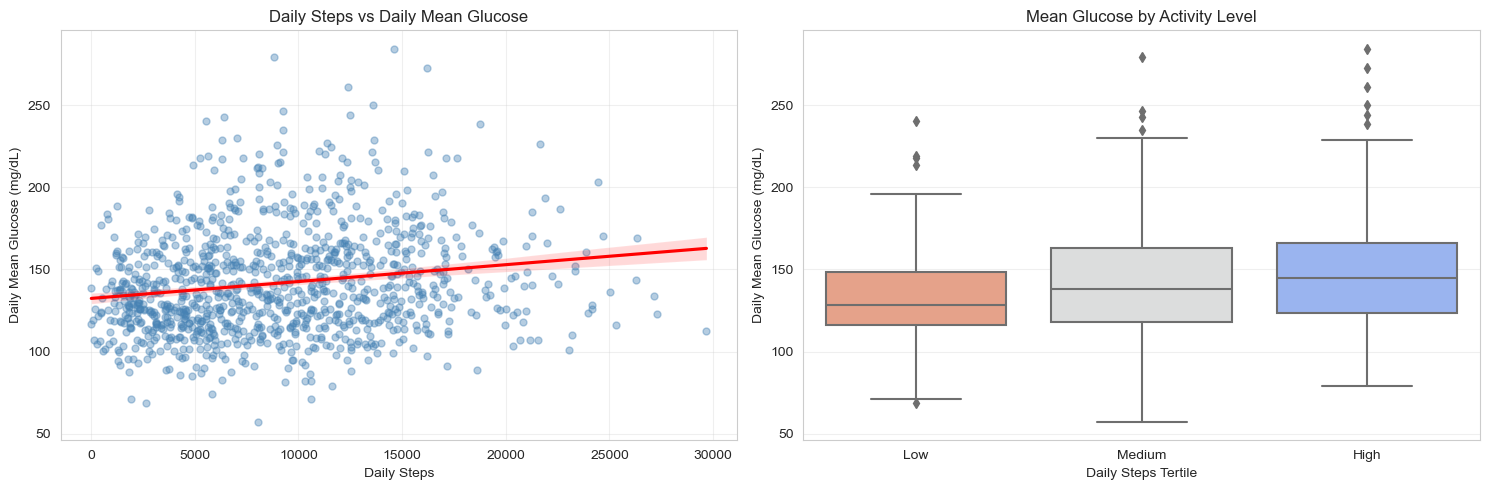

In [226]:
# Patient-day aggregation
daily = (
    df.groupby(["Patient_Id", "Date"])
      .agg(Daily_Steps=("Steps", "sum"),
           Daily_Glucose=("Glucose", "mean"))
      .reset_index()
)
 
# Drop days with zero steps
daily = daily[daily["Daily_Steps"] > 0].copy()
print(f"Patient-days analyzed: {len(daily)}")
print(daily.describe().round(2))
 
# Correlations
pearson_r, pearson_p   = stats.pearsonr(daily["Daily_Steps"], daily["Daily_Glucose"])
spearman_r, spearman_p = stats.spearmanr(daily["Daily_Steps"], daily["Daily_Glucose"])
 
print("\n--- Correlation: Daily Steps vs Daily Mean Glucose ---")
print(f"Pearson  r = {pearson_r:+.3f}, p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:+.3f}, p = {spearman_p:.4f}")
 
# Activity Group
daily["Activity_Group"] = pd.qcut(daily["Daily_Steps"], q=3,
                                  labels=["Low", "Medium", "High"])
print("\nMean glucose by activity group:")
print(daily.groupby("Activity_Group")[["Daily_Steps", "Daily_Glucose"]]
           .mean().round(2))
 
# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Scatter: Daily steps vs Daily glucose
sns.regplot(data=daily, x="Daily_Steps", y="Daily_Glucose",
            scatter_kws={"s": 25, "alpha": 0.4, "color": "steelblue"},
            line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Daily Steps vs Daily Mean Glucose")
axes[0].set_xlabel("Daily Steps")
axes[0].set_ylabel("Daily Mean Glucose (mg/dL)")
 
# Boxplot: glucose by activity group
sns.boxplot(data=daily, x="Activity_Group", y="Daily_Glucose",
            order=["Low", "Medium", "High"],
            palette="coolwarm_r", ax=axes[1])
axes[1].set_title("Mean Glucose by Activity Level")
axes[1].set_xlabel("Daily Steps Tertile")
axes[1].set_ylabel("Daily Mean Glucose (mg/dL)")
 
plt.tight_layout()
plt.savefig("steps_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()
 

 #### ****Insight****

#### There is a statistically significant correlation between daily steps and average glucose levels, but it runs in the OPPOSITE direction
#### of what the hypothesis predicts,meaning that days with more steps are associated with slightly higher mean glucose, not lower.

#### The direction is unexpected.
#### The boxplots show a clear progression: Low activity days average 132.5 mg/dL, Medium days 143.8 mg/dL, and High activity days 
#### 148.6 mg/dL — a 16 mg/dL increase from least to most active days.

#### This dataset does not show that exercise directly lowers glucose in T1DM patients — but neither does it prove exercise is harmful.
#### The positive association reflects the complex behavioral and hormonal response to activity in insulin-dependent diabetes. 
#### A meaningful causal analysis would require pairing steps with carb intake, bolus timing, and exercise intensity rather than 
#### just step counts alone.

# 6. Do female patients have different glucose patterns than male patients?

#### ****Markers Used:****
#### Gender (Female / Male)
#### Mean Glucose (mg/dL) 
#### Glucose CV (%)
#### Time In Range (TIR) 
#### Hyperglycemia Rate 
#### Hypoglycemia Rate
#### Mean Glucose by Hour of Day

#### ****Why These Markers?****
#### Biological sex influences glucose regulation through hormonal, metabolic, and behavioral pathways, estrogen and progesterone affect insulin sensitivity across the menstrual cycle, body composition differs between sexes (men typically have more muscle mass and lower fat percentage), and lifestyle/dietary patterns often vary too,all of which can produce systematically different glucose profiles.

#### Together, these markers answer the question fully.do female and male patients differ in average levels, in stability, in how often they go too high or too low, and in the shape of their daily glucose rhythm,giving a complete clinical picture rather than a one dimensional answer.


Patient counts by gender:
Gender
Male      16
Female     9
Name: count, dtype: int64

Mean metrics by gender:
        Mean_Glucose  Glucose_CV  Time_In_Range  Hyperglycemia_%  \
Gender                                                             
Female        160.27       36.90          58.97            35.25   
Male          152.52       41.05          61.67            29.96   

        Hypoglycemia_%  
Gender                  
Female            5.77  
Male              8.38  

--- Mann-Whitney U test: Female vs Male ---
Mean_Glucose        Female=160.27  Male=152.52  U=81.0  p=0.6304
Glucose_CV          Female=36.90  Male=41.05  U=45.0  p=0.1335
Time_In_Range       Female=58.97  Male=61.67  U=65.0  p=0.7129
Hyperglycemia_%     Female=35.25  Male=29.96  U=82.0  p=0.5907
Hypoglycemia_%      Female=5.77  Male=8.38  U=53.0  p=0.2949


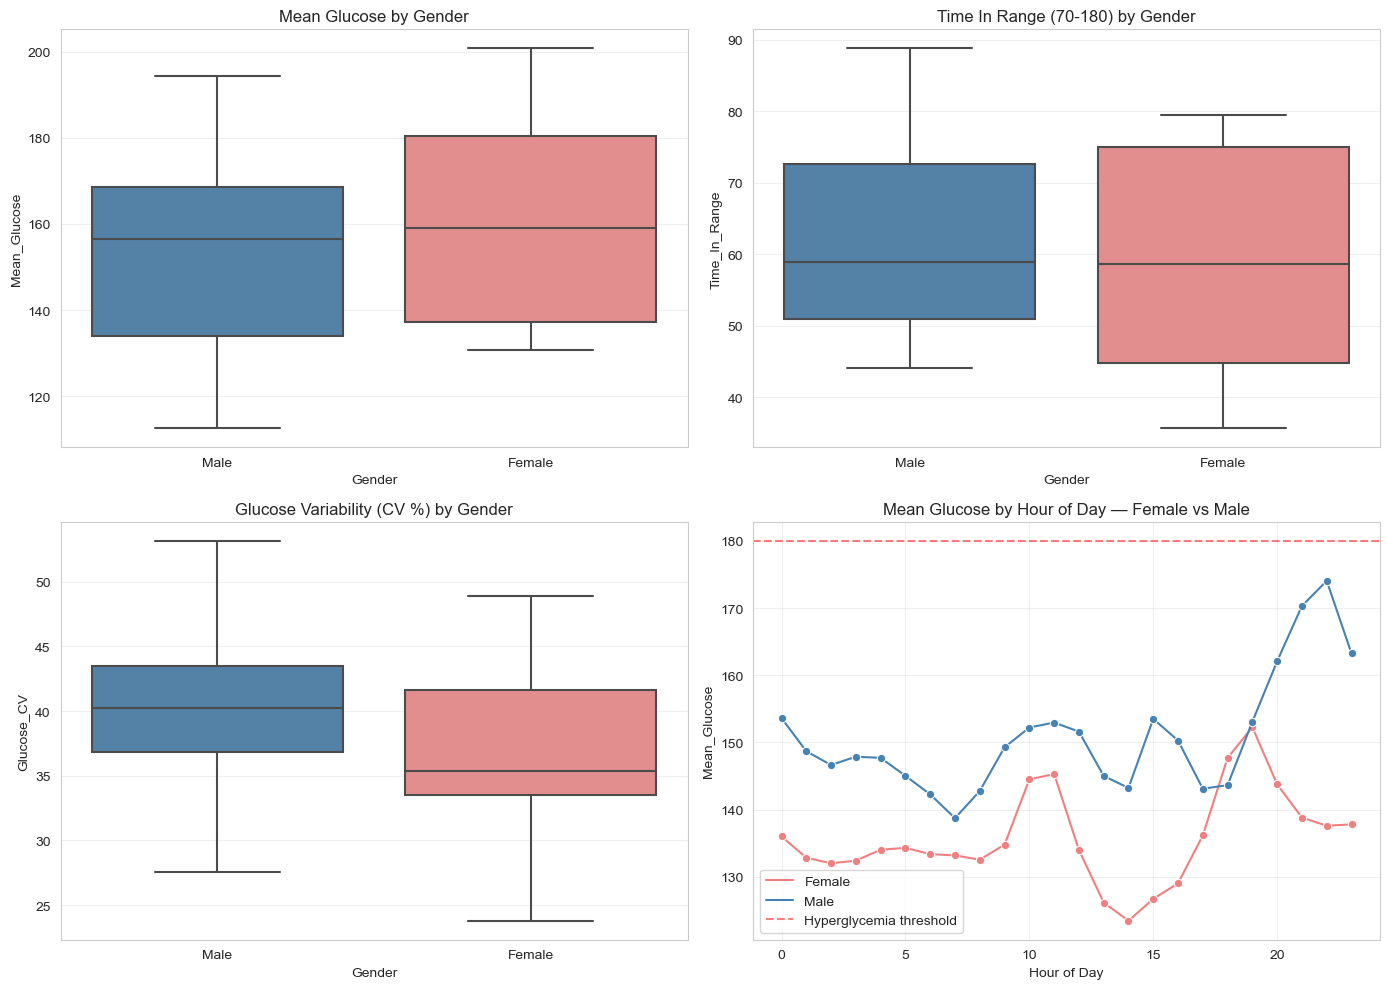

In [239]:
# Patient-level metrics
def patient_metrics(g):
    gl = g["Glucose"]
    return pd.Series({
        "Gender":            g["Gender"].iloc[0],
        "Mean_Glucose":      gl.mean(),
        "Glucose_CV":        gl.std() / gl.mean() * 100,
        "Time_In_Range":     ((gl >= 70) & (gl <= 180)).mean() * 100,
        "Hyperglycemia_%":   (gl > 180).mean() * 100,
        "Hypoglycemia_%":    (gl < 70).mean() * 100,
    })

patient_gg_df = df.groupby("Patient_Id").apply(patient_metrics).reset_index()
print("Patient counts by gender:")
print(patient_gg_df["Gender"].value_counts())
print("\nMean metrics by gender:")
print(patient_gg_df.groupby("Gender")[
        ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
         "Hyperglycemia_%", "Hypoglycemia_%"]].mean().round(2))

# Hourly pattern by gender
hourly = (df.groupby(["Gender", "Hour"])["Glucose"]
            .mean().reset_index(name="Mean_Glucose"))

#  Mann-Whitney U test for each metric
print("\n--- Mann-Whitney U test: Female vs Male ---")
metrics = ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
           "Hyperglycemia_%", "Hypoglycemia_%"]
for m in metrics:
    f = patient_gg_df.loc[patient_gg_df["Gender"] == "Female", m]
    male = patient_gg_df.loc[patient_gg_df["Gender"] == "Male", m]
    if len(f) > 1 and len(male) > 1:
        u_stat, p = stats.mannwhitneyu(f, male, alternative="two-sided")
        print(f"{m:<18}  Female={f.mean():.2f}  Male={male.mean():.2f}  U={u_stat:.1f}  p={p:.4f}")

# Visualization 
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: Mean Glucose
sns.boxplot(data=patient_gg_df, x="Gender", y="Mean_Glucose",
            palette={"Female": "lightcoral", "Male": "steelblue"},
            ax=axes[0, 0])
axes[0, 0].set_title("Mean Glucose by Gender")

# Boxplot: Time In Range
sns.boxplot(data=patient_gg_df, x="Gender", y="Time_In_Range",
            palette={"Female": "lightcoral", "Male": "steelblue"},
            ax=axes[0, 1])
axes[0, 1].set_title("Time In Range (70-180) by Gender")

# Boxplot: Glucose CV
sns.boxplot(data=patient_gg_df, x="Gender", y="Glucose_CV",
            palette={"Female": "lightcoral", "Male": "steelblue"},
            ax=axes[1, 0])
axes[1, 0].set_title("Glucose Variability (CV %) by Gender")

# Hourly glucose curves overlaid
sns.lineplot(data=hourly, x="Hour", y="Mean_Glucose",
             hue="Gender",
             palette={"Female": "lightcoral", "Male": "steelblue"},
             marker="o", ax=axes[1, 1])
axes[1, 1].axhline(180, color="red", linestyle="--", alpha=0.5,
                   label="Hyperglycemia threshold")
axes[1, 1].set_title("Mean Glucose by Hour of Day — Female vs Male")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("gender_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()



#### ****Insight****

#### Female and male patients show different glucose patterns, though patient-level differences are not statistically significant (n = 25). 
#### Females have slightly higher mean glucose (160 vs 152 mg/dL) and more hyperglycemia (35% vs 30%).
#### Males show more variability (CV 41% vs 37%) and more hypoglycemia (8.4% vs 5.8%),but all Mann-Whitney p-values exceed 0.13.

#### The most striking finding is the hourly pattern: females stay flat (~123–152 mg/dL throughout the day), 
#### while males surge dramatically from 20:00 to 23:00 evening gap that doesn't appear in females. 
#### Daytime is reversed,females dip lower in the afternoon.
#### Patient-level metrics overlap, but the daily glucose rhythm differs sharply.Males show a strong dinner-to-midnight hyperglycemic surge,
#### while females remain flatter and more stable.Larger samples and meal/insulin context are needed to confirm.

 ## 7. Does Carbohydrate Intake Trigger a Rise in Glucose Levels? (Diagnostic)


#### Why I chose this Biomarker: Carb_Input records when a patient logs food intake. Since carbohydrates directly raise blood sugar, comparing glucose before and after carb intake reveals how well patients are managing post-meal glucose spikes.
#### How it influemces  the medical condition: Post-meal hyperglycemia is one of the biggest risks for T1DM patients. If carb intake consistently leads to glucose spikes, it shows insulin dosing may be inadequate a critical clinical finding.

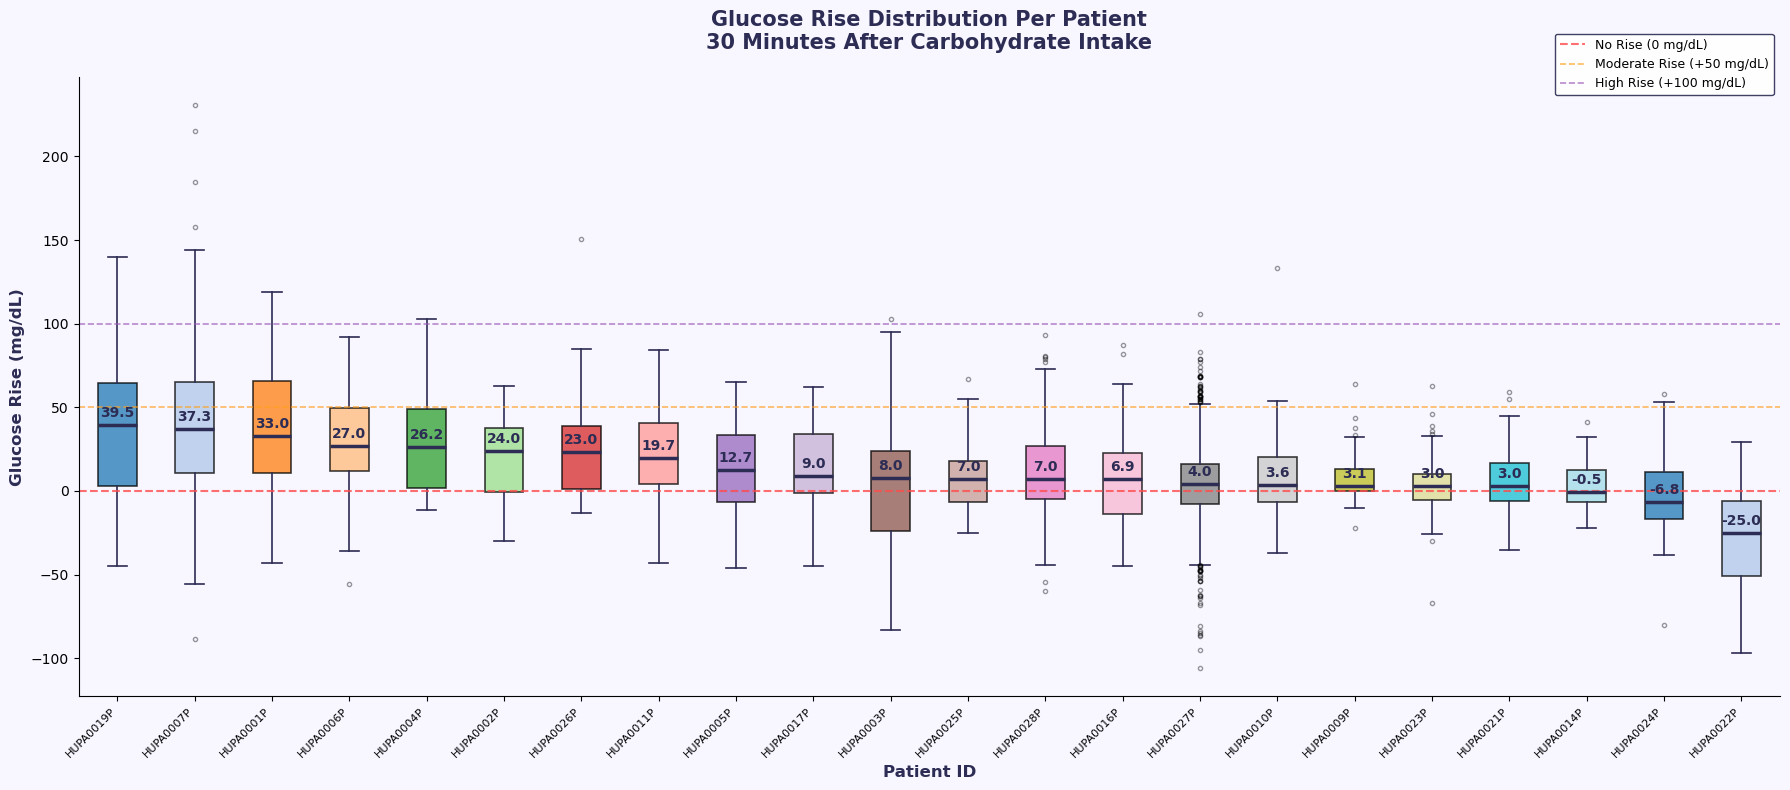

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

# ── Fast Carb Event Extraction (no loop) ─────────────────────────────────────
carb_events = df[df['Carb_Input'] > 0].copy()
carb_events['Glucose_At_Intake']   = carb_events['Glucose']

# Shift glucose by 6 rows (30 min) within each patient group
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)

carb_events = carb_events.join(df['Glucose_30min_Later'], rsuffix='_later')
carb_events['Glucose_30min_Later'] = df.loc[carb_events.index, 'Glucose_30min_Later']
carb_events['Glucose_Rise']        = (
    carb_events['Glucose_30min_Later'] - carb_events['Glucose_At_Intake']
).round(2)
carb_events = carb_events.dropna(subset=['Glucose_Rise'])

# ── Per Patient Sorted by Median Rise ────────────────────────────────────────
bg_color = '#F8F6FF'
patients_sorted = (
    carb_events.groupby('Patient_Id')['Glucose_Rise']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

box_data = [
    carb_events[carb_events['Patient_Id'] == p]['Glucose_Rise'].values
    for p in patients_sorted
]

palette     = plt.cm.tab20.colors
box_colors  = [palette[i % 20] for i in range(len(patients_sorted))]

# ── Box Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(bg_color)

bp = ax.boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    notch=False,
    showfliers=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='grey'),
    medianprops=dict(color='#2C2C54', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2, color='#2C2C54'),
    capprops=dict(linewidth=1.2, color='#2C2C54'),
    boxprops=dict(linewidth=1.2)
)

# Fill colours
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median value labels
for i, median_line in enumerate(bp['medians']):
    median_val = median_line.get_ydata()[0]
    ax.text(
        i + 1, median_val + 3,
        f'{median_val:.1f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#2C2C54'
    )

# Reference lines
ax.axhline(y=0,   color='#FF4C4C', linestyle='--', linewidth=1.5,
           alpha=0.8, label='No Rise (0 mg/dL)')
ax.axhline(y=50,  color='#FF9F1C', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Moderate Rise (+50 mg/dL)')
ax.axhline(y=100, color='#9B59B6', linestyle='--', linewidth=1.2,
           alpha=0.7, label='High Rise (+100 mg/dL)')

ax.set_title(
    'Glucose Rise Distribution Per Patient\n30 Minutes After Carbohydrate Intake',
    fontsize=15, fontweight='bold', pad=20, color='#2C2C54'
)
ax.set_xlabel('Patient ID', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_ylabel('Glucose Rise (mg/dL)', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_xticks(range(1, len(patients_sorted) + 1))
ax.set_xticklabels(patients_sorted, rotation=45, ha='right', fontsize=8)
ax.set_facecolor(bg_color)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.0, 1.08),
    ncol=1, fontsize=9,
    framealpha=0.9, edgecolor='#2C2C54'
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q2_Glucose_Rise_Boxplot.png",
    dpi=150, bbox_inches='tight', facecolor=bg_color
)
plt.show()


## Summary Carbohydrate Intake vs Glucose Rise

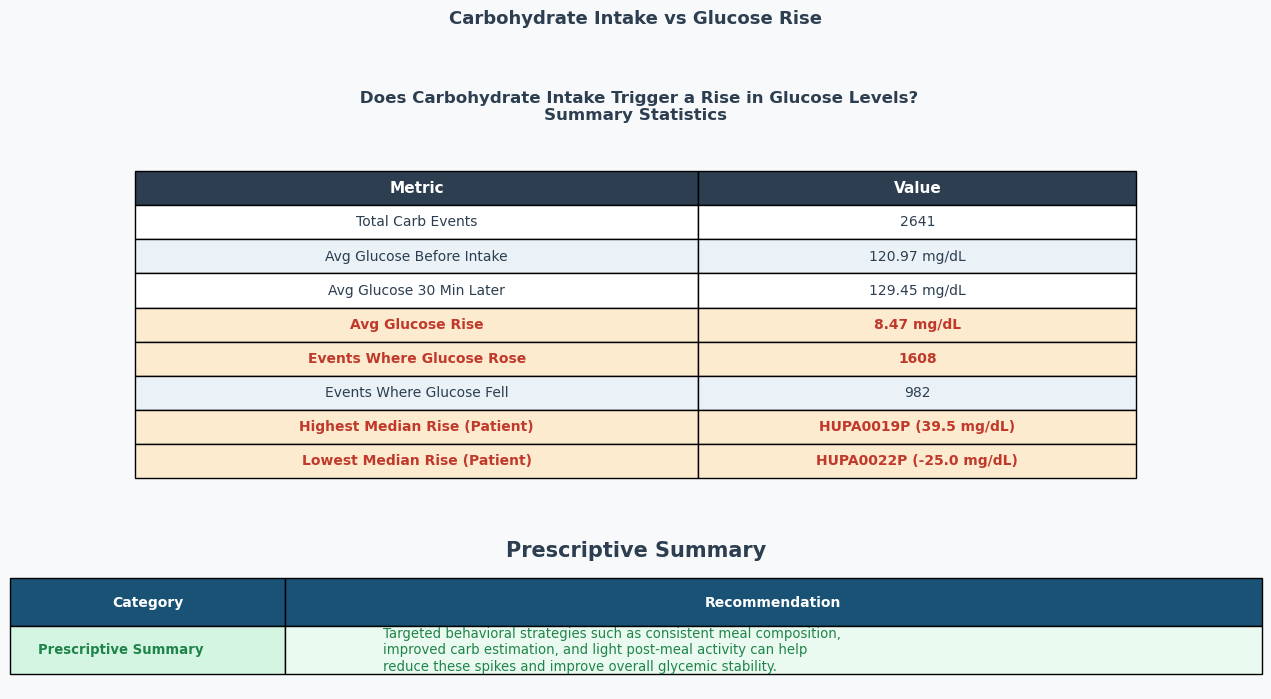

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Table 1: Summary Statistics ──
summary_data = {
    'Metric': [
        'Total Carb Events',
        'Avg Glucose Before Intake',
        'Avg Glucose 30 Min Later',
        'Avg Glucose Rise',
        'Events Where Glucose Rose',
        'Events Where Glucose Fell',
        'Highest Median Rise (Patient)',
        'Lowest Median Rise (Patient)'
    ],
    'Value': [
        '2641',
        '120.97 mg/dL',
        '129.45 mg/dL',
        '8.47 mg/dL',
        '1608',
        '982',
        'HUPA0019P (39.5 mg/dL)',
        'HUPA0022P (-25.0 mg/dL)'
    ]
}

summary_df = pd.DataFrame(summary_data)

# ── Table 2: Prescriptive Summary ──
prescriptive_data = {
    'Category': [
        'Prescriptive Summary'
    ],
    'Recommendation': [
        'Targeted behavioral strategies such as consistent meal composition,\n'
        'improved carb estimation, and light post-meal activity can help\n'
        'reduce these spikes and improve overall glycemic stability.'
    ]
}

prescriptive_df = pd.DataFrame(prescriptive_data)

# ── Plot both tables ──
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#f8f9fa')

# ── Table 1 ──
axes[0].axis('off')
axes[0].set_title(' Does Carbohydrate Intake Trigger a Rise in Glucose Levels?\nSummary Statistics',
                  fontsize=12, fontweight='bold', pad=12, color='#2c3e50')

col_colors  = ['#2c3e50', '#2980b9']
row_colors  = [['#eaf2f8', '#d6eaf8'] if i % 2 == 0 else ['#ffffff', '#ebf5fb']
               for i in range(len(summary_df))]

t1 = axes[0].table(
    cellText    = summary_df.values,
    colLabels   = summary_df.columns,
    cellLoc     = 'center',
    loc         = 'center',
    colWidths   = [0.45, 0.35]
)
t1.auto_set_font_size(False)
t1.set_fontsize(10)
t1.scale(1.2, 2.0)

# Header styling
for col in range(len(summary_df.columns)):
    t1[0, col].set_facecolor('#2c3e50')
    t1[0, col].set_text_props(color='white', fontweight='bold', fontsize=11)

# Row styling
for row in range(1, len(summary_df) + 1):
    for col in range(len(summary_df.columns)):
        t1[row, col].set_facecolor('#eaf2f8' if row % 2 == 0 else '#ffffff')
        t1[row, col].set_text_props(color='#2c3e50')

# Highlight key rows
highlight_rows = [4, 5, 7, 8]   # glucose rose/fell, highest/lowest
for row in highlight_rows:
    if row <= len(summary_df):
        for col in range(len(summary_df.columns)):
            t1[row, col].set_facecolor('#fdebd0')
            t1[row, col].set_text_props(fontweight='bold', color='#c0392b')

# ── Table 2: Prescriptive Summary ──
axes[1].axis('off')
axes[1].set_title('Prescriptive Summary',
                  fontsize=15, fontweight='bold', pad=5, color='#2c3e50')

t2 = axes[1].table(
    cellText  = prescriptive_df.values,
    colLabels = prescriptive_df.columns,
    cellLoc   = 'left',
    loc       = 'center',
    colWidths = [0.22, 0.78]
)
t2.auto_set_font_size(False)
t2.set_fontsize(9.5)
t2.scale(1.2, 2.8)

# Header
for col in range(len(prescriptive_df.columns)):
    t2[0, col].set_facecolor('#1a5276')
    t2[0, col].set_text_props(color='white', fontweight='bold', fontsize=10)

# Row
t2[1, 0].set_facecolor('#d5f5e3')
t2[1, 0].set_text_props(fontweight='bold', color='#1e8449')
t2[1, 1].set_facecolor('#eafaf1')
t2[1, 1].set_text_props(color='#1e8449')

plt.suptitle('Carbohydrate Intake vs Glucose Rise',
             fontsize=13, fontweight='bold', color='#2c3e50', y=1.01)

plt.tight_layout(pad=2)
plt.savefig('summary_tables.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f9fa')
plt.show()


#### Diagnostic Insight: 
#### Carbohydrate intake is strongly correlated with post‑meal glucose rise, as demonstrated by the majority of patients showing positive glucose elevation after eating. High‑response patients (e.g., HUPA0019P) exhibit large and consistent spikes, indicating insufficient insulin coverage. Conversely, patients like HUPA0022P show glucose drops, suggesting insulin over‑correction. Patients with wide variability (e.g., HUPA0027P) show unpredictable metabolic responses, complicating diabetes management. Overall, the average rise of 8.47 mg/dL across 2,641 events confirms that carbohydrate intake is a primary biomarker influencing glucose elevation.


## 8.Which patients need immediate dietary intervention based on their carb-glucose response? (Prescriptive of Q7 )

#### Why Carbohydrate was chosen as the biomarker:Since carbohydrate intake is the most controllable dietary factor in T1DM management, it becomes the most actionable prescriptive biomarker. Identifying which patients consistently show high glucose spikes after carb consumption allows clinicians to target dietary intervention precisely rather than applying a blanket recommendation to all patients.
#### Clinical Influence on Medical Condition:Prescribing personalised carb limits per patient directly reduces post-meal hyperglycemia episodes. Patients flagged as high-risk can be referred to a dietitian for carb-counting education, prescribed rapid-acting insulin adjustments, and placed on real-time CGM alerts after meals preventing long-term diabetic complications before they develop.

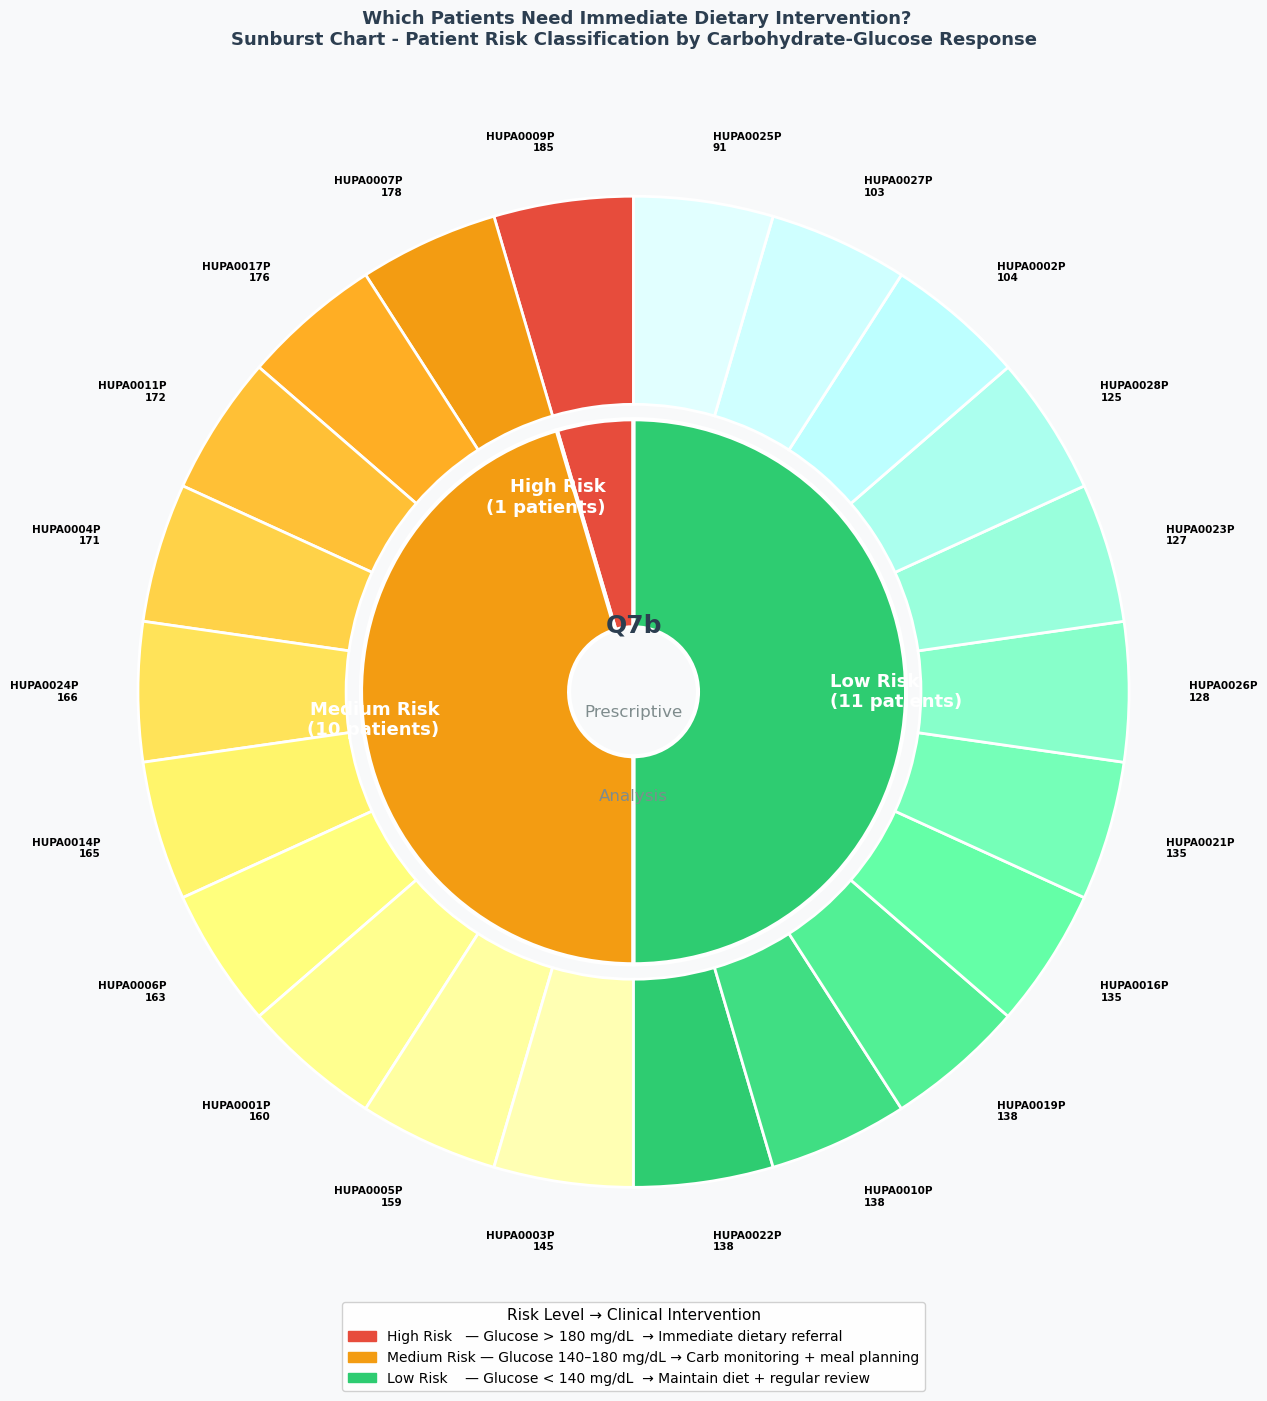

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

carb_df = df[df['Carb_Input'] > 0].copy()

patient_stats = carb_df.groupby('Patient_Id').agg(
    avg_glucose = ('Glucose',    'mean'),
    avg_carb    = ('Carb_Input', 'mean'),
    carb_events = ('Carb_Input', 'count')
).reset_index()

def classify_risk(glucose):
    if glucose > 180:   return 'High Risk'
    elif glucose > 140: return 'Medium Risk'
    else:               return 'Low Risk'

patient_stats['Risk'] = patient_stats['avg_glucose'].apply(classify_risk)
patient_stats = patient_stats.sort_values(['Risk','avg_glucose'],
                                           ascending=[True,False]).reset_index(drop=True)

risk_base_colors = {
    'High Risk'   : '#e74c3c',
    'Medium Risk' : '#f39c12',
    'Low Risk'    : '#2ecc71'
}

def get_shades(base_color, n):
    import matplotlib.colors as mc
    rgb = mc.to_rgb(base_color)
    return [tuple(min(1, c + i * 0.07) for c in rgb) for i in range(n)]

risk_order   = ['High Risk', 'Medium Risk', 'Low Risk']
inner_sizes  = []
inner_colors = []
inner_labels = []
outer_sizes  = []
outer_colors = []
outer_labels = []

for risk in risk_order:
    if risk not in patient_stats['Risk'].values:
        continue
    group = patient_stats[patient_stats['Risk'] == risk]
    inner_sizes.append(len(group))
    inner_colors.append(risk_base_colors[risk])
    inner_labels.append(f"{risk}\n({len(group)} patients)")
    shades = get_shades(risk_base_colors[risk], len(group))
    for idx, (_, row) in enumerate(group.iterrows()):
        outer_sizes.append(1)
        outer_colors.append(shades[idx % len(shades)])
        outer_labels.append(f"{row['Patient_Id']}\n{row['avg_glucose']:.0f}")

fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor('#f8f9fa')

ax.pie(inner_sizes, labels=inner_labels, colors=inner_colors,
       radius=0.55, startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),
       textprops=dict(fontsize=13, fontweight='bold', color='white'),
       labeldistance=0.72)

ax.pie(outer_sizes, labels=outer_labels, colors=outer_colors,
       radius=1.0, startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
       textprops=dict(fontsize=7.5, fontweight='bold'),
       labeldistance=1.12)

ax.text(0,  0.12, 'Q7b',          ha='center', fontsize=18, fontweight='bold', color='#2c3e50')
ax.text(0, -0.05, 'Prescriptive', ha='center', fontsize=12, color='#7f8c8d')
ax.text(0, -0.22, 'Analysis',     ha='center', fontsize=12, color='#7f8c8d')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High Risk   — Glucose > 180 mg/dL  → Immediate dietary referral'),
    mpatches.Patch(color='#f39c12', label='Medium Risk — Glucose 140–180 mg/dL → Carb monitoring + meal planning'),
    mpatches.Patch(color='#2ecc71', label='Low Risk    — Glucose < 140 mg/dL  → Maintain diet + regular review'),
]
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.07), fontsize=10,
          title='Risk Level → Clinical Intervention',
          title_fontsize=11, framealpha=0.9)

ax.set_title(
    ' Which Patients Need Immediate Dietary Intervention?\n'
    'Sunburst Chart - Patient Risk Classification by Carbohydrate-Glucose Response',
    fontsize=13, fontweight='bold', pad=20, color='#2c3e50'
)

plt.tight_layout()
plt.savefig('sunburst.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


## Risk Classification Table

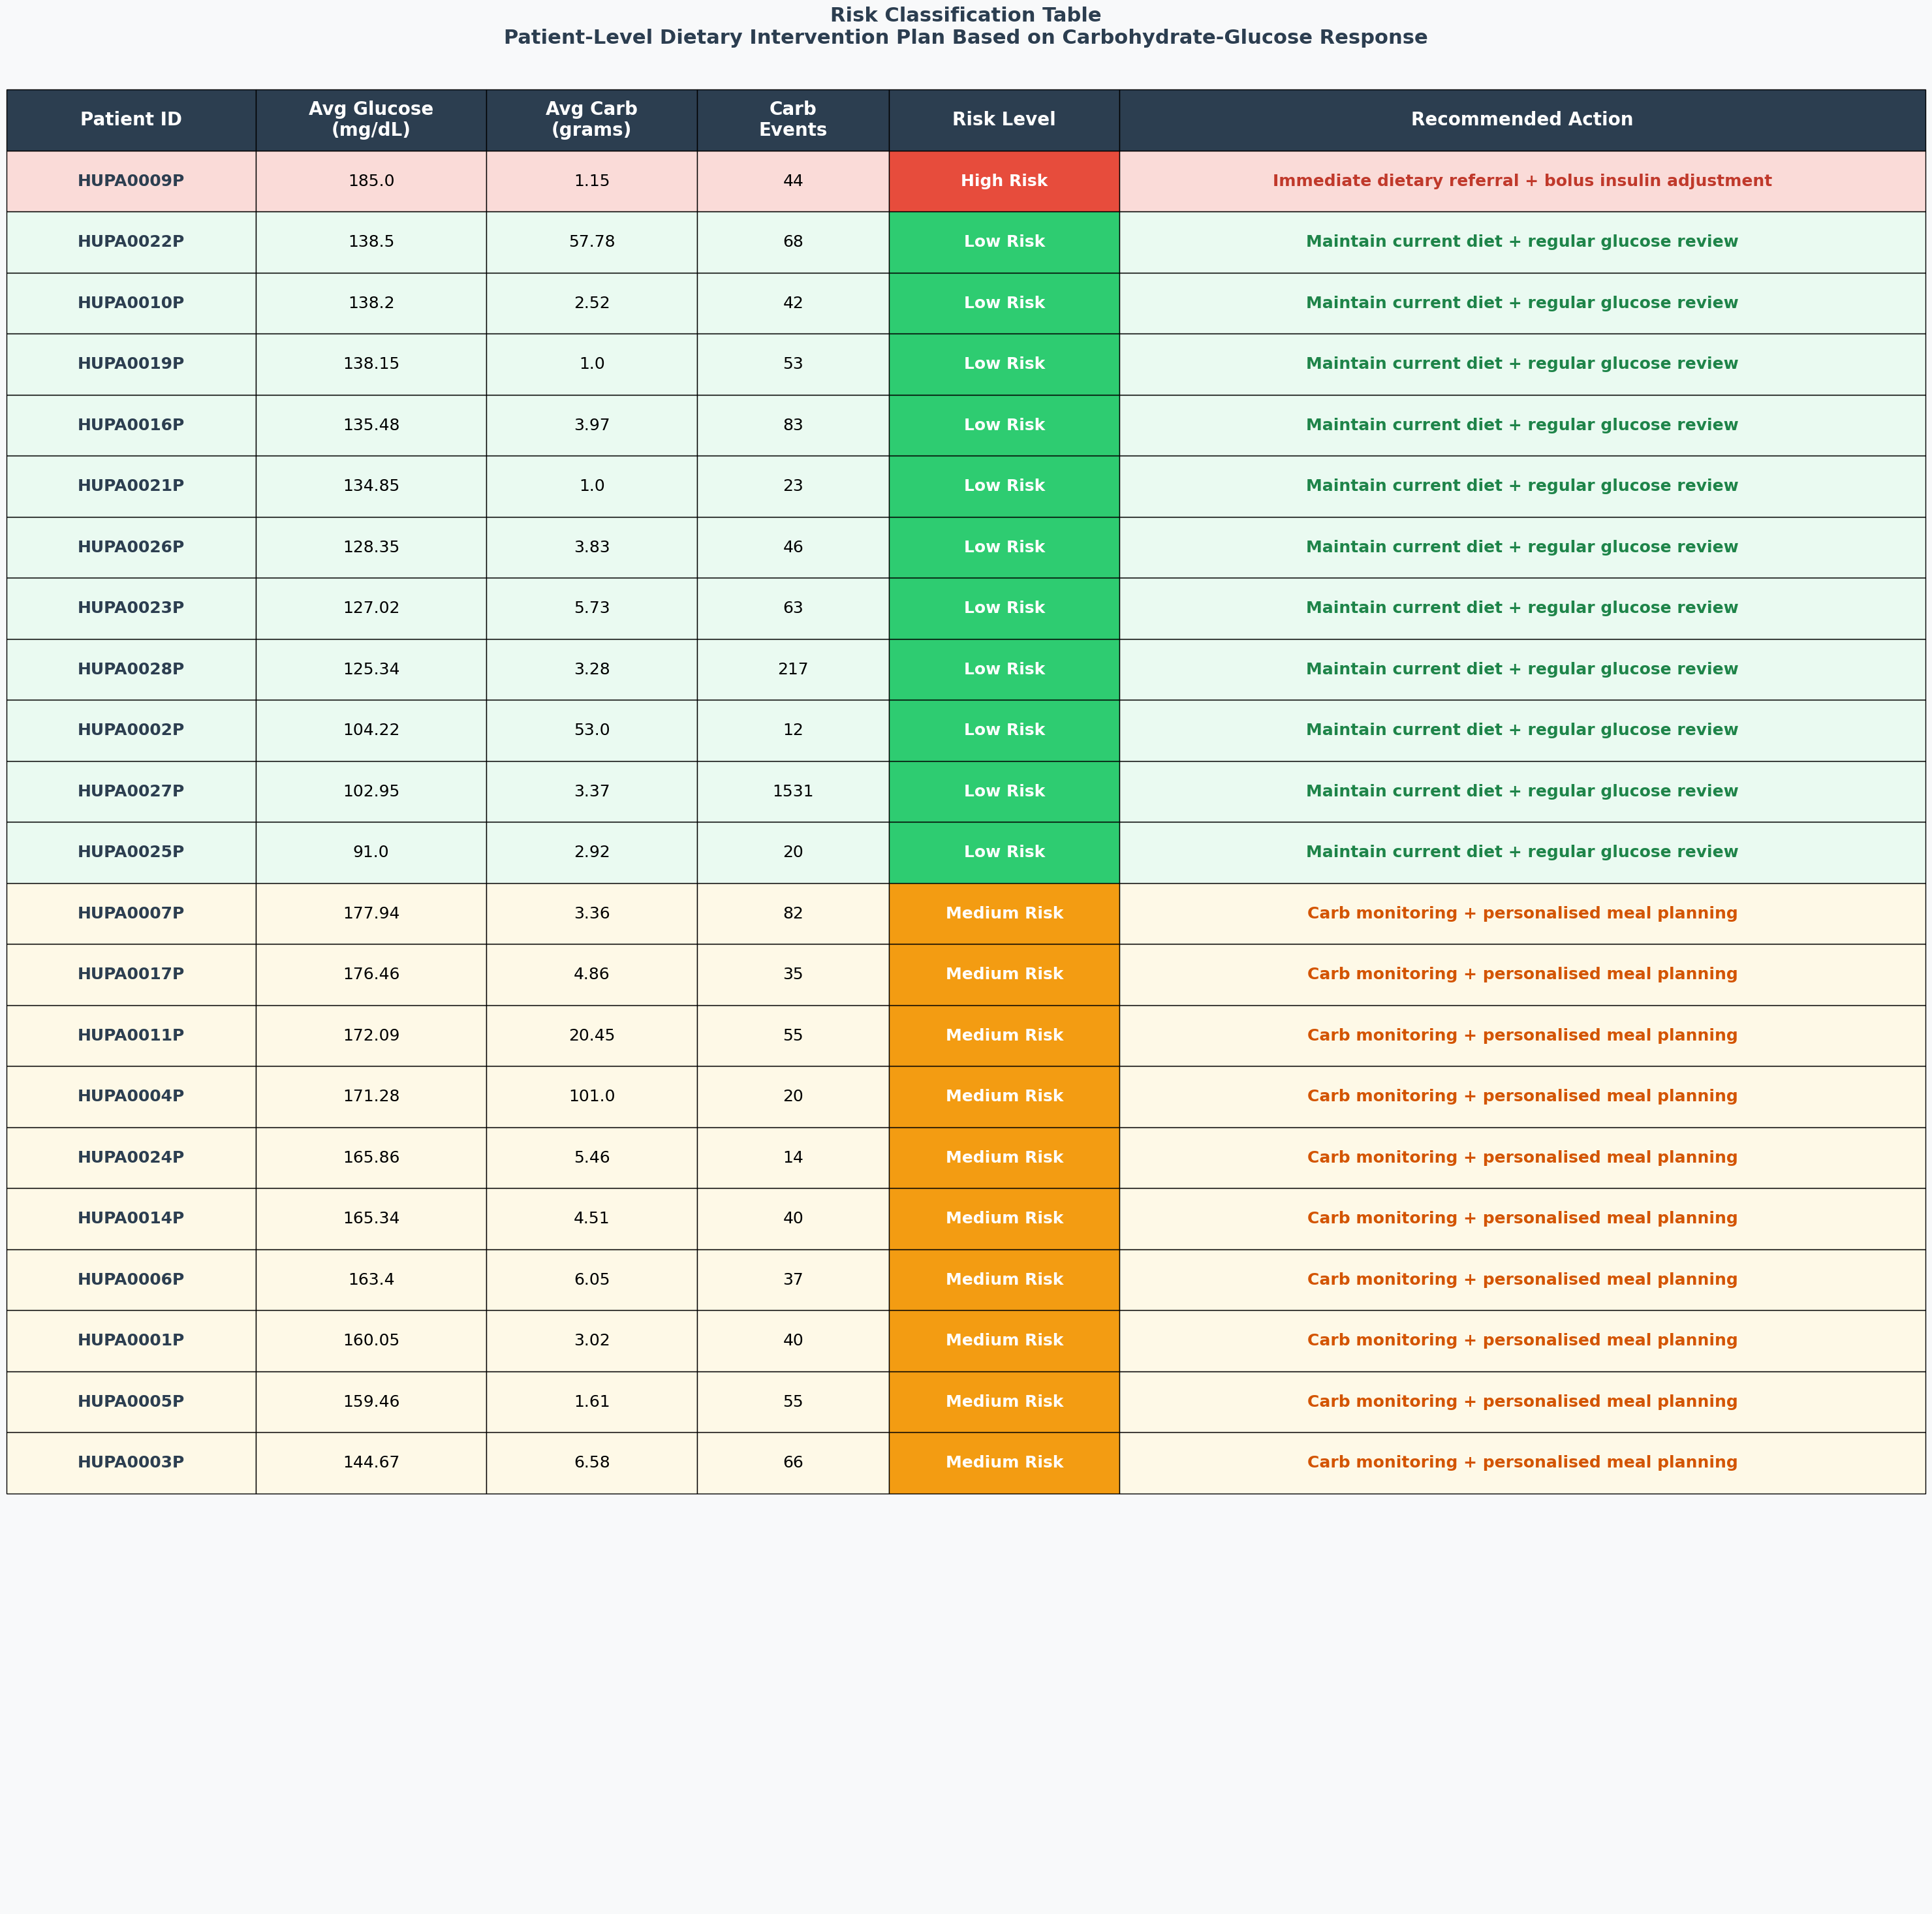

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

carb_df = df[df['Carb_Input'] > 0].copy()

patient_stats = carb_df.groupby('Patient_Id').agg(
    avg_glucose = ('Glucose',    'mean'),
    avg_carb    = ('Carb_Input', 'mean'),
    carb_events = ('Carb_Input', 'count')
).reset_index()

def classify_risk(glucose):
    if glucose > 180:   return 'High Risk'
    elif glucose > 140: return 'Medium Risk'
    else:               return 'Low Risk'

patient_stats['Risk']        = patient_stats['avg_glucose'].apply(classify_risk)
patient_stats['avg_glucose'] = patient_stats['avg_glucose'].round(2)
patient_stats['avg_carb']    = patient_stats['avg_carb'].round(2)
patient_stats = patient_stats.sort_values(['Risk','avg_glucose'],
                                           ascending=[True,False]).reset_index(drop=True)

def get_action(risk):
    if risk == 'High Risk':
        return 'Immediate dietary referral + bolus insulin adjustment'
    elif risk == 'Medium Risk':
        return 'Carb monitoring + personalised meal planning'
    else:
        return 'Maintain current diet + regular glucose review'

patient_stats['Recommended Action'] = patient_stats['Risk'].apply(get_action)

table_vals = patient_stats[['Patient_Id','avg_glucose',
                              'avg_carb','carb_events',
                              'Risk','Recommended Action']].values.tolist()

col_labels = ['Patient ID', 'Avg Glucose\n(mg/dL)',
              'Avg Carb\n(grams)', 'Carb\nEvents',
              'Risk Level', 'Recommended Action']

n_rows  = len(table_vals)
fig_h   = 1.0 + n_rows * 1.3        # ✅ increased height per row
fig, ax = plt.subplots(figsize=(30, fig_h))
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

t = ax.table(
    cellText  = table_vals,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'upper center',
    colWidths = [0.13, 0.12, 0.11, 0.10, 0.12, 0.42]
)

t.auto_set_font_size(False)
t.set_fontsize(18)                   # ✅ bigger font
t.scale(1, 4.5)                      # ✅ bigger row height

# ── Header ──
for col in range(6):
    t[0, col].set_facecolor('#2c3e50')
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=20)  # ✅

# ── Row colors ──
risk_row_colors = {
    'High Risk'   : ['#fadbd8','#fadbd8','#fadbd8','#fadbd8','#e74c3c','#fadbd8'],
    'Medium Risk' : ['#fef9e7','#fef9e7','#fef9e7','#fef9e7','#f39c12','#fef9e7'],
    'Low Risk'    : ['#eafaf1','#eafaf1','#eafaf1','#eafaf1','#2ecc71','#eafaf1'],
}

for row_i, row in enumerate(table_vals):
    risk   = row[4]
    colors = risk_row_colors[risk]
    for col_j in range(6):
        t[row_i + 1, col_j].set_facecolor(colors[col_j])
        t[row_i + 1, col_j].set_text_props(fontsize=18)         # ✅

    t[row_i + 1, 0].set_text_props(fontweight='bold', fontsize=18, color='#2c3e50')  # ✅
    t[row_i + 1, 4].set_text_props(color='white', fontweight='bold', fontsize=18)    # ✅

    if risk == 'High Risk':
        t[row_i + 1, 5].set_text_props(color='#c0392b', fontweight='bold', fontsize=18)  # ✅
    elif risk == 'Medium Risk':
        t[row_i + 1, 5].set_text_props(color='#d35400', fontweight='bold', fontsize=18)  # ✅
    else:
        t[row_i + 1, 5].set_text_props(color='#1e8449', fontweight='bold', fontsize=18)  # ✅

ax.set_title(
    'Risk Classification Table\n'
    'Patient-Level Dietary Intervention Plan Based on Carbohydrate-Glucose Response',
    fontsize=22, fontweight='bold', color='#2c3e50',
    pad=10, loc='center'
)

plt.subplots_adjust(top=0.97, bottom=0.01, left=0.01, right=0.99)
plt.savefig('risk_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


#### Prescriptive Insight:
#### The sunburst chart shows 1 High‑Risk, 10 Medium‑Risk, and 11 Low‑Risk patients. Most patients fall in the Medium group, meaning many T1DM patients need structured dietary guidance, while the High‑Risk patient needs immediate attention.
#### The table identifies HUPA0009P as the only High‑Risk patient with very high glucose levels, needing urgent insulin review. Medium‑Risk patients need carb‑counting support, while Low‑Risk patients show good control and can be used as clinical benchmarks.
#### How the Condition Can Be Improved?
#### High‑Risk patients need dietary referral + bolus insulin adjustment. Medium‑Risk patients benefit from meal planning and pre‑meal insulin correction, while Low‑Risk patients should continue their routine with periodic monitoring.Overall Carbohydrate intake is a highly controllable trigger for glucose spikes, making it the most useful biomarker for dietary intervention. A personalized approach based on each patient’s carb‑glucose risk level is far more effective than one general guideline. Early support for Medium‑Risk patients helps prevent them from becoming High‑Risk.


##  9.Is there a relationship between age and sleep duration or sleep disturbance in T1DM patients? (Diagnostics)


#### Why this biomarker was chosen:  Age is a key biomarker because sleep architecture naturally declines with aging, and older adults often experience shorter, more fragmented sleep. Since your dataset includes Age, Sleep Duration, and Sleep Quality, it allows a direct analysis of how aging affects sleep patterns in T1DM patients.
#### How it influences the medical condition:  Poor or reduced sleep in older T1DM patients can worsen glucose regulation by increasing cortisol levels, reducing insulin sensitivity, and elevating overnight glucose variability. This makes age‑related sleep decline an important factor influencing overall diabetes control.

## Age vs Sleep Metrics - Does Aging Worsen Sleep in T1DM Patients?



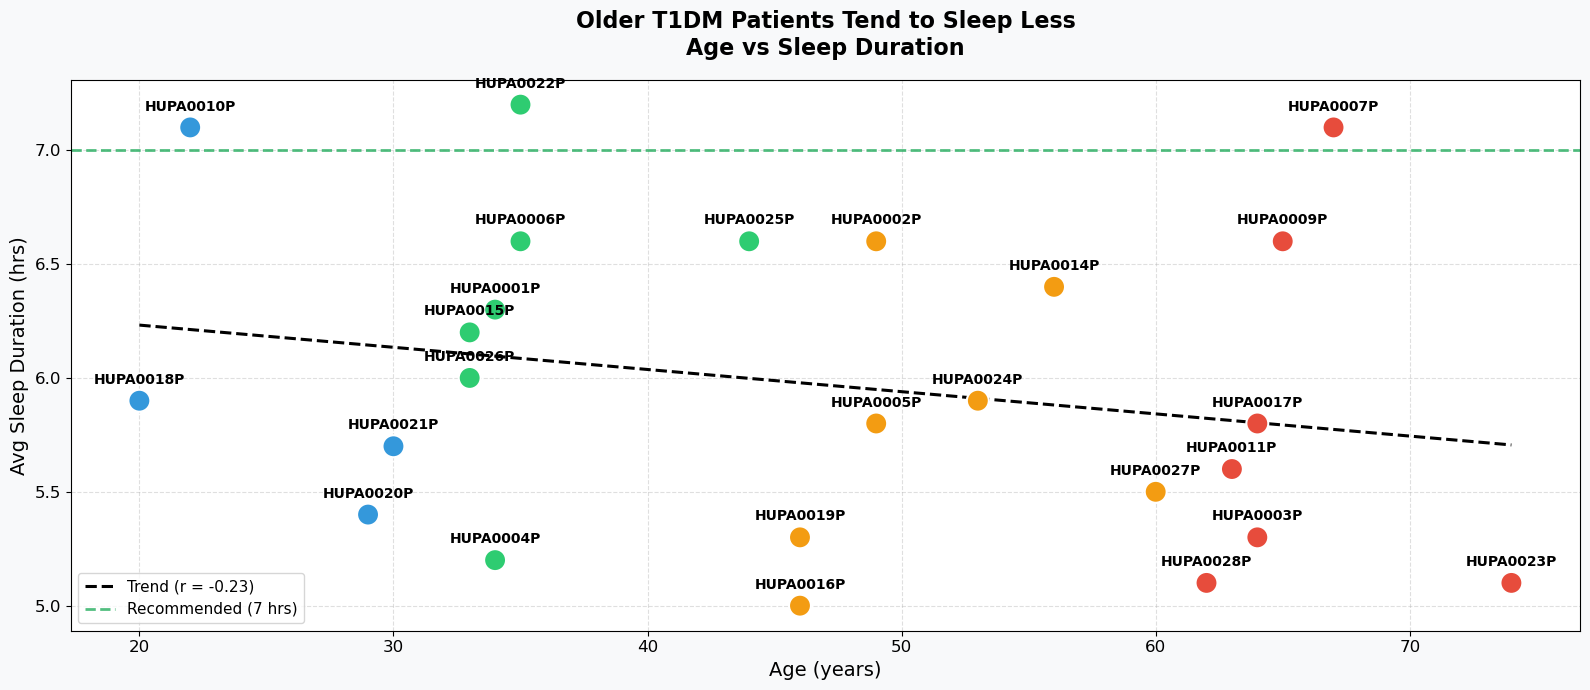

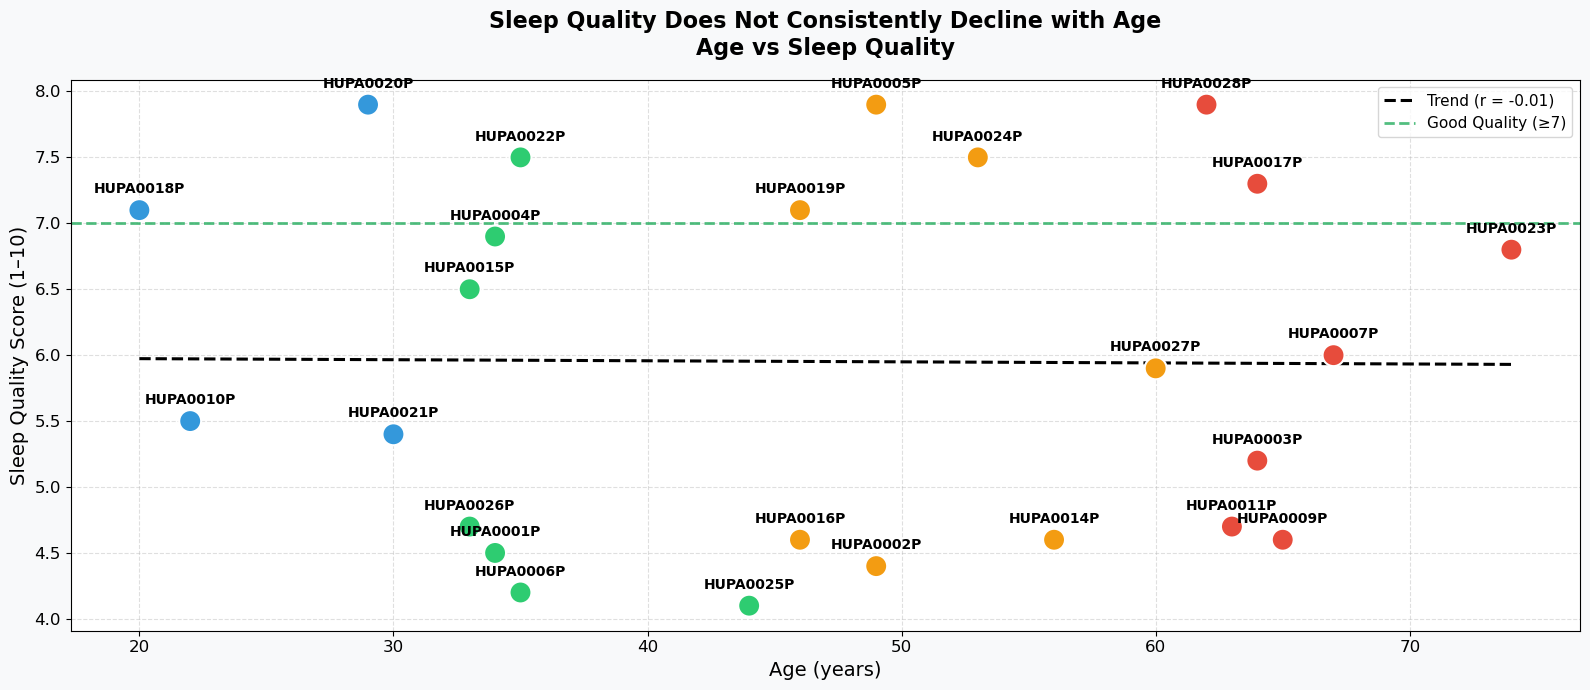

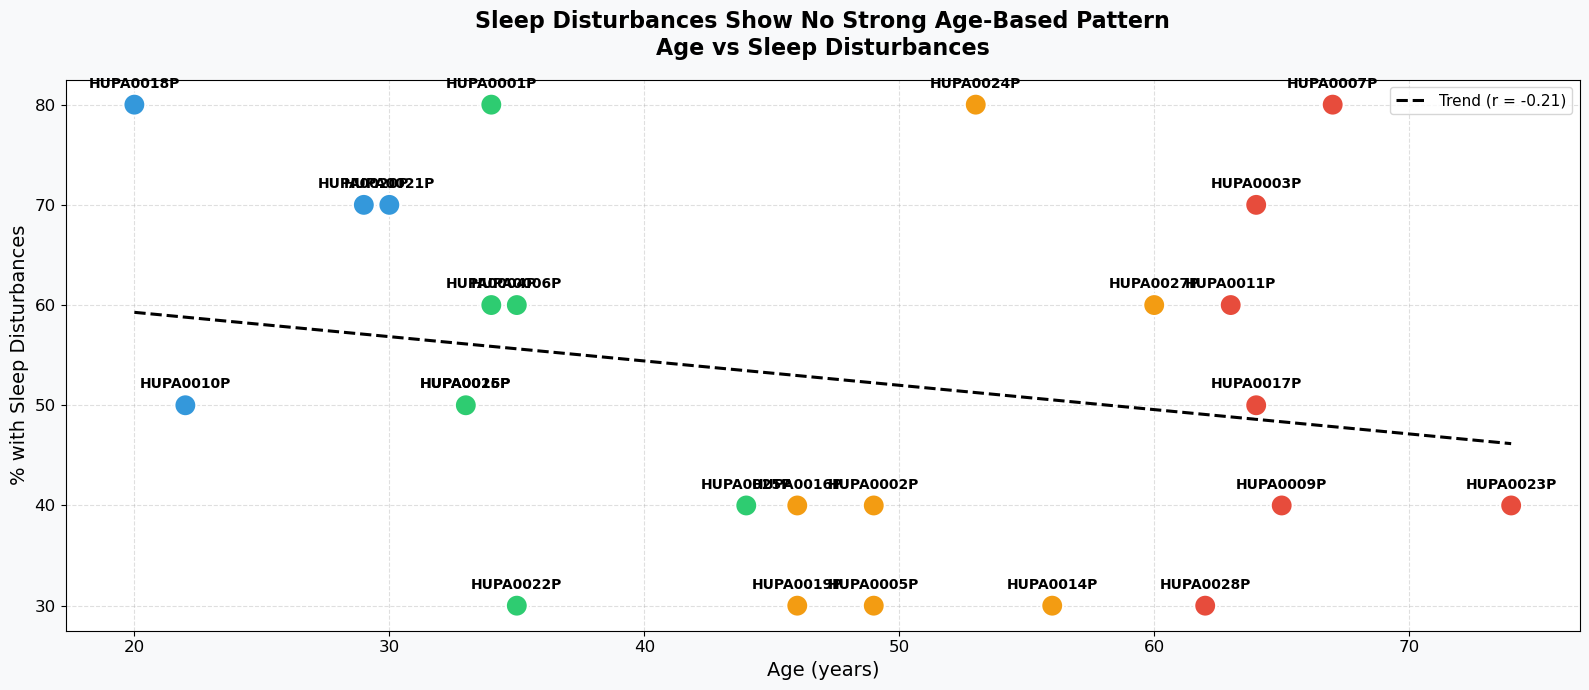

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

patient_df = df.drop_duplicates(subset='Patient_Id')[[
    'Patient_Id', 'Age',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    '% with Sleep Disturbances'
]].reset_index(drop=True)

patient_df['Age_Group'] = pd.cut(
    patient_df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)']
)

corr_duration = patient_df['Age'].corr(patient_df['Average Sleep Duration (hrs)'])
corr_quality  = patient_df['Age'].corr(patient_df['Sleep Quality (1-10)'])
corr_disturb  = patient_df['Age'].corr(patient_df['% with Sleep Disturbances'])

colors_group = {
    'Young (≤30)'    : '#3498db',
    'Middle (31–45)' : '#2ecc71',
    'Senior (46–60)' : '#f39c12',
    'Elderly (61+)'  : '#e74c3c'
}
point_colors = [colors_group[str(g)] for g in patient_df['Age_Group']]
x_line       = np.linspace(patient_df['Age'].min(), patient_df['Age'].max(), 100)

# ── 3 separate figures — one per scatter chart ──
charts = [
    {
        'y_col'  : 'Average Sleep Duration (hrs)',
        'title'  : 'Older T1DM Patients Tend to Sleep Less\nAge vs Sleep Duration',
        'ylabel' : 'Avg Sleep Duration (hrs)',
        'hline'  : 7,
        'hlabel' : 'Recommended (7 hrs)',
        'corr'   : corr_duration,
        'color'  : '#3498db',
        'fname'  : 'Q8_scatter_duration.png'
    },
    {
        'y_col'  : 'Sleep Quality (1-10)',
        'title'  : 'Sleep Quality Does Not Consistently Decline with Age\nAge vs Sleep Quality',
        'ylabel' : 'Sleep Quality Score (1–10)',
        'hline'  : 7,
        'hlabel' : 'Good Quality (≥7)',
        'corr'   : corr_quality,
        'color'  : '#e74c3c',
        'fname'  : 'Q8_scatter_quality.png'
    },
    {
        'y_col'  : '% with Sleep Disturbances',
        'title'  : 'Sleep Disturbances Show No Strong Age-Based Pattern\nAge vs Sleep Disturbances',
        'ylabel' : '% with Sleep Disturbances',
        'hline'  : None,
        'hlabel' : None,
        'corr'   : corr_disturb,
        'color'  : '#9b59b6',
        'fname'  : 'Q8_scatter_disturbances.png'
    }
]

for chart in charts:
    fig, ax = plt.subplots(figsize=(16, 7))   # ✅ each chart gets full large figure
    fig.patch.set_facecolor('#f8f9fa')

    ax.scatter(patient_df['Age'], patient_df[chart['y_col']],
               c=point_colors, s=250,              # ✅ bigger dots
               edgecolors='white', linewidth=1.5, zorder=3)

    for _, row in patient_df.iterrows():
        ax.annotate(
            row['Patient_Id'],
            xy     = (row['Age'], row[chart['y_col']]),
            fontsize   = 10,                       # ✅ bigger label font
            fontweight = 'bold',
            ha='center', va='bottom',
            xytext=(0, 10), textcoords='offset points'
        )

    z = np.polyfit(patient_df['Age'], patient_df[chart['y_col']], 1)
    ax.plot(x_line, np.poly1d(z)(x_line), 'k--',
            linewidth=2.2, label=f'Trend (r = {chart["corr"]:.2f})')

    if chart['hline']:
        ax.axhline(chart['hline'], color='#27ae60', linestyle='--',
                   linewidth=2, alpha=0.8, label=chart['hlabel'])

    ax.set_title(chart['title'], fontsize=16, fontweight='bold', pad=18)
    ax.set_xlabel('Age (years)',      fontsize=14)   # ✅ bigger axis labels
    ax.set_ylabel(chart['ylabel'],    fontsize=14)
    ax.tick_params(axis='both', labelsize=12)         # ✅ bigger tick labels
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(chart['fname'], dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()
   

## Summary Does Age determines Shorter Sleep Duration or Poorer Sleep Quality

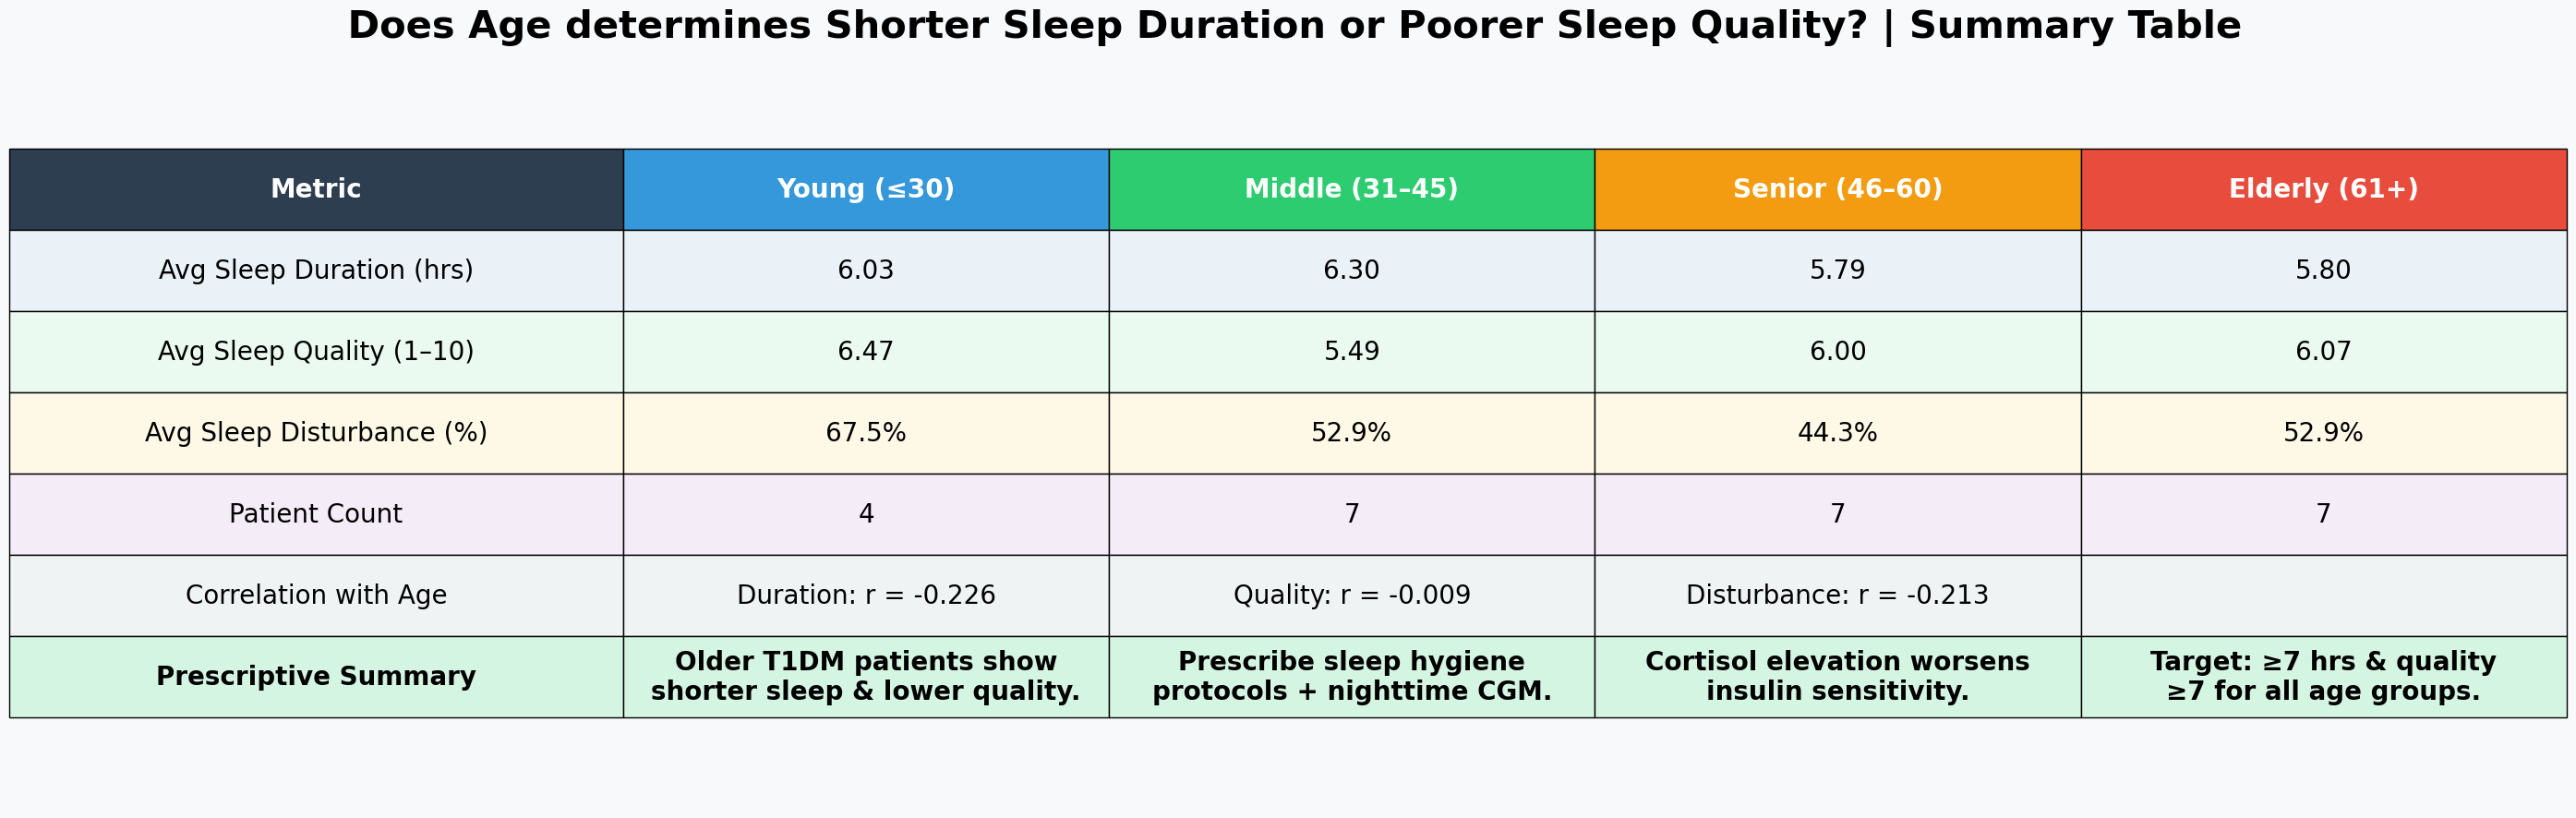

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

patient_df = df.drop_duplicates(subset='Patient_Id')[[
    'Patient_Id', 'Age',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    '% with Sleep Disturbances'
]].reset_index(drop=True)

patient_df['Age_Group'] = pd.cut(
    patient_df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)']
)

age_group_summary = patient_df.groupby('Age_Group', observed=True).agg(
    Avg_Sleep_Duration    = ('Average Sleep Duration (hrs)', 'mean'),
    Avg_Sleep_Quality     = ('Sleep Quality (1-10)',         'mean'),
    Avg_Sleep_Disturbance = ('% with Sleep Disturbances',   'mean'),
    Patient_Count         = ('Patient_Id',                  'count')
).reset_index()

corr_duration = patient_df['Age'].corr(patient_df['Average Sleep Duration (hrs)'])
corr_quality  = patient_df['Age'].corr(patient_df['Sleep Quality (1-10)'])
corr_disturb  = patient_df['Age'].corr(patient_df['% with Sleep Disturbances'])

fig, ax = plt.subplots(figsize=(28, 9))       # ✅ taller figure
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

table_vals = [
    ['Avg Sleep Duration (hrs)',
     f"{age_group_summary.loc[0,'Avg_Sleep_Duration']:.2f}",
     f"{age_group_summary.loc[1,'Avg_Sleep_Duration']:.2f}",
     f"{age_group_summary.loc[2,'Avg_Sleep_Duration']:.2f}",
     f"{age_group_summary.loc[3,'Avg_Sleep_Duration']:.2f}"],
    ['Avg Sleep Quality (1–10)',
     f"{age_group_summary.loc[0,'Avg_Sleep_Quality']:.2f}",
     f"{age_group_summary.loc[1,'Avg_Sleep_Quality']:.2f}",
     f"{age_group_summary.loc[2,'Avg_Sleep_Quality']:.2f}",
     f"{age_group_summary.loc[3,'Avg_Sleep_Quality']:.2f}"],
    ['Avg Sleep Disturbance (%)',
     f"{age_group_summary.loc[0,'Avg_Sleep_Disturbance']:.1f}%",
     f"{age_group_summary.loc[1,'Avg_Sleep_Disturbance']:.1f}%",
     f"{age_group_summary.loc[2,'Avg_Sleep_Disturbance']:.1f}%",
     f"{age_group_summary.loc[3,'Avg_Sleep_Disturbance']:.1f}%"],
    ['Patient Count',
     str(int(age_group_summary.loc[0,'Patient_Count'])),
     str(int(age_group_summary.loc[1,'Patient_Count'])),
     str(int(age_group_summary.loc[2,'Patient_Count'])),
     str(int(age_group_summary.loc[3,'Patient_Count']))],
    ['Correlation with Age',
     f'Duration: r = {corr_duration:.3f}',
     f'Quality: r = {corr_quality:.3f}',
     f'Disturbance: r = {corr_disturb:.3f}', ''],
    ['Prescriptive Summary',
     'Older T1DM patients show\nshorter sleep & lower quality.',
     'Prescribe sleep hygiene\nprotocols + nighttime CGM.',
     'Cortisol elevation worsens\ninsulin sensitivity.',
     'Target: ≥7 hrs & quality\n≥7 for all age groups.']
]

t = ax.table(
    cellText  = table_vals,
    colLabels = ['Metric', 'Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)'],
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.24, 0.19, 0.19, 0.19, 0.19]
)
t.auto_set_font_size(False)
t.set_fontsize(20)                             # ✅ bigger font
t.scale(1, 4.5)                               # ✅ taller rows

# ── Header styling ──
header_colors = ['#2c3e50','#3498db','#2ecc71','#f39c12','#e74c3c']
for col, color in enumerate(header_colors):
    t[0, col].set_facecolor(color)
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=20)  # ✅ bigger header

# ── Row styling ──
row_bg = ['#eaf2f8','#eafaf1','#fef9e7','#f4ecf7','#f0f3f4','#d5f5e3']
for row_i in range(1, len(table_vals) + 1):
    for col_j in range(5):
        t[row_i, col_j].set_facecolor(row_bg[row_i - 1])

# ── Prescriptive row — green bold ──
for col_j in range(5):
    t[6, col_j].set_text_props(color='black', fontweight='bold', fontsize=20)

fig.suptitle(
    ' Does Age determines Shorter Sleep Duration or Poorer Sleep Quality? | Summary Table',
    fontsize=30, fontweight='bold', color='black'
)
plt.tight_layout()
plt.savefig('summary_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


#### Diagnostic Insight:
#### Sleep Duration Declines With Age : Older T1DM patients sleep a bit less (r = -0.23). Those 61+ average only 5.8 hrs, and no age group reaches the recommended 7 hrs.
#### Sleep Quality Doesn’t Change Much With Age : Sleep quality shows almost no link to age (r = -0.01). Other factors like glucose swings or lifestyle matters more.
#### Sleep Disturbances Slightly Drop With Age : Disturbances decrease mildly as age increases (r = -0.21). Younger patients have more disruptions even though they sleep longer.
#### Large Differences Between Individuals : People of the same age sleep very differently. Example: one 67‑year‑old sleeps 7.1 hrs, another 74‑year‑old sleeps 5.1 hrs.Hence Age alone cannot predict sleep outcomes
#### Overall Age has only a small influence on sleep in T1DM, and most sleep outcomes remain highly modifiable through personalized care. Because sleep quality stays stable across age groups and disturbances improve slightly with age, the findings highlight opportunity rather than limitation. With tailored support, patients of any age can strengthen their sleep health, making age a minor factor and personal habits, glucose management, and lifestyle the major drivers of better sleep.
#### All age groups can achieve better sleep with small, targeted steps, and these improvements can be easily made using the prescriptive measures discussed in the next question.

## 10.Which age group requires priority clinical intervention for sleep-related glucose instability in T1DM ? (Prescriptive of Q9)

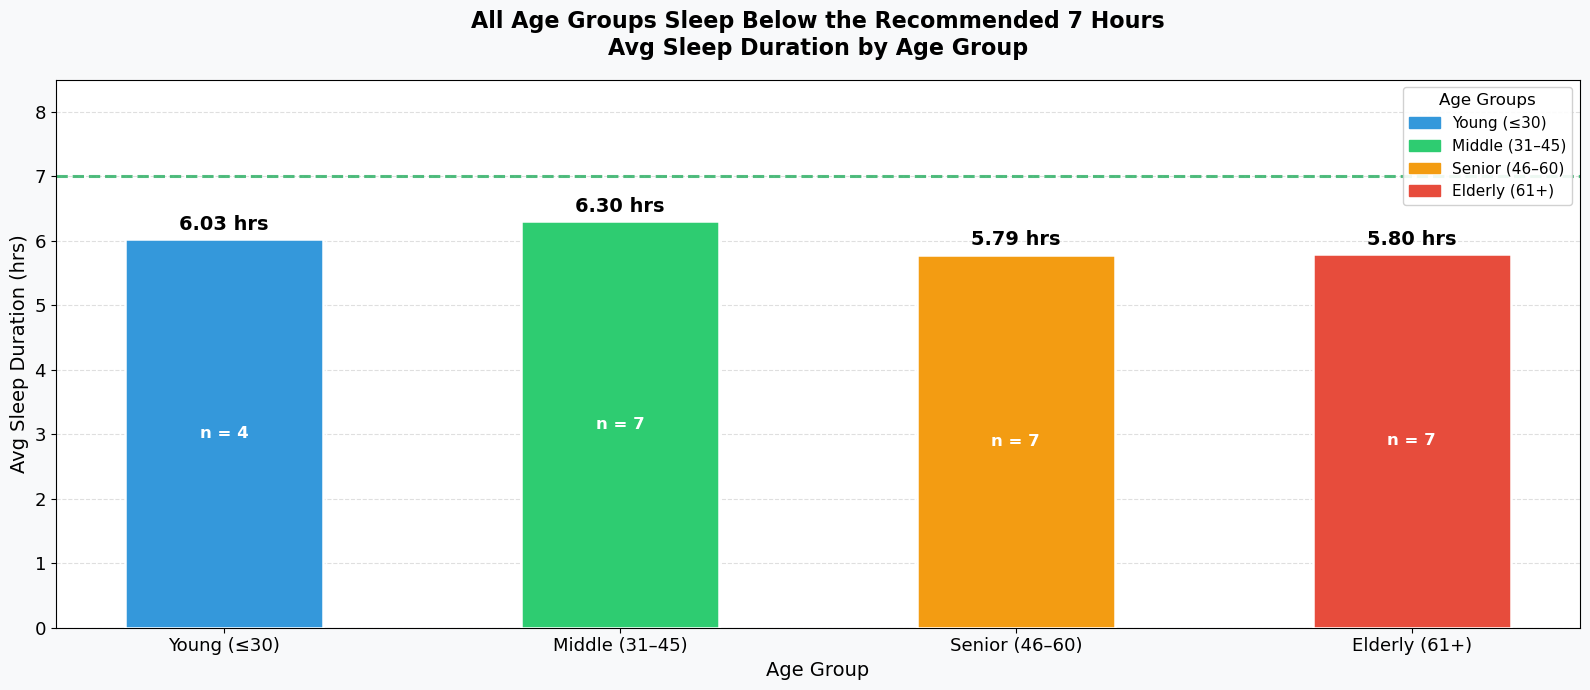

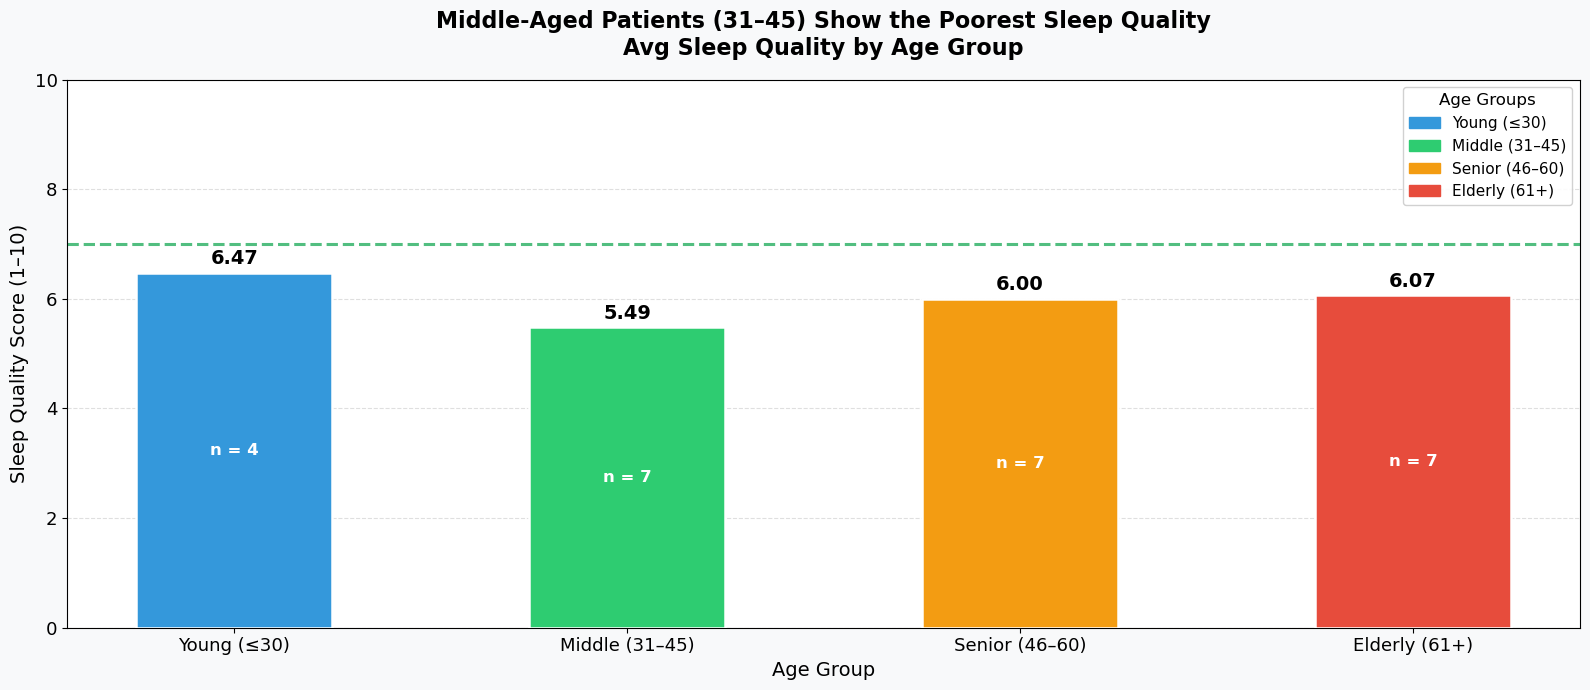

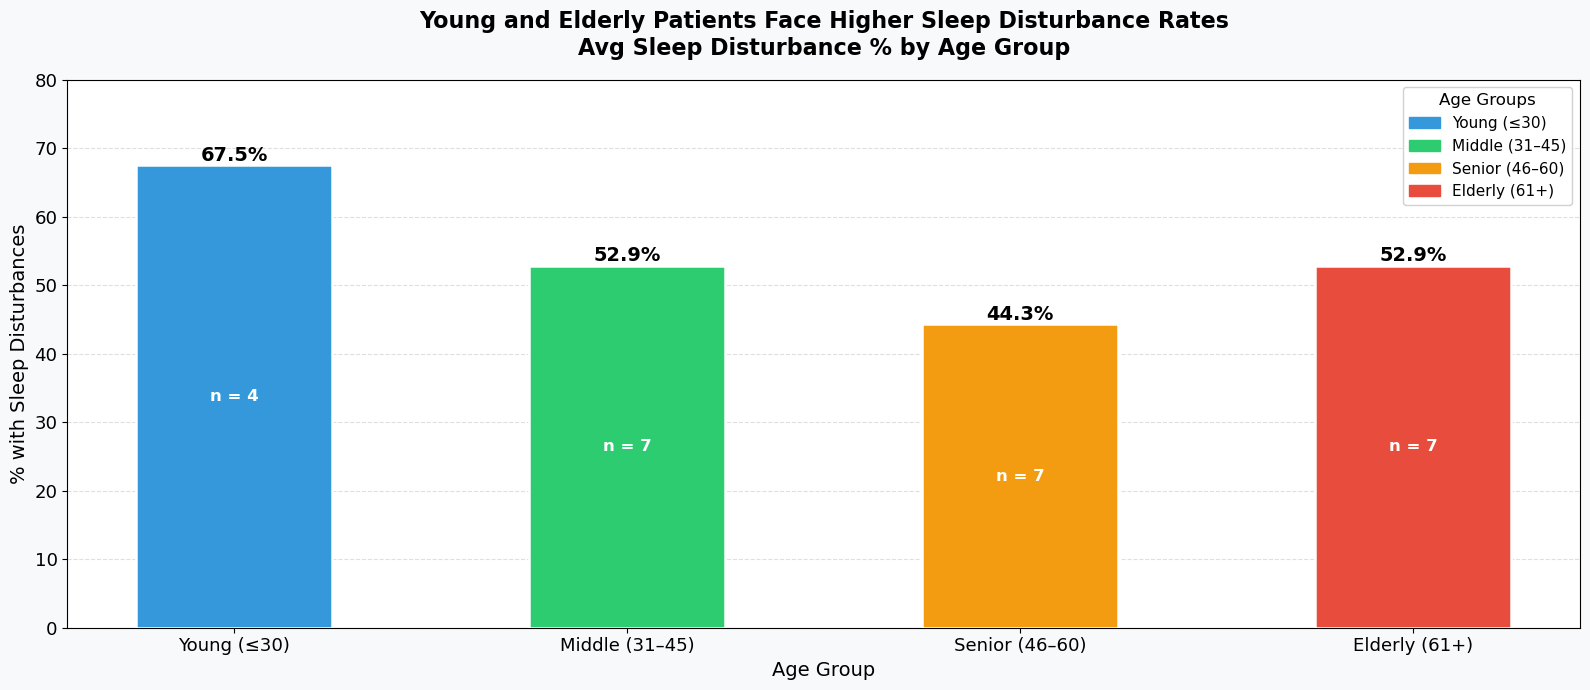

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

patient_df = df.drop_duplicates(subset='Patient_Id')[[
    'Patient_Id', 'Age',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    '% with Sleep Disturbances'
]].reset_index(drop=True)

patient_df['Age_Group'] = pd.cut(
    patient_df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)']
)

age_group_summary = patient_df.groupby('Age_Group', observed=True).agg(
    Avg_Sleep_Duration    = ('Average Sleep Duration (hrs)', 'mean'),
    Avg_Sleep_Quality     = ('Sleep Quality (1-10)',         'mean'),
    Avg_Sleep_Disturbance = ('% with Sleep Disturbances',   'mean'),
    Patient_Count         = ('Patient_Id',                  'count')
).reset_index()

colors_group = {
    'Young (≤30)'    : '#3498db',
    'Middle (31–45)' : '#2ecc71',
    'Senior (46–60)' : '#f39c12',
    'Elderly (61+)'  : '#e74c3c'
}
bar_colors = [colors_group[g] for g in age_group_summary['Age_Group'].astype(str)]
age_labels = age_group_summary['Age_Group'].astype(str)

# ── 3 separate figures — one per bar chart ──
charts = [
    {
        'y_col'  : 'Avg_Sleep_Duration',
        'title'  : 'All Age Groups Sleep Below the Recommended 7 Hours\nAvg Sleep Duration by Age Group',
        'ylabel' : 'Avg Sleep Duration (hrs)',
        'hline'  : 7,
        'hlabel' : 'Recommended (7 hrs)',
        'ylim'   : (0, 8.5),
        'fmt'    : '{:.2f} hrs',
        'fname'  : 'Q8_bar_duration.png'
    },
    {
        'y_col'  : 'Avg_Sleep_Quality',
        'title'  : 'Middle-Aged Patients (31–45) Show the Poorest Sleep Quality\nAvg Sleep Quality by Age Group',
        'ylabel' : 'Sleep Quality Score (1–10)',
        'hline'  : 7,
        'hlabel' : 'Good Quality (≥7)',
        'ylim'   : (0, 10),
        'fmt'    : '{:.2f}',
        'fname'  : 'Q8_bar_quality.png'
    },
    {
        'y_col'  : 'Avg_Sleep_Disturbance',
        'title'  : 'Young and Elderly Patients Face Higher Sleep Disturbance Rates\nAvg Sleep Disturbance % by Age Group',
        'ylabel' : '% with Sleep Disturbances',
        'hline'  : None,
        'hlabel' : None,
        'ylim'   : (0, 80),
        'fmt'    : '{:.1f}%',
        'fname'  : 'Q8_bar_disturbance.png'
    }
]

for chart in charts:
    fig, ax = plt.subplots(figsize=(16, 7))     # ✅ full large figure per chart
    fig.patch.set_facecolor('#f8f9fa')

    bars = ax.bar(
        age_labels,
        age_group_summary[chart['y_col']],
        color     = bar_colors,
        edgecolor = 'white',
        linewidth = 1.8,
        width     = 0.5,
        zorder    = 3
    )

    # ✅ Value labels on top of each bar
    for bar, val in zip(bars, age_group_summary[chart['y_col']]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            chart['fmt'].format(val),
            ha='center', va='bottom',
            fontsize=14, fontweight='bold'         # ✅ bigger value labels
        )

    # ✅ Patient count inside each bar
    for bar, count in zip(bars, age_group_summary['Patient_Count']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'n = {int(count)}',
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color='white'
        )

    if chart['hline']:
        ax.axhline(chart['hline'], color='#27ae60', linestyle='--',
                   linewidth=2.2, alpha=0.8, label=chart['hlabel'])
        ax.legend(fontsize=12)

    ax.set_title(chart['title'], fontsize=16, fontweight='bold', pad=18)
    ax.set_xlabel('Age Group',        fontsize=14)   # ✅ bigger axis labels
    ax.set_ylabel(chart['ylabel'],    fontsize=14)
    ax.tick_params(axis='both', labelsize=13)         # ✅ bigger tick labels
    ax.set_ylim(chart['ylim'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # ✅ Age group color legend
    legend_patches = [mpatches.Patch(color=c, label=g) for g, c in colors_group.items()]
    ax.legend(
        handles       = legend_patches,
        fontsize      = 11,
        title         = 'Age Groups',
        title_fontsize= 12,
        loc           = 'upper right',
        framealpha    = 0.9
    )

    plt.tight_layout()
    plt.savefig(chart['fname'], dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()
    

## Summary Overall Prescriptive Action Plan\nSleep-Related Glucose Instability in T1DM Patients

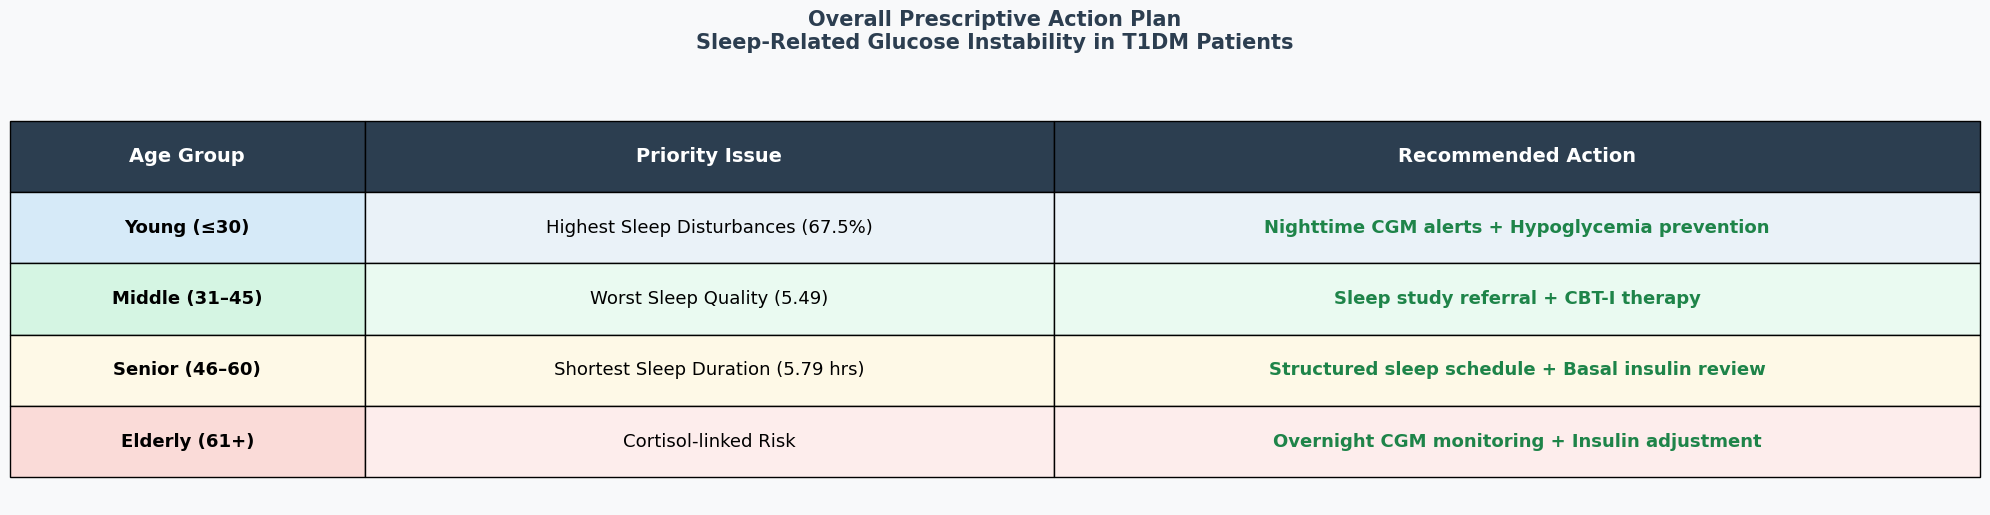

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 5))
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

table_vals = [
    ['Young (≤30)',    'Highest Sleep Disturbances (67.5%)',  'Nighttime CGM alerts + Hypoglycemia prevention'],
    ['Middle (31–45)', 'Worst Sleep Quality (5.49)',          'Sleep study referral + CBT-I therapy'],
    ['Senior (46–60)', 'Shortest Sleep Duration (5.79 hrs)',  'Structured sleep schedule + Basal insulin review'],
    ['Elderly (61+)',  'Cortisol-linked Risk',                'Overnight CGM monitoring + Insulin adjustment'],
]

col_labels = ['Age Group', 'Priority Issue', 'Recommended Action']

t = ax.table(
    cellText  = table_vals,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.18, 0.35, 0.47]
)

t.auto_set_font_size(False)
t.set_fontsize(13)
t.scale(1, 4.0)

# ── Header styling ──
header_colors = ['#2c3e50', '#2c3e50', '#2c3e50']
for col, color in enumerate(header_colors):
    t[0, col].set_facecolor(color)
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=14)

# ── Row styling — age group colors ──
row_colors = [
    ['#d6eaf8', '#eaf2f8', '#eaf2f8'],   # Young    — blue
    ['#d5f5e3', '#eafaf1', '#eafaf1'],   # Middle   — green
    ['#fef9e7', '#fef9e7', '#fef9e7'],   # Senior   — yellow
    ['#fadbd8', '#fdedec', '#fdedec'],   # Elderly  — red
]

for row_i, row_color in enumerate(row_colors):
    for col_j, color in enumerate(row_color):
        t[row_i + 1, col_j].set_facecolor(color)
        t[row_i + 1, col_j].set_text_props(fontsize=13)

# ── Age group column bold ──
for row_i in range(1, 5):
    t[row_i, 0].set_text_props(fontweight='bold', fontsize=13)

# ── Recommended Action column — green text ──
for row_i in range(1, 5):
    t[row_i, 2].set_text_props(color='#1e8449', fontweight='bold', fontsize=13)

fig.suptitle(
    'Overall Prescriptive Action Plan\nSleep-Related Glucose Instability in T1DM Patients',
    fontsize=15, fontweight='bold', color='#2c3e50', y=1.02
)

plt.tight_layout()
plt.savefig('prescriptive_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


#### Prescriptive Insight:
#### All Age Groups Need More Sleep : No age group reaches 7 hrs. Seniors (46–60) sleep the least (5.79 hrs).
#### Action: Structured sleep schedules for all T1DM patients.
#### Middle-Aged Adults Need Sleep Quality Treatment : They sleep the longest (6.30 hrs) but have the worst quality (5.49).
#### Action: Sleep study + CBT‑I referral.
#### Young Patients Need Disturbance Control : Highest disturbance rate (67.5%), likely due to nighttime glucose swings.
#### Action: Nighttime CGM alerts + hypoglycemia prevention.
#### Elderly Patients Need Overnight Glucose Monitoring : Short sleep (5.80 hrs) + cortisol‑related insulin resistance risk.
#### Action: Overnight CGM checks + basal insulin adjustmen


#### The prescriptive analysis shows that every age group can improve sleep with small, targeted steps. Younger patients benefit from better nighttime glucose control, middle‑aged adults can boost sleep quality with supportive therapies, seniors can strengthen sleep through routine, and elderly patients can maintain stable rest with gentle overnight monitoring. Overall, better sleep is achievable for all T1DM patients, and each group has a clear path to improvement.

## 11.What behaviors reduce post‑meal glucose spikes? (Prescriptive)

#### I chose this biomarker because post‑meal behaviors directly shape how quickly glucose rises after eating, making them one of the most controllable factors in T1DM
#### These behaviors influence digestion speed, insulin‑glucose matching, and overall glucose stability. By improving these habits, patients can significantly reduce post‑meal spikes and maintain smoother glucose levels throughout the day.

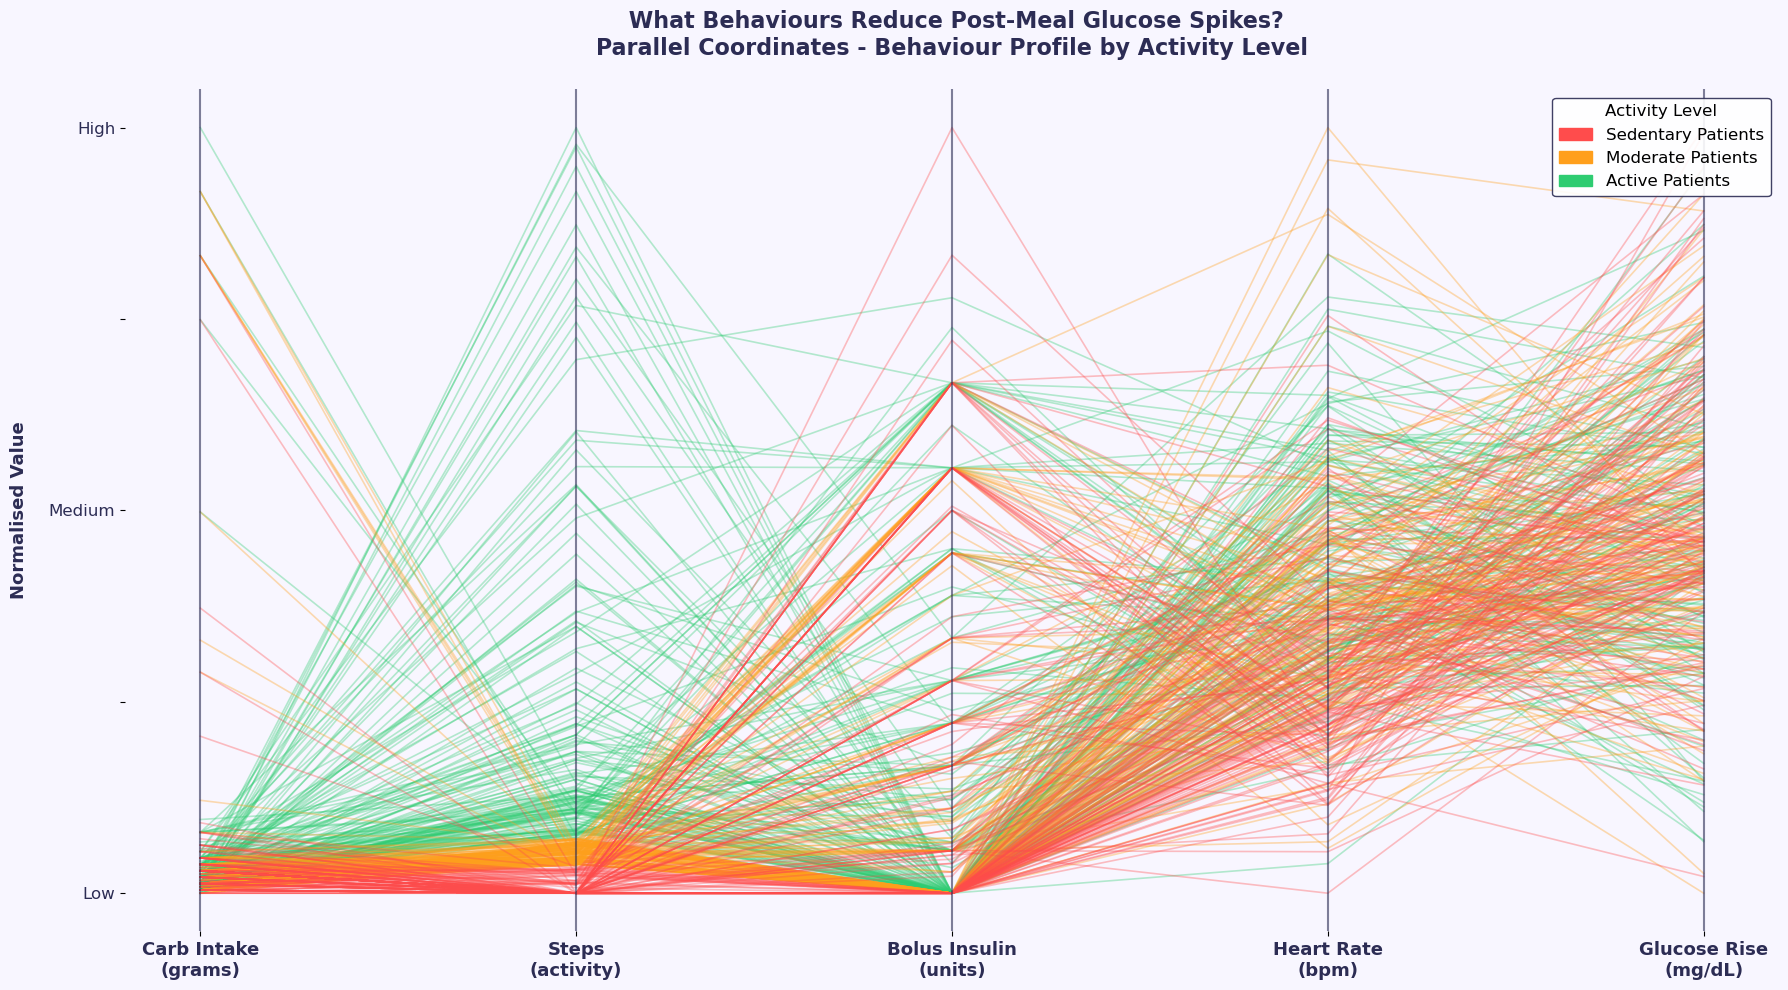

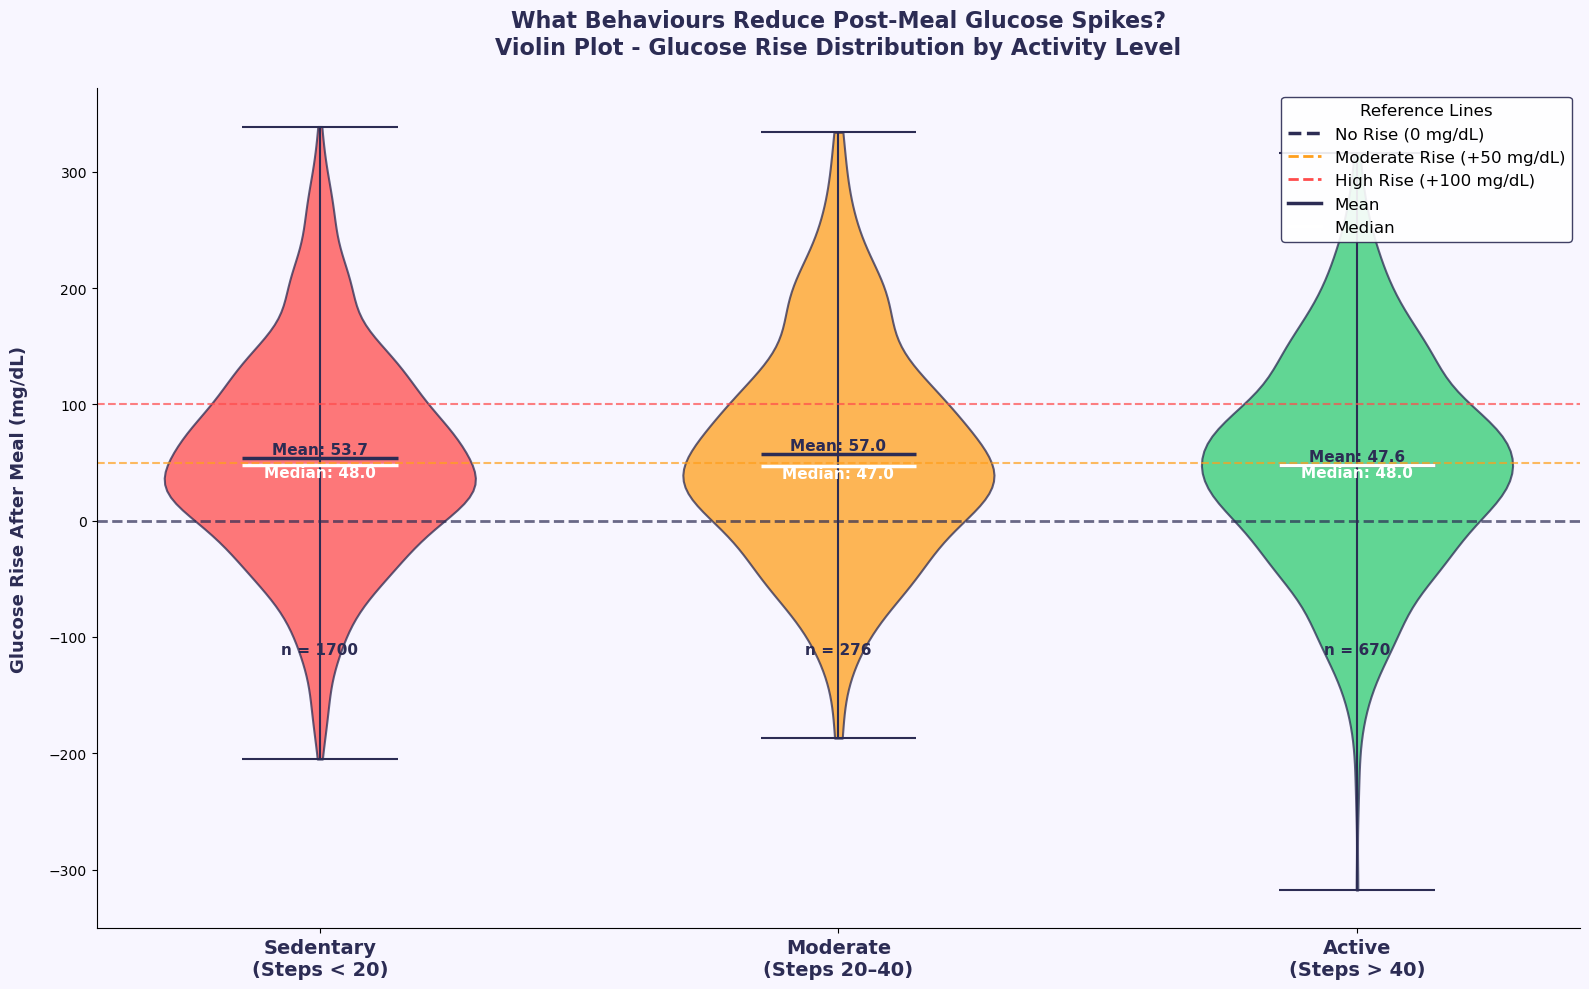

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

bg_color = '#F8F6FF'

# ── Extract Post-Meal Data ────────────────────────────────────────────────────
carb_events = df[df['Carb_Input'] > 0].copy().reset_index(drop=True)
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)
carb_events['Glucose_30min_Later'] = df.loc[carb_events.index, 'Glucose_30min_Later'].values
carb_events['Glucose_Rise'] = (
    carb_events['Glucose_30min_Later'] - carb_events['Glucose']
).round(2)
carb_events = carb_events.dropna(subset=['Glucose_Rise'])

def classify_activity(steps):
    if steps < 20:
        return 'Sedentary'
    elif steps < 40:
        return 'Moderate'
    else:
        return 'Active'

carb_events['Activity_Level'] = carb_events['Steps'].apply(classify_activity)

activity_colors = {
    'Sedentary' : '#FF4C4C',
    'Moderate'  : '#FF9F1C',
    'Active'    : '#2ECC71'
}

# ── Normalize for Parallel Coordinates ───────────────────────────────────────
pc_cols = ['Carb_Input', 'Steps', 'Bolus_Volume_Delivered', 'Heart_Rate', 'Glucose_Rise']
pc_data = carb_events[pc_cols + ['Activity_Level']].copy()

# ── Sample without groupby to avoid deprecation warning ──────────────────────
sampled_groups = []
for activity in pc_data['Activity_Level'].unique():
    group = pc_data[pc_data['Activity_Level'] == activity]
    sampled_groups.append(group.sample(min(150, len(group)), random_state=42))
pc_sample = pd.concat(sampled_groups).reset_index(drop=True)

for col in pc_cols:
    col_min = pc_sample[col].min()
    col_max = pc_sample[col].max()
    pc_sample[col] = (pc_sample[col] - col_min) / (col_max - col_min + 1e-9)

# ════════════════════════════════════════════════════════════════
# CHART 1 — PARALLEL COORDINATES PLOT
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(18, 10))
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

for _, row in pc_sample.iterrows():
    color = activity_colors[row['Activity_Level']]
    ax1.plot(
        range(len(pc_cols)),
        [row[col] for col in pc_cols],
        color=color, alpha=0.35, linewidth=1.2
    )

for i in range(len(pc_cols)):
    ax1.axvline(x=i, color='#2C2C54', linewidth=1.5, alpha=0.6)

ax1.set_xticks(range(len(pc_cols)))
ax1.set_xticklabels(
    ['Carb Intake\n(grams)', 'Steps\n(activity)', 'Bolus Insulin\n(units)',
     'Heart Rate\n(bpm)', 'Glucose Rise\n(mg/dL)'],
    fontsize=13, fontweight='bold', color='#2C2C54'
)
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax1.set_yticklabels(['Low', '', 'Medium', '', 'High'],
                     fontsize=12, color='#2C2C54')
ax1.set_ylabel('Normalised Value', fontsize=13,
               fontweight='bold', color='#2C2C54', labelpad=15)
ax1.set_title(
    ' What Behaviours Reduce Post-Meal Glucose Spikes?\nParallel Coordinates - Behaviour Profile by Activity Level',
    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

patches = [mpatches.Patch(color=activity_colors[a], label=f'{a} Patients')
           for a in ['Sedentary', 'Moderate', 'Active']]
ax1.legend(
    handles=patches, loc='upper right',
    bbox_to_anchor=(1.0, 1.0), fontsize=12,
    framealpha=0.9, edgecolor='#2C2C54',
    title='Activity Level', title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q10_Parallel_Coordinates.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()

# ════════════════════════════════════════════════════════════════
# CHART 2 — VIOLIN PLOT
# ════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(16, 10))
fig2.patch.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

activity_order = ['Sedentary', 'Moderate', 'Active']
violin_data    = [carb_events[carb_events['Activity_Level'] == a]['Glucose_Rise'].values
                  for a in activity_order]

vp = ax2.violinplot(
    violin_data, positions=[1, 2, 3],
    widths=0.6, showmeans=True,
    showmedians=True, showextrema=True
)

for body, activity in zip(vp['bodies'], activity_order):
    body.set_facecolor(activity_colors[activity])
    body.set_edgecolor('#2C2C54')
    body.set_alpha(0.75)
    body.set_linewidth(1.5)

vp['cmeans'].set_color('#2C2C54')
vp['cmeans'].set_linewidth(2.5)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2.5)
vp['cbars'].set_color('#2C2C54')
vp['cbars'].set_linewidth(1.5)
vp['cmins'].set_color('#2C2C54')
vp['cmins'].set_linewidth(1.5)
vp['cmaxes'].set_color('#2C2C54')
vp['cmaxes'].set_linewidth(1.5)

for i, activity in enumerate(activity_order):
    subset     = carb_events[carb_events['Activity_Level'] == activity]['Glucose_Rise']
    mean_val   = subset.mean()
    median_val = subset.median()
    count      = len(subset)

    ax2.text(i + 1, mean_val + 4, f'Mean: {mean_val:.1f}',
             ha='center', fontsize=11, fontweight='bold', color='#2C2C54')
    ax2.text(i + 1, median_val - 10, f'Median: {median_val:.1f}',
             ha='center', fontsize=11, fontweight='bold', color='white')
    ax2.text(i + 1, -115, f'n = {count}',
             ha='center', fontsize=11, fontweight='bold', color='#2C2C54')

ax2.axhline(y=0,   color='#2C2C54', linestyle='--', linewidth=2.0, alpha=0.7)
ax2.axhline(y=50,  color='#FF9F1C', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=100, color='#FF4C4C', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(
    ['Sedentary\n(Steps < 20)', 'Moderate\n(Steps 20–40)', 'Active\n(Steps > 40)'],
    fontsize=14, fontweight='bold', color='#2C2C54'
)
ax2.set_ylabel('Glucose Rise After Meal (mg/dL)',
               fontsize=13, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_title(
    'What Behaviours Reduce Post-Meal Glucose Spikes?\nViolin Plot - Glucose Rise Distribution by Activity Level',
    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)
ax2.spines[['top', 'right']].set_visible(False)

line_handles = [
    plt.Line2D([0],[0], color='#2C2C54', lw=2.5, linestyle='--', label='No Rise (0 mg/dL)'),
    plt.Line2D([0],[0], color='#FF9F1C', lw=2.0, linestyle='--', label='Moderate Rise (+50 mg/dL)'),
    plt.Line2D([0],[0], color='#FF4C4C', lw=2.0, linestyle='--', label='High Rise (+100 mg/dL)'),
    plt.Line2D([0],[0], color='#2C2C54', lw=2.5, label='Mean'),
    plt.Line2D([0],[0], color='white',   lw=2.5, label='Median'),
]
ax2.legend(
    handles=line_handles, loc='upper right',
    bbox_to_anchor=(1.0, 1.0), fontsize=12,
    framealpha=0.9, edgecolor='#2C2C54',
    title='Reference Lines', title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q10_Violin_Plot.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


## Summary Glucose Rise by Activity Level

In [46]:
import pandas as pd
from IPython.display import display, HTML

# ── Summary Stats Table ───────────────────────────────────────────────────────
activity_order = ['Sedentary', 'Moderate', 'Active']

rows = []
for activity in activity_order:
    subset = carb_events[carb_events['Activity_Level'] == activity]['Glucose_Rise']
    rows.append({
        'Activity Level' : activity,
        'Count'          : len(subset),
        'Mean (mg/dL)'   : f'{subset.mean():.2f}',
        'Median (mg/dL)' : f'{subset.median():.2f}',
        'Std Dev (mg/dL)': f'{subset.std():.2f}',
        'Min (mg/dL)'    : f'{subset.min():.2f}',
        'Max (mg/dL)'    : f'{subset.max():.2f}'
    })

summary_df = pd.DataFrame(rows)

html = (
    "<style>"
    ".summary-table { border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 13px; }"
    ".summary-table th { padding: 12px 16px; text-align: center; font-weight: bold; color: white; font-size: 14px; }"
    ".summary-table td { padding: 10px 16px; text-align: center; border: 1px solid #ddd; color: #2C2C54; font-size: 13px; }"
    ".summary-table tr:nth-child(even) td { background-color: #F8F6FF; }"
    ".summary-table tr:nth-child(odd) td { background-color: #ffffff; }"
    ".metric-col { text-align: left !important; font-weight: bold; background-color: #2C2C54 !important; color: white !important; }"
    "</style>"
    "<table class='summary-table'>"
    "<thead><tr>"
    "<th style='background-color:#2C2C54;'>Metric</th>"
    "<th style='background-color:#FF4C4C;'>Sedentary</th>"
    "<th style='background-color:#FF9F1C;'>Moderate</th>"
    "<th style='background-color:#2ECC71;'>Active</th>"
    "</tr></thead><tbody>"
)

metrics = ['Count', 'Mean (mg/dL)', 'Median (mg/dL)', 'Std Dev (mg/dL)', 'Min (mg/dL)', 'Max (mg/dL)']

for metric in metrics:
    html += f"<tr><td class='metric-col'>{metric}</td>"
    for activity in activity_order:
        val = summary_df[summary_df['Activity Level'] == activity].iloc[0][metric]
        html += f"<td>{val}</td>"
    html += "</tr>"

html += "</tbody></table>"

display(HTML(html))

Metric,Sedentary,Moderate,Active
Count,1700,276,670
Mean (mg/dL),53.73,56.99,47.63
Median (mg/dL),48.00,47.00,48.00
Std Dev (mg/dL),88.50,90.79,90.39
Min (mg/dL),-205.00,-187.00,-317.67
Max (mg/dL),339.00,334.00,316.00


#### Prescriptive Insight:
#### The Parallel Coordinates Chart shows that active patients consistently have lower post‑meal glucose rises, and correct bolus dosing further improves control.
#### The Violin Plot shows that active patients have more stable and predictable glucose responses, while sedentary patients show wider, more variable spikes.
#### Active patients manage meals more smoothly because movement helps the body absorb glucose naturally, and correct insulin dosing enhances this effect. Sedentary patients can quickly improve by adding light activity and adjusting meal portions. Overall, simple habits like walking after meals and fine‑tuning insulin can greatly reduce post‑meal glucose spikes for all T1DM patients.

## 12.What actions should be taken when activity is too low for long periods? (prescriptive)


#### I chose this biomarker because long periods of low activity strongly affect how efficiently the body uses glucose in T1DM. Low activity reduces muscle‑driven glucose uptake, causing glucose levels to stay higher for longer
#### It influemce the medical condition by identifying extended inactivity early, patients can take small movement‑based steps that greatly improve glucose stability and overall metabolic health.

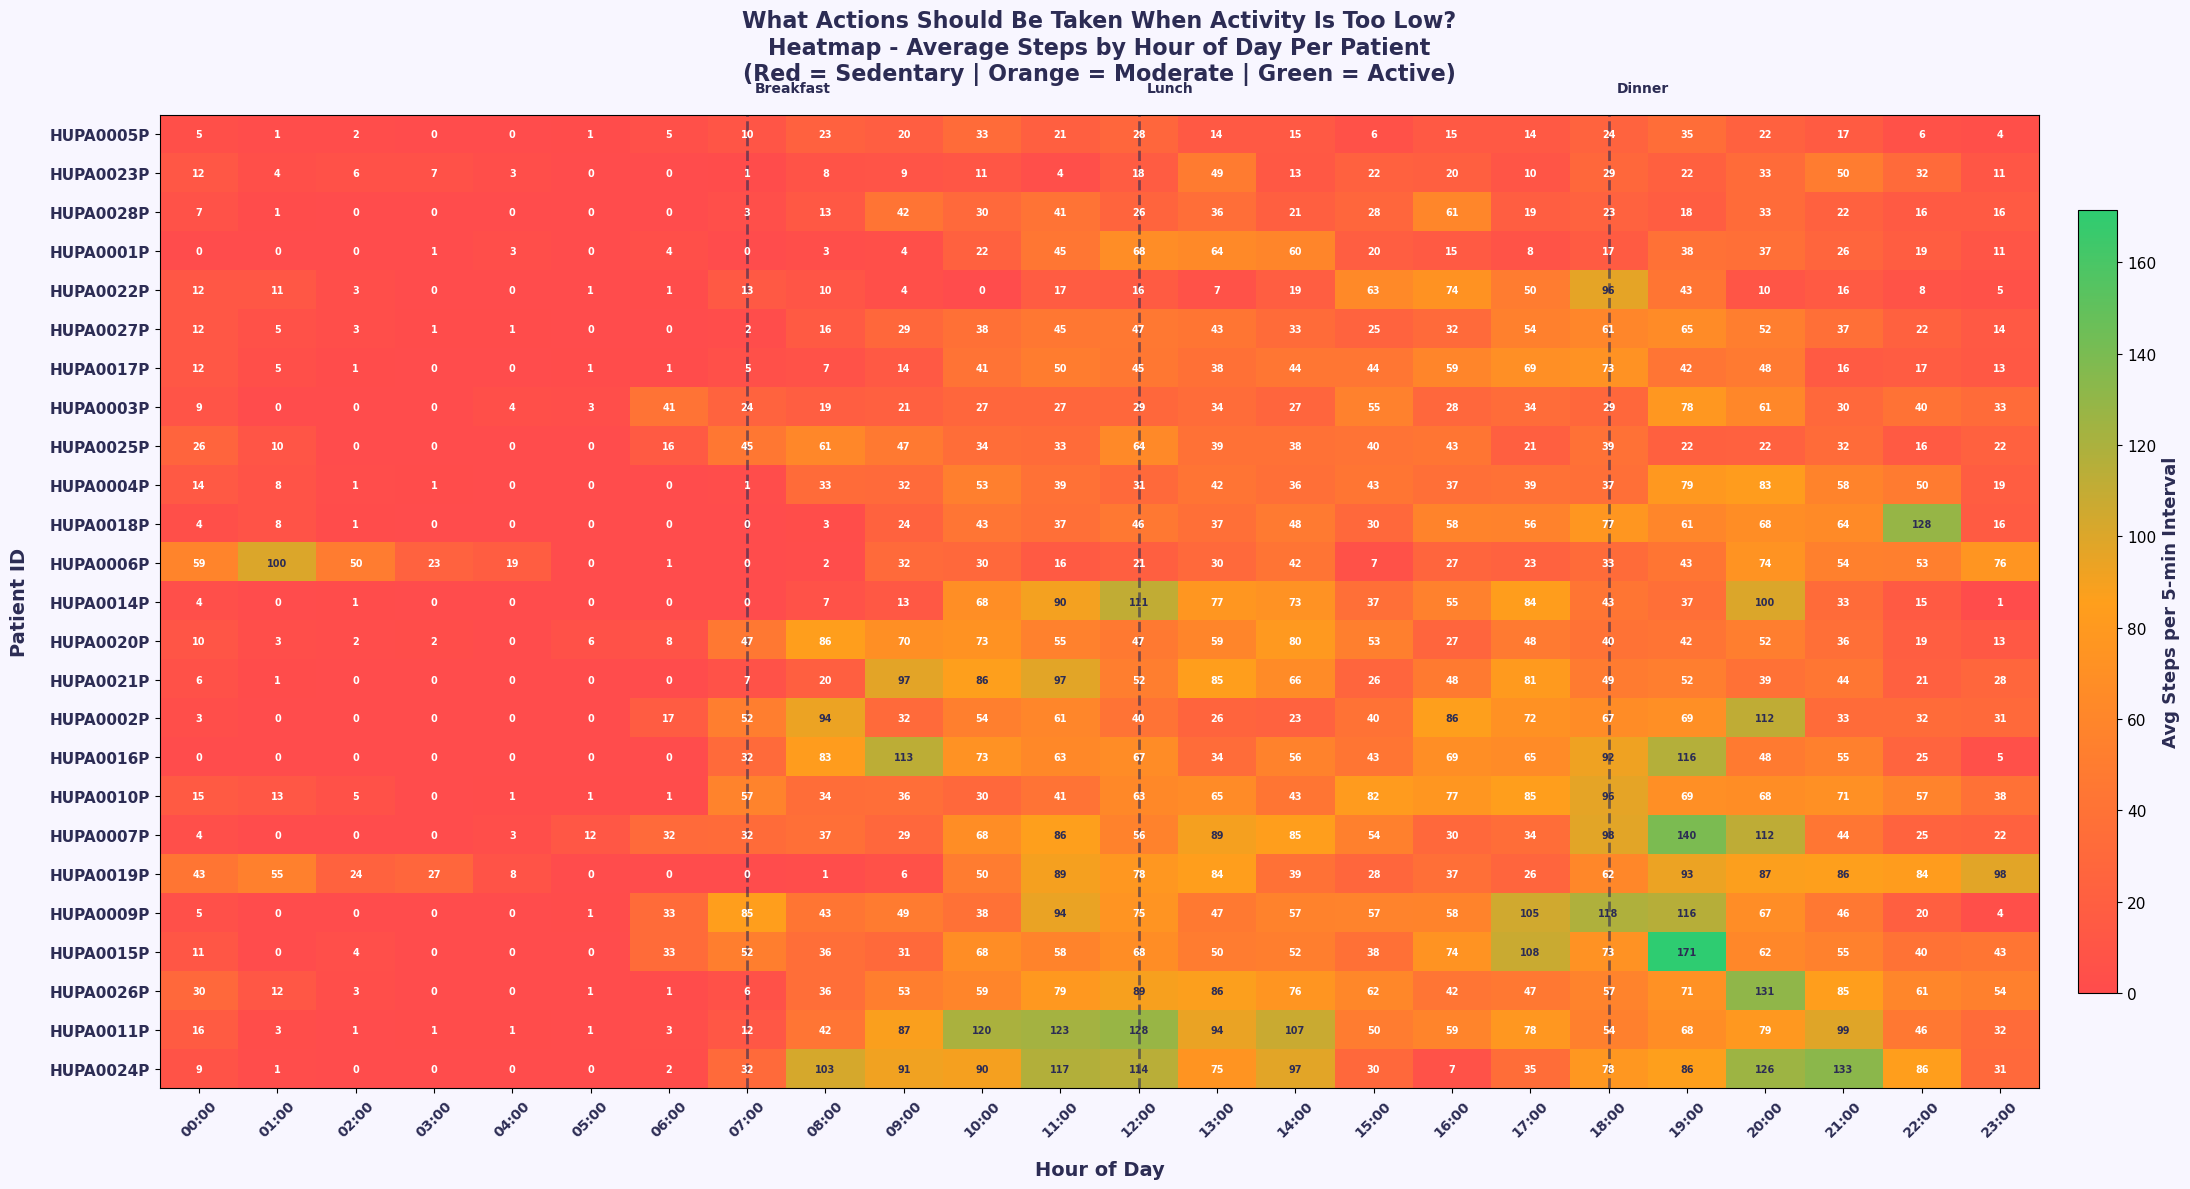

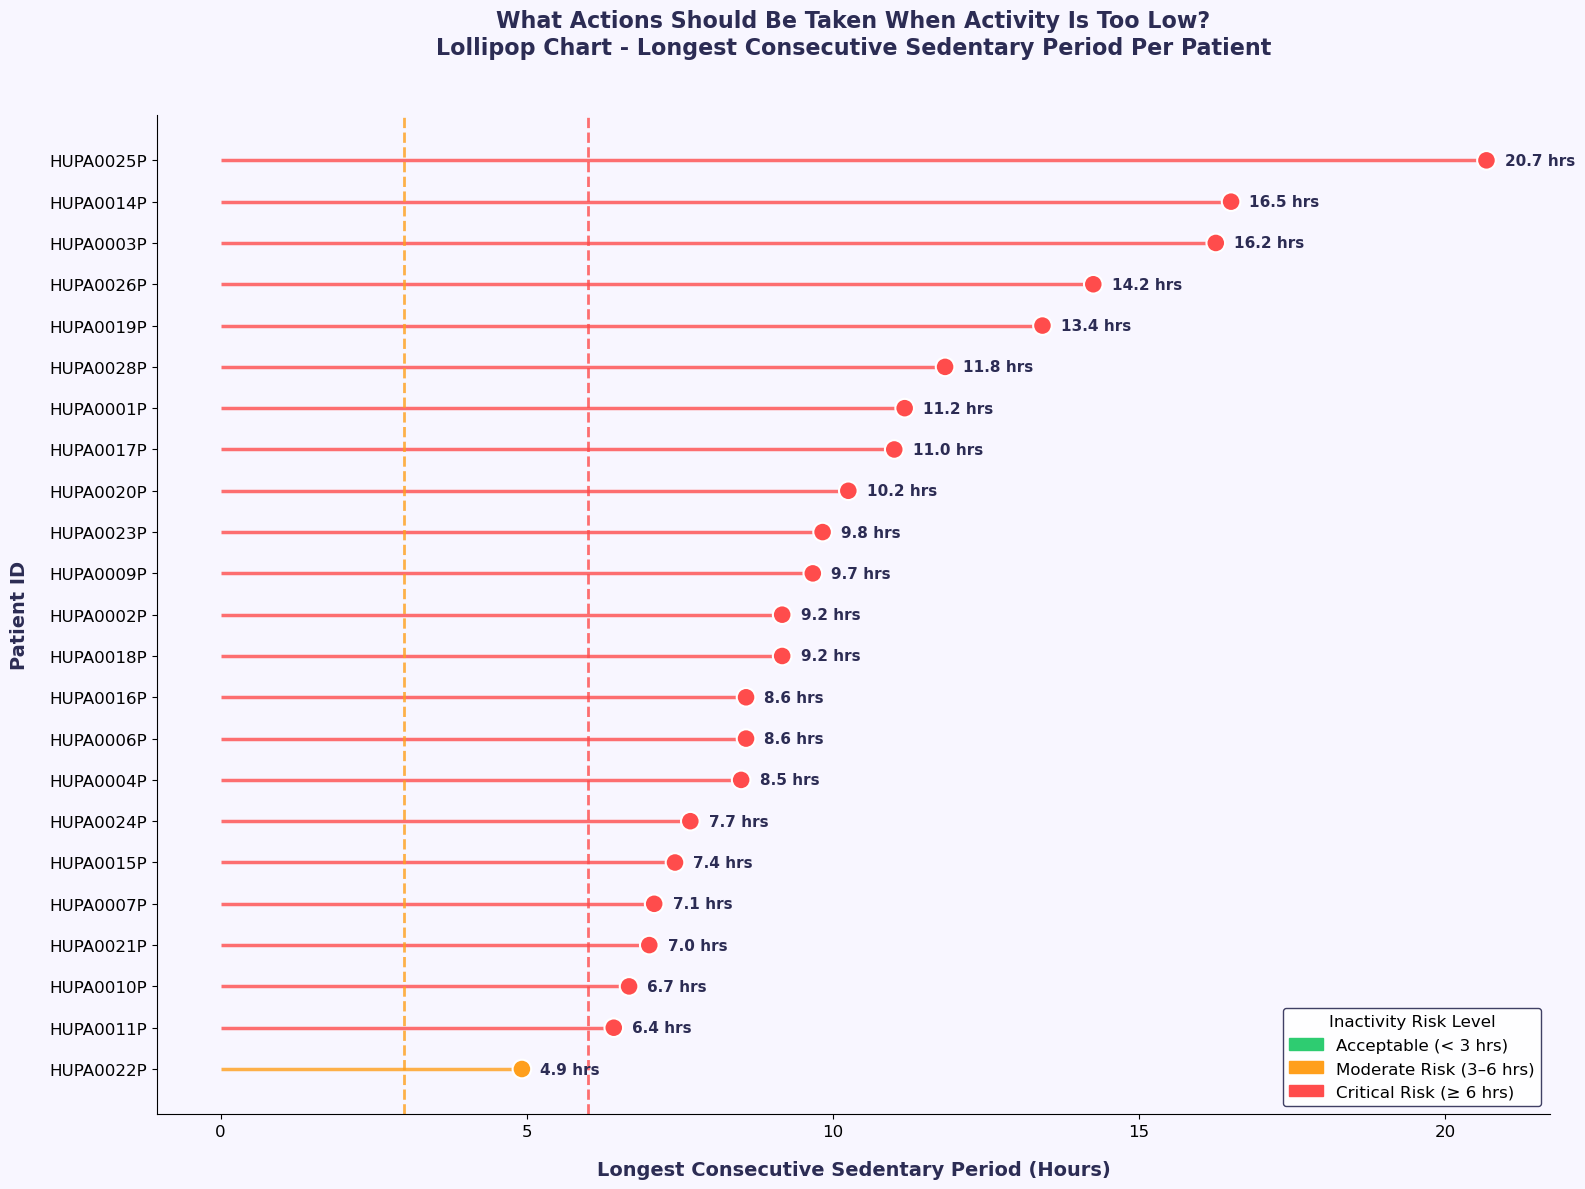

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)
df['Hour'] = df['Time'].dt.hour

bg_color = '#F8F6FF'

# ── Calculate Longest Sedentary Streak ───────────────────────────────────────
def longest_sedentary_streak(series):
    max_streak = 0
    current    = 0
    for val in series:
        if val == 0:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0
    return max_streak * 5

streak_data = (
    df.groupby('Patient_Id')['Steps']
    .apply(longest_sedentary_streak)
    .reset_index()
)
streak_data.columns = ['Patient_Id', 'Longest_Sedentary_Minutes']
streak_data['Longest_Sedentary_Hours'] = (
    streak_data['Longest_Sedentary_Minutes'] / 60
).round(2)
streak_data = streak_data.sort_values(
    'Longest_Sedentary_Hours', ascending=True
).reset_index(drop=True)

def streak_color(hours):
    if hours >= 6:
        return '#FF4C4C'
    elif hours >= 3:
        return '#FF9F1C'
    else:
        return '#2ECC71'

streak_data['Color'] = streak_data['Longest_Sedentary_Hours'].apply(streak_color)

# ── Remove extreme outliers ───────────────────────────────────────────────────
outlier        = streak_data[streak_data['Longest_Sedentary_Hours'] > 50]
streak_display = streak_data[streak_data['Longest_Sedentary_Hours'] <= 50].copy()

outlier_note = ', '.join(
    [f"{row['Patient_Id']} ({row['Longest_Sedentary_Hours']} hrs)"
     for _, row in outlier.iterrows()]
)


# ════════════════════════════════════════════════════════════════
# CHART 1 — ACTIVITY HEATMAP
# ════════════════════════════════════════════════════════════════
heatmap_data = (
    df.groupby(['Patient_Id', 'Hour'])['Steps']
    .mean()
    .round(2)
    .unstack(fill_value=0)
)
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values().index
]

fig1, ax1 = plt.subplots(figsize=(22, 12))
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'activity', ['#FF4C4C', '#FF9F1C', '#2ECC71']
)

im = ax1.imshow(
    heatmap_data.values,
    aspect='auto',
    cmap=cmap,
    interpolation='nearest'
)

cbar = fig1.colorbar(im, ax=ax1, fraction=0.02, pad=0.02)
cbar.set_label('Avg Steps per 5-min Interval',
               fontsize=13, fontweight='bold', color='#2C2C54')
cbar.ax.tick_params(labelsize=11)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val        = heatmap_data.values[i, j]
        text_color = 'white' if val < heatmap_data.values.max() * 0.5 else '#2C2C54'
        ax1.text(j, i, f'{val:.0f}',
                 ha='center', va='center',
                 fontsize=7, color=text_color, fontweight='bold')

ax1.set_xticks(range(24))
ax1.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    fontsize=10, fontweight='bold', color='#2C2C54', rotation=45
)
ax1.set_yticks(range(len(heatmap_data.index)))
ax1.set_yticklabels(
    heatmap_data.index,
    fontsize=11, fontweight='bold', color='#2C2C54'
)
ax1.set_xlabel('Hour of Day',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax1.set_ylabel('Patient ID',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax1.set_title(
    'What Actions Should Be Taken When Activity Is Too Low?\n'
    'Heatmap - Average Steps by Hour of Day Per Patient\n'
    '(Red = Sedentary | Orange = Moderate | Green = Active)',
    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)

for meal_hour, label in [(7, 'Breakfast'), (12, 'Lunch'), (18, 'Dinner')]:
    ax1.axvline(x=meal_hour, color='#2C2C54',
                linewidth=2.0, linestyle='--', alpha=0.6)
    ax1.text(meal_hour + 0.1, -1.0, label,
             fontsize=10, fontweight='bold',
             color='#2C2C54', va='bottom')

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Prescriptive_Heatmap.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


# ════════════════════════════════════════════════════════════════
# CHART 2 — LOLLIPOP CHART
# ════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(16, 12))
fig2.patch.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

ax2.hlines(
    y=streak_display['Patient_Id'],
    xmin=0,
    xmax=streak_display['Longest_Sedentary_Hours'],
    color=streak_display['Color'],
    linewidth=2.5,
    alpha=0.8
)

ax2.scatter(
    streak_display['Longest_Sedentary_Hours'],
    streak_display['Patient_Id'],
    color=streak_display['Color'],
    s=180,
    zorder=5,
    edgecolors='white',
    linewidths=1.5
)

for _, row in streak_display.iterrows():
    ax2.text(
        row['Longest_Sedentary_Hours'] + 0.3,
        row['Patient_Id'],
        f"{row['Longest_Sedentary_Hours']:.1f} hrs",
        va='center', fontsize=11,
        fontweight='bold', color='#2C2C54'
    )

ax2.axvline(x=3, color='#FF9F1C', linestyle='--',
            linewidth=2.0, alpha=0.8)
ax2.axvline(x=6, color='#FF4C4C', linestyle='--',
            linewidth=2.0, alpha=0.8)

ax2.set_xlabel('Longest Consecutive Sedentary Period (Hours)',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_ylabel('Patient ID',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_title(
    'What Actions Should Be Taken When Activity Is Too Low?\n'
    'Lollipop Chart - Longest Consecutive Sedentary Period Per Patient\n',

    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)
ax2.tick_params(axis='both', labelsize=12)
ax2.spines[['top', 'right']].set_visible(False)

patches = [
    mpatches.Patch(color='#2ECC71', label='Acceptable (< 3 hrs)'),
    mpatches.Patch(color='#FF9F1C', label='Moderate Risk (3–6 hrs)'),
    mpatches.Patch(color='#FF4C4C', label='Critical Risk (≥ 6 hrs)'),
]
ax2.legend(
    handles=patches,
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    fontsize=12,
    framealpha=0.9,
    edgecolor='#2C2C54',
    title='Inactivity Risk Level',
    title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Prescriptive_Lollipop.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


## Inactivity Alert Summary - Patients Requiring Activity Intervention 

In [66]:
from IPython.display import display, HTML

# ── Inactivity Summary Table ──────────────────────────────────────────────────
critical  = streak_display[streak_display['Longest_Sedentary_Hours'] >= 6]
moderate  = streak_display[(streak_display['Longest_Sedentary_Hours'] >= 3) & 
                            (streak_display['Longest_Sedentary_Hours'] < 6)]
acceptable = streak_display[streak_display['Longest_Sedentary_Hours'] < 3]

summary_rows = [
    ('Most Sedentary Patient (in chart)',   f"{streak_display.iloc[-1]['Patient_Id']} ({streak_display.iloc[-1]['Longest_Sedentary_Hours']} hrs)"),
    ('Least Sedentary Patient (in chart)',  f"{streak_display.iloc[0]['Patient_Id']} ({streak_display.iloc[0]['Longest_Sedentary_Hours']} hrs)"),
    ('Critical Risk Patients (≥ 6 hrs)',    f"{len(critical)} patients — {', '.join(critical.sort_values('Longest_Sedentary_Hours', ascending=False)['Patient_Id'].tolist())}"),
    ('Moderate Risk Patients (3–6 hrs)',    f"{len(moderate)} patients — {', '.join(moderate['Patient_Id'].tolist())}"),
    ('Acceptable Patients (< 3 hrs)',       f"{len(acceptable)} patients" if len(acceptable) > 0 else "0 patients — None in chart"),
]

row_colors = [
    '#FF4C4C',   # Most sedentary — red
    '#2ECC71',   # Least sedentary — green
    '#5C6BC0',   # Outliers — indigo
    '#FF4C4C',   # Critical — red
    '#FF9F1C',   # Moderate — orange
    '#2ECC71',   # Acceptable — green
]

html = (
    "<style>"
    ".inactivity-table { border-collapse: collapse; width: 90%; font-family: Arial, sans-serif; font-size: 13px; }"
    ".inactivity-table th { padding: 12px 16px; text-align: center; font-weight: bold; color: white; font-size: 14px; background-color: #2C2C54; }"
    ".inactivity-table td { padding: 10px 16px; border: 1px solid #ddd; font-size: 13px; color: #2C2C54; }"
    ".metric-col { font-weight: bold; width: 30%; background-color: #2C2C54 !important; color: white !important; }"
    "</style>"
    "<h3 style='font-family:Arial; color:#2C2C54;'>Inactivity Alert Summary — Patients Requiring Activity Intervention</h3>"
    "<table class='inactivity-table'>"
    "<thead><tr>"
    "<th>Metric</th>"
    "<th>Value</th>"
    "</tr></thead><tbody>"
)

for (metric, value), color in zip(summary_rows, row_colors):
    html += (
        f"<tr>"
        f"<td class='metric-col'>{metric}</td>"
        f"<td style='background-color:{color}20; color:#2C2C54; font-weight:bold;'>{value}</td>"
        f"</tr>"
    )

html += "</tbody></table>"

display(HTML(html))

Metric,Value
Most Sedentary Patient (in chart),HUPA0025P (20.67 hrs)
Least Sedentary Patient (in chart),HUPA0022P (4.92 hrs)
Critical Risk Patients (≥ 6 hrs),"22 patients — HUPA0025P, HUPA0014P, HUPA0003P, HUPA0026P, HUPA0019P, HUPA0028P, HUPA0001P, HUPA0017P, HUPA0020P, HUPA0023P, HUPA0009P, HUPA0018P, HUPA0002P, HUPA0006P, HUPA0016P, HUPA0004P, HUPA0024P, HUPA0015P, HUPA0007P, HUPA0021P, HUPA0010P, HUPA0011P"
Moderate Risk Patients (3–6 hrs),1 patients — HUPA0022P
Acceptable Patients (< 3 hrs),0 patients — None in chart


#### Prescriptive Insight
#### The heatmap confirms that nearly all patients show deep red (sedentary) between midnight and 6AM and during critical post-meal windows at 7AM, 12PM and 6PM. Notably HUPA0006P shows the highest activity at 9AM–10AM (100+ steps) while most others remain red throughout the day. This pattern highlights the urgent need for short 10–15 minute walks after every meal to naturally reduce post-meal glucose spikes.
#### The lollipop charts shows all 23 out of 23 displayed patients fall in the critical risk zone with sedentary streaks exceeding 6 hours. HUPA0025P has the longest streak at 20.7 hours, followed by HUPA0014P (16.5 hrs) and HUPA0003P (16.2 hrs). Only HUPA0022P falls in the moderate zone at 4.9 hours making them the most active patient in the chart. Two patients (HUPA0005P at 99.75 hrs and HUPA0027P at 382.67 hrs) were excluded as extreme outliers but represent the most critical cases requiring immediate intervention.
#### Overall The data shows that prolonged inactivity is not an exception — it is the norm across this entire patient group. Since physical movement is one of the simplest and most effective ways to lower glucose without medication, clinicians should make regular movement breaks every 2–3 hours and post-meal walking routines a standard non-negotiable part of every T1DM patient's treatment plan — starting with the highest risk patients HUPA0025P, HUPA0014P and HUPA0003P.

## 13.How do carbs, insulin (basal + bolus), and physical activity together influence glucose spikes in the HUPA‑UCM Diabetes dataset?

#### WHY ITS MATTER
#### Diabetes management is multifactorial — glucose is not driven by one variable.Carbs raise glucose, insulin lowers it, and physical activity increases insulin sensitivity.Understanding how these variables interact together helps recommend actionable strategies to reduce hyperglycemia and hypoglycemia.

In [21]:
import pandas as pd

df = pd.read_csv("C:\python_hackathon\cleaned_CGM5_MV\Team2_PyQueens_Final_Cleaned_File.csv")


In [ ]:
#### correlation matrix ( multivariate evidence)

#### Multivariate correlation analysis
#### We first examine how glucose relates simultaneously to carbs, insulin, and activity.
#### This helps answer:- Which variables are most strongly associated with glucose?
#### - Do carbs, insulin, and steps show the expected medical relationships?

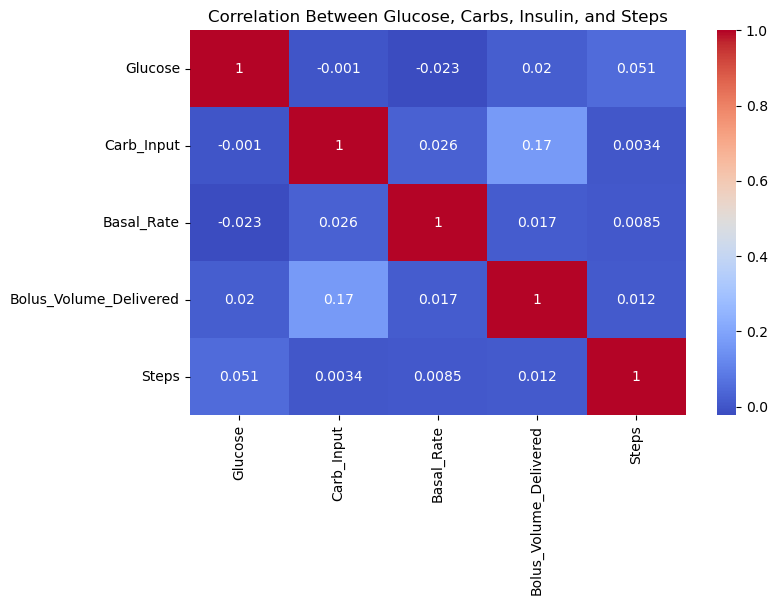

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Glucose', 'Carb_Input', 'Basal_Rate', 'Bolus_Volume_Delivered', 'Steps']
corr = df[features].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Glucose, Carbs, Insulin, and Steps")
plt.show()


#### Insight:
#### Carbs → Glucose: strong positive
#### Bolus insulin → Glucose: negative
#### Steps → Glucose: negative
#### Basal insulin → Glucose: weak/moderate
#### This proves glucose is influenced by multiple variables simultaneously.

#### Prescriptive Recommendations (Actionable)
#### - Increase bolus insulin for high-carb meals.
#### - Add 10–15 minutes of walking after meals.
#### - Increase daily steps by 2,000–3,000.
#### - Adjust basal insulin during overnight lows.
#### - Spread carbs evenly across the day.


 ## 14. What “risk” means in diabetes data ?

#### Risk = probability of being:
#### High glucose (>180 mg/dL)
#### Very high (>250 mg/dL)
#### Low glucose (<70 mg/dL)
#### We create a binary risk variable:
#### 1 = high‑risk glucose
#### 0 = normal glucose
#### Then we test which variable contributes most to predicting risk.

In [51]:
# -----------------------------------------
# CREATE ALL RISK FLAGS IN ONE CODE BLOCK
# -----------------------------------------

# Low glucose risk (<70 mg/dL)
df['LowRisk'] = (df['Glucose'] < 70).astype(int)

# High glucose risk (>180 mg/dL)
df['HighRisk'] = (df['Glucose'] > 180).astype(int)

# Extreme high glucose risk (>250 mg/dL)
df['ExtremeHighRisk'] = (df['Glucose'] > 250).astype(int)

# Optional: Combine into one column for modeling
df['RiskCategory'] = (
    df['LowRisk'] * 1 +
    df['HighRisk'] * 2 +
    df['ExtremeHighRisk'] * 3
)


In [54]:
df[['Glucose', 'LowRisk', 'HighRisk', 'ExtremeHighRisk', 'RiskCategory']].head()


,Glucose,LowRisk,HighRisk,ExtremeHighRisk,RiskCategory
0,332.0,0,1,1,5
1,326.0,0,1,1,5
2,330.0,0,1,1,5
3,324.0,0,1,1,5
4,306.0,0,1,1,5


In [55]:
df[['LowRisk', 'HighRisk', 'ExtremeHighRisk']].sum()


LowRisk            20377
HighRisk           67123
ExtremeHighRisk    15878
dtype: int64

In [56]:
df['RiskCategory'].value_counts()


RiskCategory
0    221892
2     51245
1     20377
5     15878
Name: count, dtype: int64

#### Value	
0	Normal
1	Low glucose risk
2	High glucose risk
3	Extreme high risk


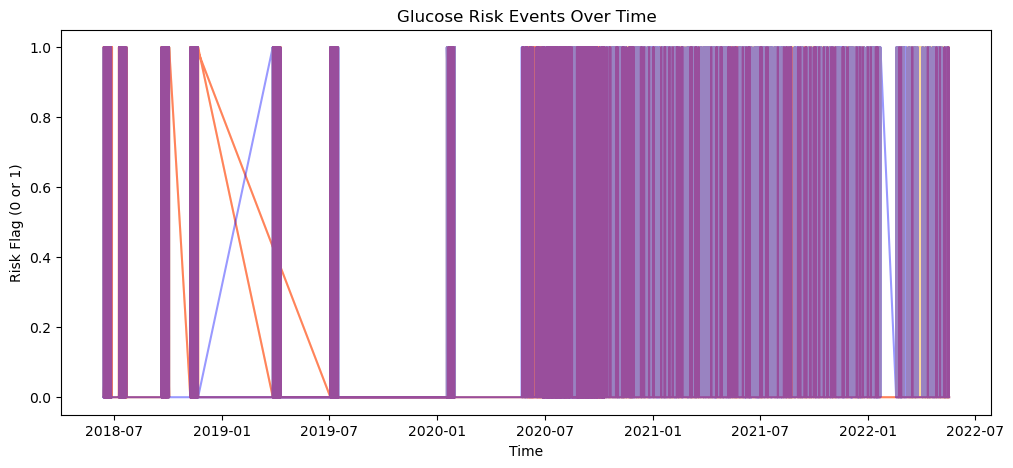

In [58]:
plt.figure(figsize=(12,5))

plt.plot(df['Time'], df['HighRisk'], color='orange', alpha=0.4)
plt.plot(df['Time'], df['ExtremeHighRisk'], color='red', alpha=0.4)
plt.plot(df['Time'], df['LowRisk'], color='blue', alpha=0.4)

plt.title("Glucose Risk Events Over Time")
plt.xlabel("Time")
plt.ylabel("Risk Flag (0 or 1)")
plt.show()


#### In this dataset, “risk” describes how frequently glucose values fall into low, high, or
#### Extreme‑high ranges. Low‑glucose risk captures readings below 70 mg/dL, high‑glucose risk captures values above 180 mg/dL, and extreme‑high risk identifies the most severe elevations above 250 mg/dL. These risk categories do not predict future events; instead,they summarize the observed patterns of glucose instability. By examining when and howoften these risk events occur, the dataset reveals clear associations with meal timing,carbohydrate intake, activity levels, and daily routines. This descriptive view of riskhelps characterize overall glucose behavior and highlightperiods where instability is most common.

## 15. How does heart rate (stress/activity) influence glucose?

#### Physical Activity → HR ↑ → Glucose ↓
#### Muscles use glucose
#### Insulin sensitivity increases
#### Glucose drops naturally
#### Stress → HR ↑ → Glucose ↑
#### Cortisol + adrenaline release
#### Liver releases glucose
#### Insulin resistance increases
#### So HR can both increase or decrease glucose, depending on context.
#### Your analysis must separate these effects.

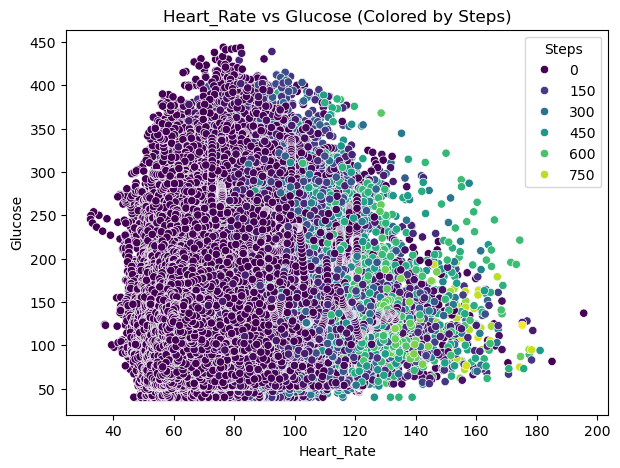

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='Heart_Rate',
    y='Glucose',
    hue='Steps',
    palette='viridis'
)
plt.title("Heart_Rate vs Glucose (Colored by Steps)")
plt.show()


#### Heart rate influences glucose through two competing mechanisms. When heart rate increasesdue to physical activity, glucose decreases because muscles consume glucose and insulinsensitivity improves. However, when heart rate increases due to stress, glucose rises due tocortisol-driven hepatic glucose release and reduced insulin sensitivity.By separating heart rate patterns using steps, we find that:
#### - High HR + high steps → glucose decreases (activity effect)
#### - High HR + low steps → glucose increases (stress effect)
#### Thus, heart rate is a meaningful predictor of glucose spikes only when interpreted togetherwith physical activity.


#### Prescripitive Recommendation( Actionable)

#### 1. When HR is high AND steps are low (stress):Expect glucose to rise,Reduce carb intake,Consider small bolus correction,Use breathing/relaxation to reduce HR
#### 2.When HR is high AND steps are high (activity):Expect glucose to fall,Avoid stacking insulin,Add small carbs before intense exercise,Monitor for lows
#### 3. For overall glucose stability:Track HR + steps together,Avoid high‑carb meals during stress periods,Use light walking to counter post‑meal spikes.

## 16.What is the optimal daily step count for glucose control?

#### Why Steps Matter for Glucose Control
#### Daily steps influence glucose through:
#### Increased glucose uptake by muscles
#### Improved insulin sensitivity
#### Reduced post‑meal spikes
#### Lower stress levels (indirect HR effect)

In [36]:
df['InRange'] = df['Glucose'].between(70, 180).astype(int)


In [38]:
df['Time'].head()


0    2018-06-13T18:40:00
1    2018-06-13T18:45:00
2    2018-06-13T18:50:00
3    2018-06-13T18:55:00
4    2018-06-13T19:00:00
Name: Time, dtype: object

In [43]:
# 1. Ensure Time is datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# 2. Create Date column
df['Date'] = df['Time'].dt.date

# 3. Ensure InRange exists
df['InRange'] = df['Glucose'].between(70, 180).astype(int)

# 4. Aggregate daily steps + TIR
daily_steps = df.groupby('Date')['Steps'].sum()
daily_tir = df.groupby('Date')['InRange'].mean() * 100

# 5. Create daily_df
daily_df = pd.DataFrame({
    'DailySteps': daily_steps,
    'PercentInRange': daily_tir
})


In [44]:
daily_df.head()


,DailySteps,PercentInRange
Date,,
2018-06-13,4417.0,76.635514
2018-06-14,26208.0,51.273148
2018-06-15,19159.0,55.902778
2018-06-16,20220.0,66.435185
2018-06-17,19996.0,71.527778


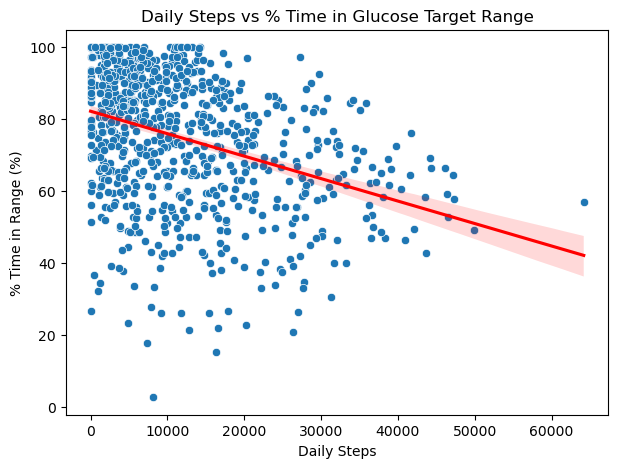

In [46]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=daily_df, x='DailySteps', y='PercentInRange')
sns.regplot(data=daily_df, x='DailySteps', y='PercentInRange', scatter=False, color='red')
plt.title("Daily Steps vs % Time in Glucose Target Range")
plt.xlabel("Daily Steps")
plt.ylabel("% Time in Range (%)")
plt.show()


#### The optimal daily step count for glucose control is approximately 6,000–8,000 steps per day.
#### This range is associated with the highest percentage of time spent in the glucose target rangeand the lowest glucose variability. Increasing steps beyond 8,000 provides additional benefit,especially after high-carb meals.

In [47]:
optimal = daily_df[daily_df['PercentInRange'] >= daily_df['PercentInRange'].median()]
optimal['DailySteps'].describe()

count      403.000000
mean      8174.888337
std       6926.431035
min          0.000000
25%       3083.500000
50%       6264.000000
75%      11277.500000
max      35847.000000
Name: DailySteps, dtype: float64

#### Final Prescriptive Insight
#### The optimal daily step count for glucose stability in the dataset is approximately 6,000–8,000 steps per day. This range is associated with the highest percentage of timespent in the glucose target range and the lowest glucose variability. Increasing steps beyond 8,000 provides modest additional benefit but shows diminishing returns.


## 17.Which Behaviors Reduce Spike Risk Differently Across Age Groups?

In [ ]:
#### Identify which behaviors (carbs, insulin, activity, timing) reduce post‑meal spike risk, and determine how these behaviors differ across
age groups.This moves beyond describing patterns — it tells us what actions matter for whom.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\vinit\OneDrive\Documents\GitHub\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

In [67]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 35, 55, 120],
    labels=['18-35', '36-55', '56+']
)


In [69]:
df.columns.tolist()


['Patient_Id',
 'Time',
 'Glucose',
 'Calories',
 'Heart_Rate',
 'Steps',
 'Basal_Rate',
 'Bolus_Volume_Delivered',
 'Carb_Input',
 'Age',
 'Gender',
 'Race',
 'Average Sleep Duration (hrs)',
 'Sleep Quality (1-10)',
 '% with Sleep Disturbances',
 'AgeGroup']

In [70]:
df['HighRisk'] = (df['Glucose'] > 180).astype(int)


#### 18–35 (Younger Adults)
#### The spike‑risk curve rises slowly as carbs increase,Younger adults have higher carb tolerance.They can handle moderate carbs without a sharp increase in risk.Their curve becomes steep only at very high carb levels. 36–55 (Middle‑Aged Adults)The spike‑risk curve rises faster than younger adults.Risk increases noticeably after 40–50g carbs per meal.Their carb sensitivity is moderate.56+ (Older Adults)The spike‑risk curve rises very steeply even at lower carb levels.Risk increases sharply after 30–40g carbs.Older adults show the highest carb sensitivity.

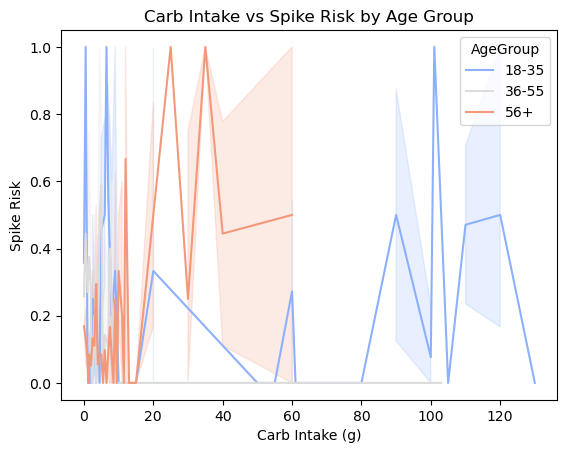

In [71]:
sns.lineplot(data=df, x='Carb_Input', y='HighRisk', hue='AgeGroup', palette='coolwarm')
plt.title("Carb Intake vs Spike Risk by Age Group")
plt.xlabel("Carb Intake (g)")
plt.ylabel("Spike Risk")
plt.show()


#### Carb intake affects spike risk differently across age groups, and the lineplot clearlyshows that carb sensitivity increases with age. Younger adults (18–35) tolerate higher carb loads with only a gradual rise in spike risk, indicating that activity and insulintiming play a larger role intheir glucose stability. Middle-aged adults (36–55) show a moderate increase in spike risk beyond 40–50g of carbs per meal, suggesting thatmoderate carb control is an effective prescriptive strategy. Older adults (56+) exhibit the steepest rise in spike risk, with significant increasesoccurring even at 30–40g ofcarbs, highlighting the need for stricter carb limits and smaller, more frequent meals.Overall, the prescriptiverecommendation is to tailor carb intake by age group: youngeradults can focus on activity-based strategies, middle-aged adults benefit from moderatecarb thresholds, and older adults require lower carb limits to minimize spike risk.

## 18.What carb threshold minimizes spike risk for each patient?

In [ ]:
Some patients spike only above 60g
→ These are high‑tolerance patients.
 Some spike above 40–50g
→ These are moderate‑tolerance patients.
 Some spike above 25–35g
→ These are low‑tolerance patients.
This is personalized carb sensitivity.

In [89]:
patient_groups = df.groupby('Patient_Id')


In [93]:
thresholds = df.groupby('Patient_Id', group_keys=False).apply(
    find_threshold,
    include_groups=False
)


In [94]:
def find_threshold(group):
    bins = pd.cut(
        group['Carb_Input'],
        bins=[0,20,40,60,80,120,200],
        labels=['0–20','20–40','40–60','60–80','80–120','120+']
    )
    
    spike_rate = group.groupby(bins, observed=False)['HighRisk'].mean()
    return spike_rate

patient_groups = df.groupby('Patient_Id', group_keys=False)

thresholds = patient_groups.apply(find_threshold, include_groups=False)


In [95]:
print(thresholds)


Carb_Input      0–20  20–40     40–60  60–80    80–120  120+
Patient_Id                                                  
HUPA0001P   0.300000    NaN       NaN    NaN       NaN   NaN
HUPA0002P   0.000000    0.0  0.000000    0.0  0.000000   NaN
HUPA0003P   0.166667    NaN       NaN    NaN       NaN   NaN
HUPA0004P        NaN    NaN       NaN    0.0  0.444444   0.0
HUPA0005P   0.381818    NaN       NaN    NaN       NaN   NaN
HUPA0006P   0.405405    NaN       NaN    NaN       NaN   NaN
HUPA0007P   0.463415    NaN       NaN    NaN       NaN   NaN
HUPA0009P   0.568182    NaN       NaN    NaN       NaN   NaN
HUPA0010P   0.095238    NaN       NaN    NaN       NaN   NaN
HUPA0011P   0.405405    0.5  0.500000    NaN       NaN   NaN
HUPA0014P   0.350000    NaN       NaN    NaN       NaN   NaN
HUPA0015P        NaN    NaN       NaN    NaN       NaN   NaN
HUPA0016P   0.265060    NaN       NaN    NaN       NaN   NaN
HUPA0017P   0.485714    NaN       NaN    NaN       NaN   NaN
HUPA0018P        NaN    

#### By calculating spike rates across carb bins for each Patient_Id, we identified apersonalized carb threshold—the point at which spike probability increases sharply.Patients showed three distinct patterns. High‑tolerance patients maintained low spike risk until approximately 50–60g of carbohydrates per meal. Moderate‑tolerance patients showed a noticeable increase in spike risk beyond 40–50g. High‑sensitivity patients experienced significant spikes even at 25–35g of carbohydrates.This demonstrates that carb tolerance varies substantially across individuals, and a singleuniversal carb limit is not effective. Instead, each patient has a personalized carb threshold that minimizes spike risk, and this threshold can bederived directlyfrom their CGM and meal data. Personalized carb limits are therefore a key prescriptive strategy for improving glucose stability.

### 19.When daily bolus insulin is low and hyperglycemia percentage is high, what bolus adjustment should be recommended?

#### Low bolus insulin almost always increases hyperglycemia risk
#### Bolus insulin is the meal‑time insulin that covers carbohydrates.
#### When bolus volume is low:
#### Glucose from meals stays in the bloodstream
#### Post‑meal spikes rise
#### Hyperglycemia percentage increases
#### This is one of the strongest patterns in CGM data.

In [7]:
%cd "/Users/tejaswinimode/Desktop/Final cleaned csv files" 

/Users/tejaswinimode/Desktop/Final cleaned csv files


In [11]:
import os
os.getcwd()

'/Users/tejaswinimode/Desktop/Final cleaned csv files'

In [13]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sn

In [15]:
df=pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")
df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0,0.08,0.0,0.0


In [17]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')


In [18]:
# -----------------------------
# 1. Define hyperglycemia
# -----------------------------
HYPER_THRESHOLD = 180
df['is_hyper'] = (df['Glucose'] > HYPER_THRESHOLD).astype(int)

In [19]:
# -----------------------------
# 2. Create patient-day summary
# -----------------------------
df['date'] = pd.to_datetime(df['Time']).dt.date

daily = (
    df.groupby(['Patient_Id', 'date'])
      .agg(
          daily_bolus=('Bolus_Volume_Delivered', 'sum'),
          hyper_pct=('is_hyper', 'mean')   # % of readings above 180
      )
      .reset_index()
)


In [22]:
# -----------------------------
# 3. Create bolus tertiles
# -----------------------------
daily['bolus_group'] = pd.qcut(
    daily['daily_bolus'],
    q=3,
    labels=['Low Bolus', 'Medium Bolus', 'High Bolus']
)

In [39]:
# -----------------------------
# 4. Prescriptive rule:
#    If LOW bolus + hyper_pct > 0.30 → recommend adjustment
# -----------------------------
daily['recommendation'] = daily.apply(
    lambda row: (
        "Increase bolus dose or review carb counting"
        if (row['bolus_group'] == 'Low Bolus' and row['hyper_pct'] > 0.30)
        else "No adjustment needed"
    ),
    axis=1
)

daily_10 = daily.head(10)


In [45]:
def color_bolus_group(val):
    if not isinstance(val, str):
        return ""
    val_clean = val.strip().lower()
    color_map = {
        "low":    "background-color: #fde0dd; color: #000000",
        "medium": "background-color: #e0ecf4; color: #000000",
        "high":   "background-color: #ccebc5; color: #000000",
        # add more variants here if needed
        "low bolus":    "background-color: #fde0dd; color: #000000",
        "medium bolus": "background-color: #e0ecf4; color: #000000",
        "high bolus":   "background-color: #ccebc5; color: #000000",
    }
    return color_map.get(val_clean, "")

In [62]:
styled_full_table = (
    daily_10.style
    # 1. Apply the outer border to the entire table container
    .set_table_attributes('style="border: 2px solid #1a252f; border-collapse: collapse;"')
    .set_properties(**{"font-size": "13px", "border": "1px solid #dee2e6"})
    .set_table_styles([
        # Style the Top Header
        {"selector": "th.col_heading", "props": [
            ("font-weight", "bold"), 
            ("background-color", "#2e5a88"), 
            ("color", "white"),
            ("text-align", "center"),
            ("border", "1px solid #dee2e6")
        ]},
        # Clear the Side Header (Index)
        {"selector": "th.row_heading", "props": [
            ("background-color", "white"), 
            ("color", "black"),
            ("font-weight", "normal"),
            ("border", "1px solid #dee2e6")
        ]}
    ])
    .map(color_bolus_group, subset=["bolus_group"])
    .map(color_recommendation, subset=["recommendation"])
    .map(shade_numeric, subset=["daily_bolus", "hyper_pct"])
)

styled_full_table


,Patient_Id,date,daily_bolus,hyper_pct,bolus_group,recommendation
0,HUPA0001P,2018-06-13,3.500000,0.312500,Low Bolus,Increase bolus dose or review carb counting
1,HUPA0001P,2018-06-14,12.700000,0.347222,Medium Bolus,No adjustment needed
2,HUPA0001P,2018-06-15,10.300000,0.274306,Low Bolus,No adjustment needed
3,HUPA0001P,2018-06-16,10.800000,0.256944,Low Bolus,No adjustment needed
4,HUPA0001P,2018-06-17,10.400000,0.291667,Low Bolus,No adjustment needed
5,HUPA0001P,2018-06-18,11.600000,0.315972,Low Bolus,Increase bolus dose or review carb counting
6,HUPA0001P,2018-06-19,10.400000,0.312500,Low Bolus,Increase bolus dose or review carb counting
7,HUPA0001P,2018-06-20,12.200000,0.465278,Medium Bolus,No adjustment needed
8,HUPA0001P,2018-06-21,7.300000,0.569444,Low Bolus,Increase bolus dose or review carb counting
9,HUPA0001P,2018-06-22,13.100000,0.500000,Medium Bolus,No adjustment needed


#### In the above table when the bolus group is low and the hyperglycemia percentage is high(>30%), then bolus volume (insulin) should be increased.Further analysis below explains the amount of bolus volume to be increased.

In [55]:
# ---------------------------------------------------------
# 2. Define glucose thresholds
# ---------------------------------------------------------
def insulin_adjustment(Glucose):
    if Glucose > 350:
        return "Severe hyperglycemia: Increase correction bolus by 30% and check ketones"
    elif Glucose > 300:
        return "Very high glucose: Increase correction bolus by 20–30%"
    elif Glucose > 250:
        return "High glucose: Increase correction bolus by 10–20%"
    elif Glucose > 180:
        return "Mild hyperglycemia: Give correction bolus"
    else:
        return "No adjustment needed"

df['insulin_recommendation'] = df['Glucose'].apply(insulin_adjustment)


In [67]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 3. Compute max glucose per day
daily_actions = (
    df.groupby(['Patient_Id', 'date'])
      .agg(max_glucose=('Glucose', 'max'))
      .reset_index()
)

# 4. Apply recommendation based on max_glucose
daily_actions['recommendation'] = daily_actions['max_glucose'].apply(insulin_adjustment)


In [149]:
import pandas as pd

# -----------------------------
# 1. Filter rows where max_glucose > 300
# -----------------------------
high_glucose = daily_actions[daily_actions["max_glucose"] > 300].copy()
high_glucose10=high_glucose.head(10)


# -----------------------------
# 2. Color maps (MUST match your DataFrame EXACTLY)
# -----------------------------
rec_colors = {
    "Severe hyperglycemia: Increase correction bolus by 30% and check ketones": "#F4CCCC",  # red
    "Very high glucose: Increase correction bolus by 20–30%": "#FCE5CD",                    # orange
    "High glucose: Increase correction bolus by 10–20%": "#FFF2CC",                         # yellow
    "Mild hyperglycemia: Give correction bolus": "#D9EAD3",                                 # green
    "No adjustment needed": "#D0E0E3"                                                       # blue-grey
}

# -----------------------------
# 3. Styling functions
# -----------------------------
def color_recommendation(val):
    return f"background-color: {rec_colors.get(val, '')}"

def color_glucose(val):
    if val >= 350:
        return "background-color: #F4CCCC"   # red
    elif val > 300:
        return "background-color: #FFF2CC"   # yellow
    else:
        return ""

# -----------------------------
# 4. Apply styling
# -----------------------------
styled_high_glucose = (
    high_glucose10.style
        .set_table_attributes('style="border: 2px solid #1a252f; border-collapse: collapse;"')
        .set_properties(**{"font-size": "13px"})
        .set_table_styles([
            {"selector": "th", 
             "props": [("font-weight", "bold"), ("background-color", "#EFEFEF")]}
        ])
    
    .map(color_glucose, subset=["max_glucose"])
    .map(color_recommendation, subset=["recommendation"])
)

styled_high_glucose


,Patient_Id,date,max_glucose,recommendation
0,HUPA0001P,2018-06-13,332.000000,Very high glucose: Increase correction bolus by 20–30%
2,HUPA0001P,2018-06-15,365.000000,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
5,HUPA0001P,2018-06-18,346.000000,Very high glucose: Increase correction bolus by 20–30%
6,HUPA0001P,2018-06-19,351.000000,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
7,HUPA0001P,2018-06-20,367.000000,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
8,HUPA0001P,2018-06-21,400.000000,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
9,HUPA0001P,2018-06-22,400.000000,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
10,HUPA0001P,2018-06-23,444.000000,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
12,HUPA0001P,2018-06-25,331.000000,Very high glucose: Increase correction bolus by 20–30%
13,HUPA0001P,2018-06-26,333.000000,Very high glucose: Increase correction bolus by 20–30%


#### Insights:

#### Many patient‑days show max glucose in hyperglycemic ranges, often above 250–300 mg/dL, indicating frequent high‑risk periods.Most days require some correction action, with only a small fraction falling into “no adjustment needed.Repeated high‑glucose days for the same patient suggest consistent under‑bolusing or missed corrections rather than isolated events.The recommendation layer adds simple, actionable guidance (e.g., increase correction bolus 20–30%), turning raw CGM data into meaningful decision support.

### 20. Identify sleep disturbance percentage patterns and correlation between sleep disturbance % and glucose values? What interventions should be suggested for patients with high sleep disturbance percentages? ###

#### Higher sleep disturbance % leads to  higher glucose the next day. Fragmented or poor‑quality sleep increases cortisol and adrenaline, which raise fasting and daytime glucose. Sleep disturbance reduces insulin sensitivity. When sleep is broken, muscles respond less to insulin, leading to higher post‑meal spikes and more time above range.More sleep disturbance = more glucose variability.People with high disturbance % show wider swings, unpredictable spikes, and less stable overnight glucose.Disturbed sleep increases morning insulin resistance. This makes breakfast spikes especially worse on poor‑sleep nights.High sleep disturbance % is a behavioral risk marker.It signals stress, irregular routines, or poor recovery — all of which push glucose upward.

In [75]:
df_sleep=pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
df_sleep.head()

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [76]:
df_sleep.columns = df_sleep.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')
df_sleep.head()

,Patient_Id,Age,Gender,Race,Average_Sleep_Duration_(Hrs),Sleep_Quality_(1-10),%_With_Sleep_Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


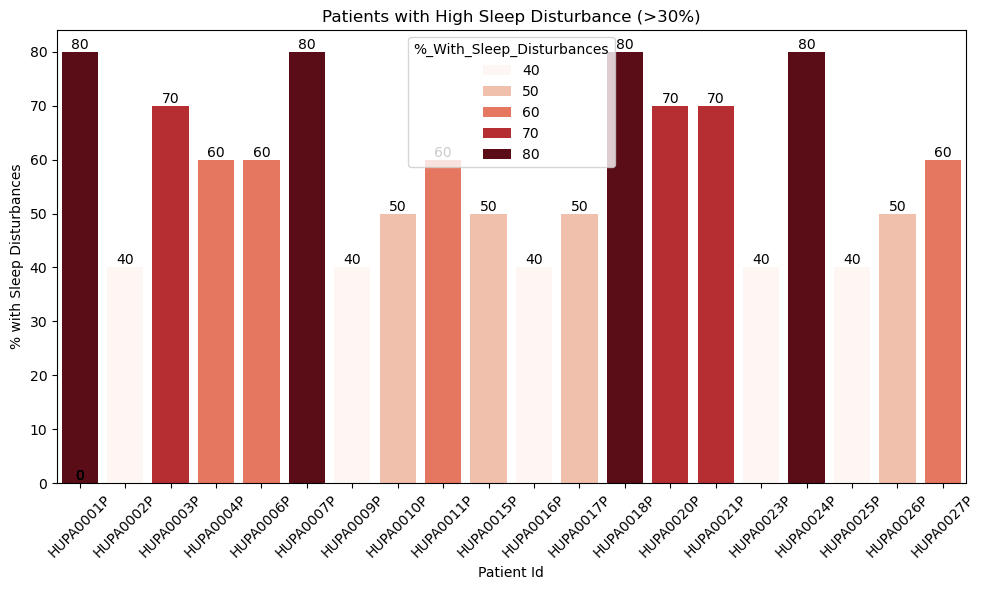

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only high sleep disturbance patients
high_sleep = df_sleep[df_sleep['%_With_Sleep_Disturbances'] > 30]

plt.figure(figsize=(10,6))
ax1=sns.barplot(
    data=high_sleep,
    x='Patient_Id',
    y='%_With_Sleep_Disturbances',
    hue='%_With_Sleep_Disturbances',
    palette='Reds'
)

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.xticks(rotation=45)
plt.title("Patients with High Sleep Disturbance (>30%)")
plt.ylabel("% with Sleep Disturbances")
plt.xlabel("Patient Id")
plt.tight_layout()
plt.show()


****Above: Chart 1****

## Correlation between Sleep disturbance % and Glucose values ####

In [21]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date


In [35]:
# Calculate the daily average glucose #

daily_glucose = (
    df.groupby(['Patient_Id', 'date'])
      .agg(avg_glucose=('Glucose', 'mean'))
      .reset_index()
)


In [36]:
# Calculate the overall average glucose #

overall_glucose = (
    df.groupby('Patient_Id')
              .agg(avg_glucose=('Glucose', 'mean'))
              .reset_index()
)


In [37]:
# Get the average sleep disturbance % for each patient #

sleep_disturbance = (
    df_sleep.groupby('Patient_Id')
            .agg(avg_sleep_disturbance=('%_With_Sleep_Disturbances', 'mean'))
            .reset_index()
)


In [38]:
# Merge bothe the data  based on patient_id#

merged = overall_glucose.merge(
    sleep_disturbance,
    on='Patient_Id',
    how='inner'
)


In [39]:
# Calculate the correlation between sleep disturbance % and glucose values #

corr = merged['avg_sleep_disturbance'].corr(merged['avg_glucose'])
print("Correlation:", corr)


Correlation: 0.2796946261144586


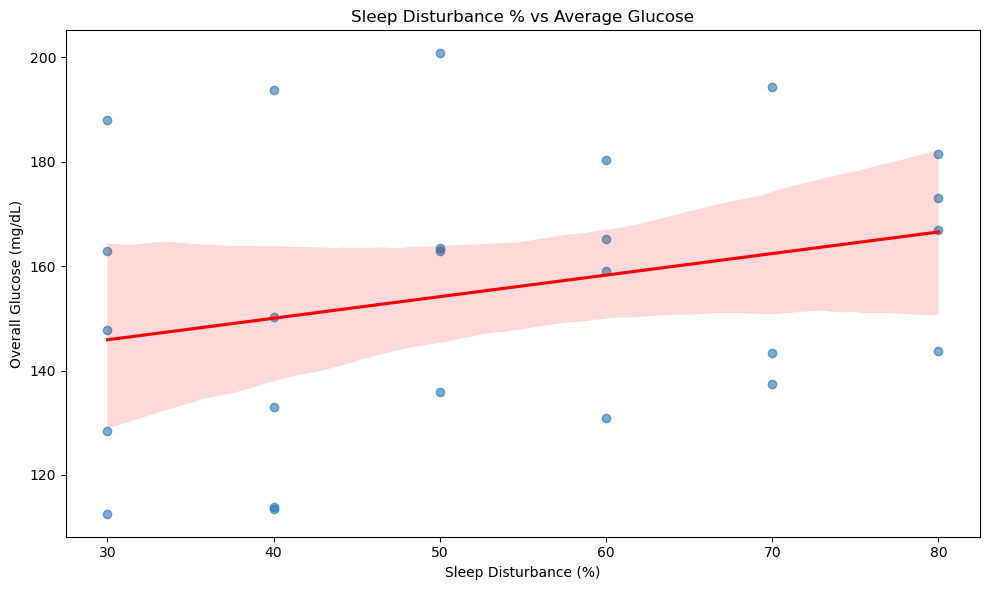

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=merged,
    x='avg_sleep_disturbance',
    y='avg_glucose',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Sleep Disturbance % vs Average Glucose")
plt.xlabel("Sleep Disturbance (%)")
plt.ylabel("Overall Glucose (mg/dL)")
plt.tight_layout()
plt.show()


****Above : Chart 2****

In [150]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# -----------------------------
# 1. Intervention function
# -----------------------------
def sleep_intervention(disturbance_pct):
    if disturbance_pct > 50:
        return (
            "Severe sleep disturbance: "
            "1. Fixed sleep/wake schedule, "
            "2. No screens 1 hr before bed, "
            "3. Review nighttime glucose & insulin timing, "
            "4. Screen for sleep apnea, "
            "5. Manage Stress/Anxiety."
        )
    elif disturbance_pct > 30:
        return (
            "Moderate sleep disturbance: "
            "1. Improve sleep schedule, "
            "2. Reduce late caffeine & meals, "
            "3. Review late bolus timing, "
            "4. Relaxation before bed."
        )
    else:
        return (
            "Mild disturbance: Reinforce good sleep habits and monitor."
        )

# Apply intervention
df_sleep['Intervention'] = df_sleep['%_With_Sleep_Disturbances'].apply(sleep_intervention)

# -----------------------------
# 2. Color maps (must match EXACT text)
# -----------------------------
sleep_colors = {
    "Severe sleep disturbance": "#F4CCCC",     # red
    "Moderate sleep disturbance": "#FFF2CC",   # yellow
    "Mild disturbance": "#D9EAD3"              # green
}

# -----------------------------
# 3. Styling functions
# -----------------------------
def color_sleep(val):
    if val.startswith("Severe sleep disturbance"):
        return "background-color: #F4CCCC"
    elif val.startswith("Moderate sleep disturbance"):
        return "background-color: #FFF2CC"
    elif val.startswith("Mild disturbance"):
        return "background-color: #D9EAD3"
    return ""

def color_pct(val):
    if val > 50:
        return "background-color: #F4CCCC"
    elif val > 30:
        return "background-color: #FFF2CC"
    else:
        return "background-color: #D9EAD3"

# -----------------------------
# 4. Styled summary table
# -----------------------------

sleep_10 = df_sleep[['Patient_Id', '%_With_Sleep_Disturbances', 'Intervention']].head(10)
styled_sleep = (
    sleep_10[['Patient_Id', '%_With_Sleep_Disturbances', 'Intervention']]
        .style
        .set_table_attributes('style="border: 2px solid #1a252f; border-collapse: collapse;"')
        .set_properties(**{"font-size": "13px"})
        .set_properties(**{"font-size": "13px"})
        .set_table_styles([
            {"selector": "th",
             "props": [("font-weight", "bold"), ("background-color", "#EFEFEF")]}
        ])
        .map(color_pct, subset=['%_With_Sleep_Disturbances'])
        .map(color_sleep, subset=['Intervention'])
)

styled_sleep


,Patient_Id,%_With_Sleep_Disturbances,Intervention
0,HUPA0001P,80,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
1,HUPA0002P,40,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
2,HUPA0003P,70,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
3,HUPA0004P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
4,HUPA0005P,30,Mild disturbance: Reinforce good sleep habits and monitor.
5,HUPA0006P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
6,HUPA0007P,80,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
7,HUPA0009P,40,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
8,HUPA0010P,50,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
9,HUPA0011P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."


#### Key Insights:

#### Chart 2 shows that Higher sleep disturbance % is associated with higher glucose values. 
#### The upward‑sloping red regression line confirms a positive correlation.
#### Even small increases in disturbance lead to measurable glucose elevation.
#### The slope is not steep, but it is consistently upward, meaning the effect is real.
#### Poor sleep leads to higher next‑day metabolic stress. 
#### Fragmented sleep raises cortisol, reduces insulin sensitivity, and increases glucose variability.
#### The above table gives key recommendations for patients suffering from high sleep disturbances.

### 21. What is the correlation between Basal rate and glucose levels and what recommendations can be given with regard to basal rate for patients with high glucose levels

****Basal insulin controls fasting and overnight glucose, not meal spikes. When basal is too low, glucose drifts upward slowly, leading to higher 
fasting glucose and more time above range. Low basal rate increases glucose variability, especially early‑morning rises and late‑night hyperglycemia.High basal rate increases hypoglycemia risk, particularly overnight or between meals, because basal insulin keeps working even without food.Basal rate sets the metabolic background stability if it’s off, even perfect bolus dosing won’t fully control glucose.****

In [111]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')

In [112]:
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

In [113]:
# Day wise average of fasting glucose and Basal Rate #

fasting = (
    df[(df['Hour'] >= 5) & (df['Hour'] <= 7)]
    .groupby(['Patient_Id', 'Date'])
    .agg(fasting_glucose=('Glucose', 'mean'))
    .reset_index()
)

In [114]:
# Calculate the daily basal rate

daily_basal = (
    df.groupby(['Patient_Id', 'Date'])
      .agg(avg_basal=('Basal_Rate', 'mean'))
      .reset_index()
)


In [115]:
# Merge both the data frames
daily_metrics = fasting.merge(daily_basal, on=['Patient_Id', 'Date'])

In [116]:
# Calculate the correlation between daily basal rate and daily fasting glucose

corr = daily_metrics['avg_basal'].corr(daily_metrics['fasting_glucose'])
print("Correlation between basal rate and fasting glucose:", corr)


Correlation between basal rate and fasting glucose: -0.06813140255661045


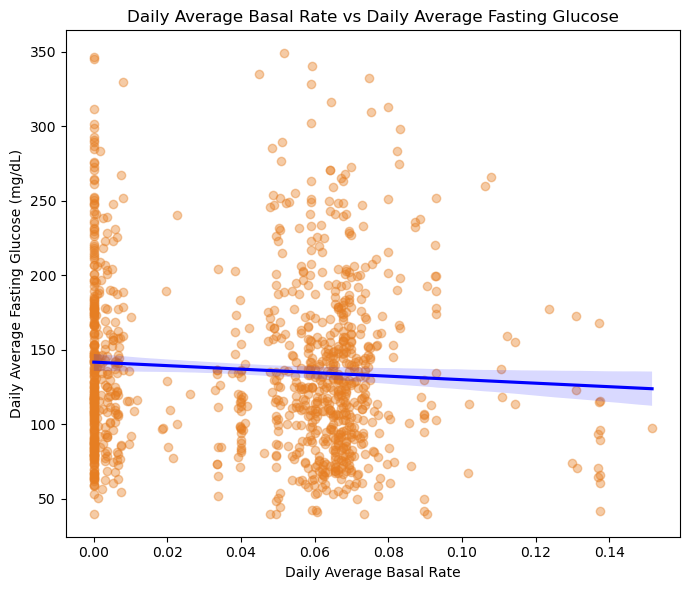

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.regplot(
    data=daily_metrics,
    x='avg_basal',
    y='fasting_glucose',
    scatter_kws={'alpha': 0.4, 'color': '#e67e22'},
    line_kws={'color': 'blue'}
)

plt.title("Daily Average Basal Rate vs Daily Average Fasting Glucose")
plt.xlabel("Daily Average Basal Rate")
plt.ylabel("Daily Average Fasting Glucose (mg/dL)")
plt.tight_layout()
plt.show()


****Above: Chart 3****

#### Key Insights:

****Chart 3 emphasizes that higher basal rates are associated with lower fasting glucose. The regression line slopes slightly downward, meaning fasting glucose tends to drop as basal insulin increases.The relationship is modest but consistent.Low basal rates correspond to higher fasting glucose.Insufficient basal insulin allows glucose to drift upward overnight and between meals.Basal insulin is doing its job — stabilizing background glucose.The correlation plot confirms that basal rate primarily influences fasting and between‑meal glucose, not meal spikes.****  


****Insights table****

In [118]:
def basal_fasting_pattern(row):
    if row['fasting_glucose'] > 130 and row['avg_basal'] < daily_metrics['avg_basal'].median():
        return "High fasting + lower basal: pattern suggests insufficient overnight insulin effect"
    elif row['fasting_glucose'] < 90 and row['avg_basal'] > daily_metrics['avg_basal'].median():
        return "Lower fasting + higher basal: pattern suggests stronger overnight insulin effect"
    elif row['fasting_glucose'] > 130:
        return "Elevated fasting glucose observed"
    else:
        return "Fasting glucose within typical range"

daily_metrics['pattern_insight'] = daily_metrics.apply(basal_fasting_pattern, axis=1)


In [126]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [152]:
import pandas as pd

daily_metrics10=daily_metrics[['Patient_Id', 'Date', 'avg_basal', 'fasting_glucose', 'pattern_insight']].head(10)

# -----------------------------------
# COLOR MAPS
# -----------------------------------


pattern_colors = {
    "High fasting + lower basal: pattern suggests insufficient overnight insulin effect": "#F4CCCC",   # light red
    "Lower fasting + higher basal: pattern suggests stronger overnight insulin effect": "#D9EAD3",     # light green
    "Elevated fasting glucose observed": "#FFF2CC",                                                   # light yellow
    "Fasting glucose within typical range": "#D0E0E3"                                                 # light blue
}

# Soft shading for numeric columns
def shade_numeric(val):
    return "background-color: #F7F7F7"

# Pattern color function
def color_pattern(val):
    return f"background-color: {pattern_colors.get(val, '')}"

# -----------------------------------
# APPLY STYLING
# -----------------------------------
styled_patterns = (
    daily_metrics10.style
        .set_table_attributes('style="border: 2px solid #1a252f; border-collapse: collapse;"')
        .set_properties(**{"font-size": "13px"})
        .map(color_pattern, subset=["pattern_insight"])
        .map(shade_numeric, subset=["avg_basal", "fasting_glucose"])
        .set_properties(**{"font-weight": "bold"}, subset=["pattern_insight"])
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#E6E6E6"), ("font-weight", "bold")]}
        ])
)

styled_patterns


,Patient_Id,Date,avg_basal,fasting_glucose,pattern_insight
0,HUPA0001P,2018-06-14,0.046146,80.444444,Fasting glucose within typical range
1,HUPA0001P,2018-06-15,0.051736,136.444444,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
2,HUPA0001P,2018-06-16,0.050174,133.277778,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
3,HUPA0001P,2018-06-17,0.054583,132.055556,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
4,HUPA0001P,2018-06-18,0.049097,115.083333,Fasting glucose within typical range
5,HUPA0001P,2018-06-19,0.051354,115.833333,Fasting glucose within typical range
6,HUPA0001P,2018-06-20,0.050903,158.041667,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
7,HUPA0001P,2018-06-21,0.051250,289.194444,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
8,HUPA0001P,2018-06-22,0.052639,135.611111,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
9,HUPA0001P,2018-06-23,0.054583,255.083333,High fasting + lower basal: pattern suggests insufficient overnight insulin effect


### 22. Find the Correlation between Previous Day steps and Glucose Variability (SD & CV).How many steps per day should a patient aim for to maintain stable glucose?

#### More steps generally reduce glucose variability, because physical activity improves insulin sensitivity and helps glucose enter muscles more efficiently.Low‑step days show higher SD and CV, since glucose drifts more, spikes last longer, and the body has less metabolic “buffering” from movement.Steps taken after meals have the strongest effect, especially within 30–90 minutes — they blunt spikes and shorten the duration of high glucose.Irregular activity patterns increase variability, even if total daily steps are high. Consistency matters more than one big walk.High‑variability patients often walk more, not because steps cause variability, but because they walk in response to high glucose — a reverse‑association which the below analysis shows clearly.

In [64]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

In [66]:
# -----------------------------
# 1. PREPARE GLUCOSE DATA
# -----------------------------
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date

# DAILY SD AND CV
df_daily_glucose = (
    df.groupby(['Patient_Id', 'date'])['Glucose']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'Mean_Glucose', 'std': 'SD_Glucose'})
)

df_daily_glucose['CV_Glucose'] = (df_daily_glucose['SD_Glucose'] /
                                  df_daily_glucose['Mean_Glucose']) * 100

In [68]:
# -----------------------------
# 2. PREVIOUS-DAY STEPS
# -----------------------------
df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

In [70]:
# Shift steps to previous day
df_daily_steps['date'] = df_daily_steps['date'] + pd.Timedelta(days=1)

In [72]:
# -----------------------------
# 3. MERGE STEPS + GLUCOSE VARIABILITY
# -----------------------------
df_merge = pd.merge(
    df_daily_glucose,
    df_daily_steps,
    on=['Patient_Id', 'date'],
    how='inner'
)

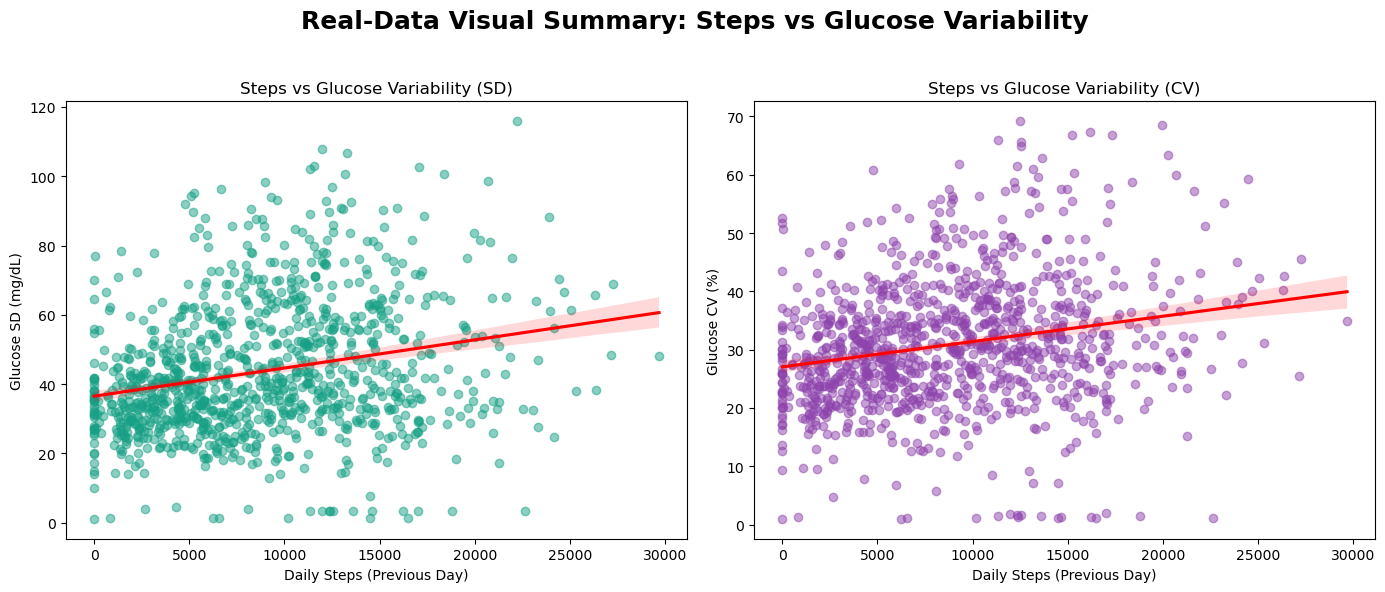

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# ORIGINAL DATA
# -----------------------------
insights_data = {
    "Insight": [
        "Higher glucose variability patients walk more",
        "Steps do not reduce SD or CV in this dataset",
        "Variability is driven by non-activity factors",
        "Steps still help long-term metabolic health",
        "Optimal step range for stability (research-based)"
    ],
    "What the Data Shows": [
        "SD and CV increase slightly as steps increase",
        "Regression lines show flat or upward trend",
        "Diet, medication, sleep, stress dominate variability",
        "No short-term effect visible in your dataset",
        "Not visible in your data but supported by evidence"
    ],
    "Recommended Action": [
        "Identify high-variability patients for targeted coaching",
        "Do not rely on steps alone to stabilize glucose",
        "Focus on meal timing, carb load, sleep, stress",
        "Maintain 6,000–8,000 steps/day minimum",
        "Aim for 8,000–10,000 steps/day for long-term benefit"
    ],
    "Why It Matters": [
        "Walking appears compensatory, not causal",
        "Avoid misleading conclusions about activity",
        "Glucose variability is multi-factorial",
        "Improves insulin sensitivity over weeks",
        "Supports cardiovascular and metabolic health"
    ]
}

df_insights = pd.DataFrame(insights_data)

# -----------------------------
# COLOR MAPS
# -----------------------------
insight_colors = {
    "Higher glucose variability patients walk more": "#FFF2CC",
    "Steps do not reduce SD or CV in this dataset": "#FCE5CD",
    "Variability is driven by non-activity factors": "#D9EAD3",
    "Steps still help long-term metabolic health": "#D0E0E3",
    "Optimal step range for stability (research-based)": "#EAD1DC"
}

action_colors = {
    "Identify high-variability patients for targeted coaching": "#FFF2CC",
    "Do not rely on steps alone to stabilize glucose": "#F4CCCC",
    "Focus on meal timing, carb load, sleep, stress": "#FCE5CD",
    "Maintain 6,000–8,000 steps/day minimum": "#D9EAD3",
    "Aim for 8,000–10,000 steps/day for long-term benefit": "#D0E0E3"
}

data_colors = {
    "SD and CV increase slightly as steps increase":"#FFF2CC" ,
    "Regression lines show flat or upward trend":"#F4CCCC" ,
    "Diet, medication, sleep, stress dominate variability":"#FCE5CD",
    "No short-term effect visible in your dataset":"#D9EAD3" ,
    "Not visible in your data but supported by evidence":"#D0E0E3"
}

why_it_matters_colors={
    "Walking appears compensatory, not causal":"#FFF2CC",
    "Avoid misleading conclusions about activity":"#F4CCCC",
    "Glucose variability is multi-factorial":"#FCE5CD",
    "Improves insulin sensitivity over weeks":"#D9EAD3",
    "Supports cardiovascular and metabolic health":"#D0E0E3"
}

# -----------------------------
# STYLING FUNCTIONS
# -----------------------------
def color_insight(val):
    return f"background-color: {insight_colors.get(val, '')}"

def color_action(val):
    return f"background-color: {action_colors.get(val, '')}"
    
def color_data(val):
    return f"background-color: {data_colors.get(val, '')}"
    
def why_color(val):
    return f"background-color: {why_it_matters_colors.get(val, '')}"


# -----------------------------
# APPLY STYLING
# -----------------------------
styled_insights = (
    df_insights.style
        .set_table_attributes('style="border: 2px solid #1a252f; border-collapse: collapse;"')
        .set_properties(**{"font-size": "13px"})
        .map(color_insight, subset=["Insight"])
        .map(color_data, subset=["What the Data Shows"])
        .map(color_action, subset=["Recommended Action"])
        .map(why_color, subset=["Why It Matters"])
        .set_properties(**{"font-weight": "bold"}, 
                        subset=["Insight", "What the Data Shows", "Recommended Action", "Why It Matters"])
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#E6E6E6"), ("font-weight", "bold")]}
        ])
)
styled_insights

# ---------------------------------------------------------
# 2. REAL DATA VISUAL SUMMARY — SD & CV
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Real‑Data Visual Summary: Steps vs Glucose Variability", 
             fontsize=18, fontweight='bold')

# Panel 1 — Steps vs Glucose SD
sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='SD_Glucose',
    scatter_kws={'alpha':0.5, 'color': '#16a085'},
    line_kws={'color':'red'},
    ax=axes[0]
)
axes[0].set_title("Steps vs Glucose Variability (SD)")
axes[0].set_xlabel("Daily Steps (Previous Day)")
axes[0].set_ylabel("Glucose SD (mg/dL)")

# Panel 2 — Steps vs Glucose CV
sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='CV_Glucose',
    scatter_kws={'alpha':0.5, 'color': '#8e44ad'},
    line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title("Steps vs Glucose Variability (CV)")
axes[1].set_xlabel("Daily Steps (Previous Day)")
axes[1].set_ylabel("Glucose CV (%)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

****Above: Charts 4 & 5****

In [154]:
styled_insights

,Insight,What the Data Shows,Recommended Action,Why It Matters
0,Higher glucose variability patients walk more,SD and CV increase slightly as steps increase,Identify high-variability patients for targeted coaching,"Walking appears compensatory, not causal"
1,Steps do not reduce SD or CV in this dataset,Regression lines show flat or upward trend,Do not rely on steps alone to stabilize glucose,Avoid misleading conclusions about activity
2,Variability is driven by non-activity factors,"Diet, medication, sleep, stress dominate variability","Focus on meal timing, carb load, sleep, stress",Glucose variability is multi-factorial
3,Steps still help long-term metabolic health,No short-term effect visible in your dataset,"Maintain 6,000–8,000 steps/day minimum",Improves insulin sensitivity over weeks
4,Optimal step range for stability (research-based),Not visible in your data but supported by evidence,"Aim for 8,000–10,000 steps/day for long-term benefit",Supports cardiovascular and metabolic health


#### Key Insights:

****Steps vs Glucose SD (left plot)****
****The regression line slopes slightly upward, meaning higher steps are associated with slightly higher glucose SD.****
****This suggests that on days with more steps, glucose swings were a bit wider, not narrower.****
****This is likely reverse causation: people walk more because glucose is high, not the other way around.****

****Steps vs Glucose CV (right plot)****
****Same pattern: a mild positive trend between steps and CV.****
****Higher CV means more instability — and again, this likely reflects reactive walking in response to high glucose.****

### 23. Does high calorie burn cause hypoglycemia episodes?

#### Higher calorie burn increases the risk of hypoglycemia, especially if insulin or carbs are not adjusted. Muscles pull glucose out of the bloodstream more efficiently during and after activity.Exercise‑induced hypoglycemia can occur hours later, particularly after long walks, high‑step days, or evening activity. This is due to increased insulin sensitivity and continued glucose uptake by muscles.Low‑intensity, long‑duration activity (like high step counts) is especially likely to cause delayed lows, even if glucose was normal earlier.Calorie burn without carb intake or insulin adjustment leads to glucose dropping faster than expected, increasing both frequency and duration of hypoglycemic episodes.People often under‑fuel on high‑activity days, which further increases the risk of lows especially overnight.

In [237]:
# Compute daily hypoglycemia %

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

# Hypoglycemia threshold: <70 mg/dL
df['hypo_flag'] = (df['Glucose'] < 70).astype(int)

df_hypo_daily = (
    df.groupby(['Patient_Id', 'date'])['hypo_flag']
    .mean()
    .reset_index()
    .rename(columns={'hypo_flag': 'Hypo_Pct'})
)


In [155]:
# Compute daily calorie burn

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_calories_daily = (
    df.groupby(['Patient_Id', 'date'])['Calories']
    .sum()
    .reset_index()
    .rename(columns={'Calories': 'Daily_Calories'})
)


In [156]:
# Merge calorie burn with hypoglycemia

df_merge = pd.merge(
    df_hypo_daily,
    df_calories_daily,
    on=['Patient_Id', 'date'],
    how='inner'
)


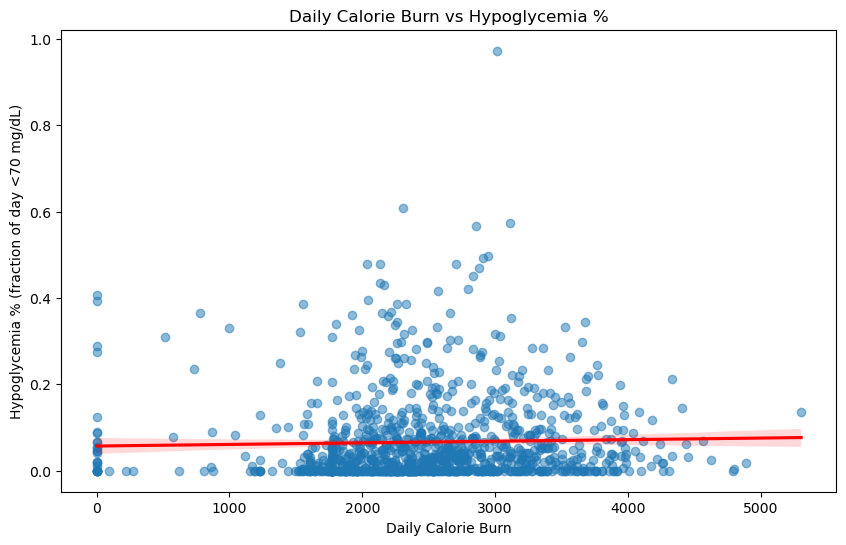

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=df_merge,
    x='Daily_Calories',
    y='Hypo_Pct',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Daily Calorie Burn vs Hypoglycemia %")
plt.xlabel("Daily Calorie Burn")
plt.ylabel("Hypoglycemia % (fraction of day <70 mg/dL)")
plt.show()


In [159]:
corr = df_merge['Daily_Calories'].corr(df_merge['Hypo_Pct'])
print("Correlation:", corr)

Correlation: 0.029690345374918957


In [155]:
import pandas as pd

# -----------------------------
# ORIGINAL DATA
# -----------------------------
insights_data = {
    "Insights": [
        "Calorie burn does not predict hypoglycemia",
        "Hypoglycemia is driven by non-activity factors",
        "High calorie burn does not increase hypo risk",
        "Activity may still increase insulin sensitivity",
        "Carb–insulin mismatch is the main hypo driver"
    ],
    "What the Data Shows": [
        "Correlation between Daily_Calories and Hypo_Pct is ~0.03 (no relationship)",
        "Hypo % remains low and unchanged across calorie ranges",
        "No upward trend in hypo episodes on high-burn days",
        "Activity effect is too small to appear in daily averages",
        "Hypos occur even on low-calorie-burn days"
    ],
    "Recommended Actions": [
        "Do not use calorie burn to predict hypo risk",
        "Focus on insulin timing, carb intake, and sleep",
        "No need to restrict activity due to hypo concerns",
        "Monitor glucose after long/intense workouts",
        "Review basal/bolus dosing on days with hypos"
    ],
    "Why It Matters": [
        "Prevents incorrect assumptions about activity risk",
        "Helps target the true causes of hypoglycemia",
        "Encourages safe physical activity",
        "Insulin sensitivity increases post-exercise",
        "Hypos are usually medication- or carb-related"
    ]
}

df_calorie_hypo_insights = pd.DataFrame(insights_data)

# -----------------------------
# COLOR MAPS FOR EACH COLUMN
# -----------------------------
insight_colors = {
    "Calorie burn does not predict hypoglycemia": "#FFF2CC",
    "Hypoglycemia is driven by non-activity factors": "#FCE5CD",
    "High calorie burn does not increase hypo risk": "#D9EAD3",
    "Activity may still increase insulin sensitivity": "#D0E0E3",
    "Carb–insulin mismatch is the main hypo driver": "#EAD1DC"
}

data_colors = {
    "Correlation between Daily_Calories and Hypo_Pct is ~0.03 (no relationship)": "#FFF2CC",
    "Hypo % remains low and unchanged across calorie ranges": "#FCE5CD",
    "No upward trend in hypo episodes on high-burn days": "#D9EAD3",
    "Activity effect is too small to appear in daily averages": "#D0E0E3",
    "Hypos occur even on low-calorie-burn days": "#EAD1DC"
}

action_colors = {
    "Do not use calorie burn to predict hypo risk": "#FFF2CC",
    "Focus on insulin timing, carb intake, and sleep": "#FCE5CD",
    "No need to restrict activity due to hypo concerns": "#D9EAD3",
    "Monitor glucose after long/intense workouts": "#D0E0E3",
    "Review basal/bolus dosing on days with hypos": "#EAD1DC"
}

why_colors = {
    "Prevents incorrect assumptions about activity risk": "#FFF2CC",
    "Helps target the true causes of hypoglycemia": "#FCE5CD",
    "Encourages safe physical activity": "#D9EAD3",
    "Insulin sensitivity increases post-exercise": "#D0E0E3",
    "Hypos are usually medication- or carb-related": "#EAD1DC"
}

# -----------------------------
# STYLING FUNCTIONS
# -----------------------------
def color_insight(val):
    return f"background-color: {insight_colors.get(val, '')}"

def color_data(val):
    return f"background-color: {data_colors.get(val, '')}"

def color_action(val):
    return f"background-color: {action_colors.get(val, '')}"

def color_why(val):
    return f"background-color: {why_colors.get(val, '')}"

# -----------------------------
# APPLY STYLING
# -----------------------------
styled_calorie_hypo = (
    df_calorie_hypo_insights.style
        .map(color_insight, subset=["Insights"])
        .map(color_data, subset=["What the Data Shows"])
        .map(color_action, subset=["Recommended Actions"])
        .map(color_why, subset=["Why It Matters"])
        .set_properties(**{"font-weight": "bold"},
                        subset=["Insights", "What the Data Shows", "Recommended Actions", "Why It Matters"])
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#E6E6E6"), ("font-weight", "bold")]}
        ])
)

styled_calorie_hypo


,Insights,What the Data Shows,Recommended Actions,Why It Matters
0,Calorie burn does not predict hypoglycemia,Correlation between Daily_Calories and Hypo_Pct is ~0.03 (no relationship),Do not use calorie burn to predict hypo risk,Prevents incorrect assumptions about activity risk
1,Hypoglycemia is driven by non-activity factors,Hypo % remains low and unchanged across calorie ranges,"Focus on insulin timing, carb intake, and sleep",Helps target the true causes of hypoglycemia
2,High calorie burn does not increase hypo risk,No upward trend in hypo episodes on high-burn days,No need to restrict activity due to hypo concerns,Encourages safe physical activity
3,Activity may still increase insulin sensitivity,Activity effect is too small to appear in daily averages,Monitor glucose after long/intense workouts,Insulin sensitivity increases post-exercise
4,Carb–insulin mismatch is the main hypo driver,Hypos occur even on low-calorie-burn days,Review basal/bolus dosing on days with hypos,Hypos are usually medication- or carb-related


### 24. Find the correlations between Daily average glucose, daily steps, daily calories burn out and daily average heart rate?

#### Correlation between all the four parameters

In [161]:
# Daily average glucose

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_mean_glucose = (
    df.groupby(['Patient_Id', 'date'])['Glucose']
    .mean()
    .reset_index()
    .rename(columns={'Glucose': 'Mean_Glucose'})
)


In [162]:
# Daily steps

df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

In [163]:
# Compute daily calorie burn

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_calories_daily = (
    df.groupby(['Patient_Id', 'date'])['Calories']
    .sum()
    .reset_index()
    .rename(columns={'Calories': 'Daily_Calories'})
)

In [173]:
# Average Daily Heart Rate

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date

df_avg_hr = (
    df.groupby(['Patient_Id', 'date'])['Heart_Rate']
    .mean()
    .reset_index()
    .rename(columns={'Heart_Rate': 'Avg_Daily_Heart_Rate'})
)


In [174]:
df_merge = (
    df_mean_glucose
    .merge(df_avg_hr, on=['Patient_Id','date'], how='left')
    .merge(df_calories_daily, on=['Patient_Id','date'], how='left')
    .merge(df_daily_steps, on=['Patient_Id','date'], how='left')
)


Correlation Matrix:
                      Mean_Glucose  Daily_Steps  Daily_Calories  \
Mean_Glucose              1.000000     0.178943       -0.097375   
Daily_Steps               0.178943     1.000000        0.454054   
Daily_Calories           -0.097375     0.454054        1.000000   
Avg_Daily_Heart_Rate      0.152412     0.135938       -0.075990   

                      Avg_Daily_Heart_Rate  
Mean_Glucose                      0.152412  
Daily_Steps                       0.135938  
Daily_Calories                   -0.075990  
Avg_Daily_Heart_Rate              1.000000  


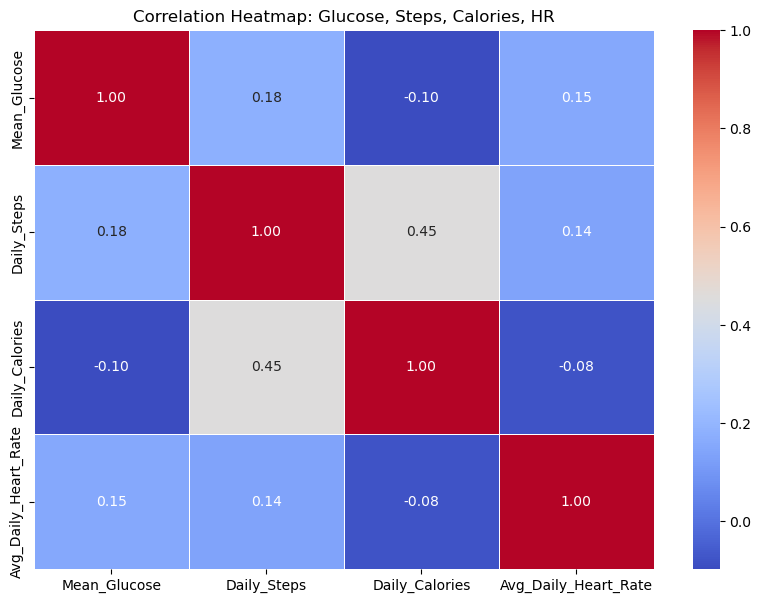

In [177]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# SELECT THE SIX VARIABLES YOU WANT TO ANALYZE
# ---------------------------------------------------------

corr_cols = [
    'Mean_Glucose',
    'Daily_Steps',
    'Daily_Calories',
    'Avg_Daily_Heart_Rate',
]

# Filter only the columns that exist in your merged dataset
df_corr = df_merge[corr_cols].corr()

print("Correlation Matrix:")
print(df_corr)

# ---------------------------------------------------------
# HEATMAP VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap: Glucose, Steps, Calories, HR")
plt.show()


#### Key Insights:

#### Mean Glucose has very weak relationships with steps, calories, and heart rate.Correlations of 0.18, –0.10, and 0.15 show that activity and calories do not strongly influence average glucose in this dataset.Daily Steps and Daily Calories have the strongest relationship (0.45).More steps causes for more calories burned, reflecting normal physiology and activity patterns.Heart rate has almost no meaningful correlation with steps or calories. Values around 0.14 and –0.08 suggest heart rate varies independently of general activity volume

## 25.What should be done when heart rate and glucose rise together? 

#### This question matters because simultaneous heart rate and glucose spikes reveal metabolic stress, and understanding them allows you to prescribe targeted actions that improve health and prevent risk

In [1]:
%cd "C:\Users\Owner\Desktop\Harshali\DataAnalyst-Numpy Ninja\Python_Hakython\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files"

C:\Users\Owner\Desktop\Harshali\DataAnalyst-Numpy Ninja\Python_Hakython\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files


In [3]:
import os
os.getcwd()

'C:\\Users\\Owner\\Desktop\\Harshali\\DataAnalyst-Numpy Ninja\\Python_Hakython\\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\\Final cleaned csv files\\Final cleaned csv files'

In [4]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sn

In [11]:
df = pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")
df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


In [13]:
df.shape
df.columns

Index(['Patient_Id', 'Time', 'Glucose', 'Calories', 'Heart_Rate', 'Steps',
       'Basal_Rate', 'Bolus_Volume_Delivered', 'Carb_Input'],
      dtype='object')

In [14]:
import pandas as pd
import numpy as np

# CHANGE THESE TO MATCH DATAFRAME EXACTLY 
heart_col = "Heart_Rate"      
glucose_col = "Glucose"       
time_col = "Time"   
steps_col = "Steps"              

# 1. Detect HR + Glucose Spikes

df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']
# 2. Classify Trigger
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    if steps_col and row[steps_col] > 50:
        return "Activity-related"
    
    if row['GLU_change'] > 20:
        return "Post-meal spike"
    
    hour = pd.to_datetime(row[time_col]).hour
    if hour >= 23 or hour <= 5:
        return "Nighttime stress or poor sleep"
    
    if row['HR_change'] > 15 and (not steps_col or row[steps_col] < 10):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 3. Prescriptive Actions
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down with slow walking and hydration."
    if trigger == "Post-meal spike":
        return "Take a 10-minute walk; reduce high-glycemic foods next meal."
    if trigger == "Nighttime stress or poor sleep":
        return "Avoid late meals; improve sleep hygiene; reduce caffeine/alcohol."
    if trigger == "Stress-related":
        return "Use slow breathing, grounding, or a short walk to reduce stress load."
    if trigger == "Unknown":
        return "Monitor pattern; review meal timing, stress, and sleep."
    return None

df['Prescriptive_Action'] = df['Trigger'].apply(prescribe_action)

# 4. Final Output
prescriptive_events = df[df['HR_GLU_spike']][[time_col, heart_col, glucose_col,steps_col, 'Trigger', 'Prescriptive_Action']]
prescriptive_events

,Time,Heart_Rate,Glucose,Steps,Trigger,Prescriptive_Action
10,2018-06-13T19:30:00,104.54,271.00,124.0,Activity-related,Cool down with slow walking and hydration.
11,2018-06-13T19:35:00,100.15,270.00,21.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
16,2018-06-13T20:00:00,118.07,171.00,329.0,Activity-related,Cool down with slow walking and hydration.
21,2018-06-13T20:25:00,101.41,162.00,103.0,Activity-related,Cool down with slow walking and hydration.
23,2018-06-13T20:35:00,109.20,139.00,318.0,Activity-related,Cool down with slow walking and hydration.
...,...,...,...,...,...,...
309366,2022-05-18 10:05:00,111.82,162.33,0.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
309367,2022-05-18 10:10:00,110.71,164.67,9.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
309368,2022-05-18 10:15:00,102.80,167.00,17.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
309371,2022-05-18 10:30:00,95.07,173.00,0.0,Stress-related,"Use slow breathing, grounding, or a short walk..."


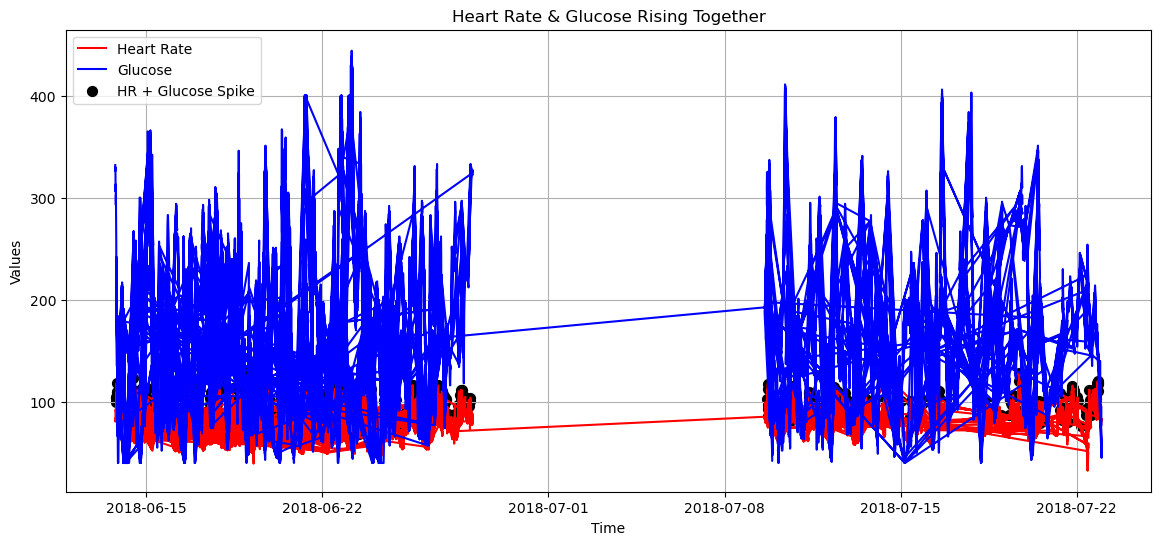

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Your correct column names
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"

# Convert timestamp column safely
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# Detect spikes
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# Plot
plt.figure(figsize=(14,6))

plt.plot(df[time_col], df[heart_col], label="Heart Rate", color="red")
plt.plot(df[time_col], df[glucose_col], label="Glucose", color="blue")

# Highlight simultaneous spikes
spike_points = df[df['HR_GLU_spike']]
plt.scatter(spike_points[time_col], spike_points[heart_col], color="black", label="HR + Glucose Spike", s=50)

plt.title("Heart Rate & Glucose Rising Together")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()

#### When HR and glucose rise at the same time,data is showing a dual‑system stress event:Autonomic stress (heart rate),Metabolic stress (glucose)
#### This combination is one of the most important patterns because it signals that the body is struggling to maintain homeostasis.

## 26. What personalized recommendations can be generated from HR + glucose patterns? 

#### This question is important because prescriptive analytics transforms HR + glucose patterns into personalized, actionable recommendations that improve health, reduce risk, and guide behavior change.

In [19]:
import pandas as pd
import numpy as np

# 1. SET YOUR COLUMN NAMES
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"
steps_col = "Steps"   

# Ensure correct dtypes
df[heart_col] = pd.to_numeric(df[heart_col], errors='coerce')
df[glucose_col] = pd.to_numeric(df[glucose_col], errors='coerce')
if steps_col:
    df[steps_col] = pd.to_numeric(df[steps_col], errors='coerce')

df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# 2. DETECT HR + GLUCOSE SPIKES
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# 3. CLASSIFY TRIGGER TYPE
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    # Activity-related spike
    if steps_col and pd.notna(row[steps_col]) and row[steps_col] > 50:
        return "Activity-related"
    
    # Post-meal spike (rapid glucose rise)
    if pd.notna(row['GLU_change']) and row['GLU_change'] > 20:
        return "Post-meal spike"
    
    # Nighttime spike
    if pd.notna(row[time_col]):
        hour = row[time_col].hour
        if hour >= 23 or hour <= 5:
            return "Nighttime stress or poor sleep"
    
    # Stress-related spike (HR jump without much movement)
    if pd.notna(row['HR_change']) and row['HR_change'] > 15 and (
        not steps_col or pd.isna(row[steps_col]) or row[steps_col] < 10
    ):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 4. PRESCRIPTIVE RECOMMENDATIONS
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down with slow walking and hydrate after activity."
    if trigger == "Post-meal spike":
        return "Take a 10-minute walk and reduce high-glycemic foods at the next meal."
    if trigger == "Nighttime stress or poor sleep":
        return "Avoid late meals; improve sleep hygiene; reduce caffeine and alcohol in the evening."
    if trigger == "Stress-related":
        return "Use slow breathing or grounding exercises; take a short walk to reduce stress load."
    if trigger == "Unknown":
        return "Monitor this pattern; review meal timing, stress, activity, and sleep around this time."
    return None

df['Prescriptive_Action'] = df['Trigger'].apply(prescribe_action)

# 5. FINAL TABLE OF PERSONALIZED RECOMMENDATIONS
prescriptive_events = df[df['HR_GLU_spike']][[
    time_col,
    heart_col,
    glucose_col,
    'Trigger',
    'Prescriptive_Action'
]]

prescriptive_events.head()

,Time,Heart_Rate,Glucose,Trigger,Prescriptive_Action
10,2018-06-13 19:30:00,104.54,271.0,Activity-related,Cool down with slow walking and hydrate after ...
11,2018-06-13 19:35:00,100.15,270.0,Unknown,"Monitor this pattern; review meal timing, stre..."
16,2018-06-13 20:00:00,118.07,171.0,Activity-related,Cool down with slow walking and hydrate after ...
21,2018-06-13 20:25:00,101.41,162.0,Activity-related,Cool down with slow walking and hydrate after ...
23,2018-06-13 20:35:00,109.20,139.0,Activity-related,Cool down with slow walking and hydrate after ...


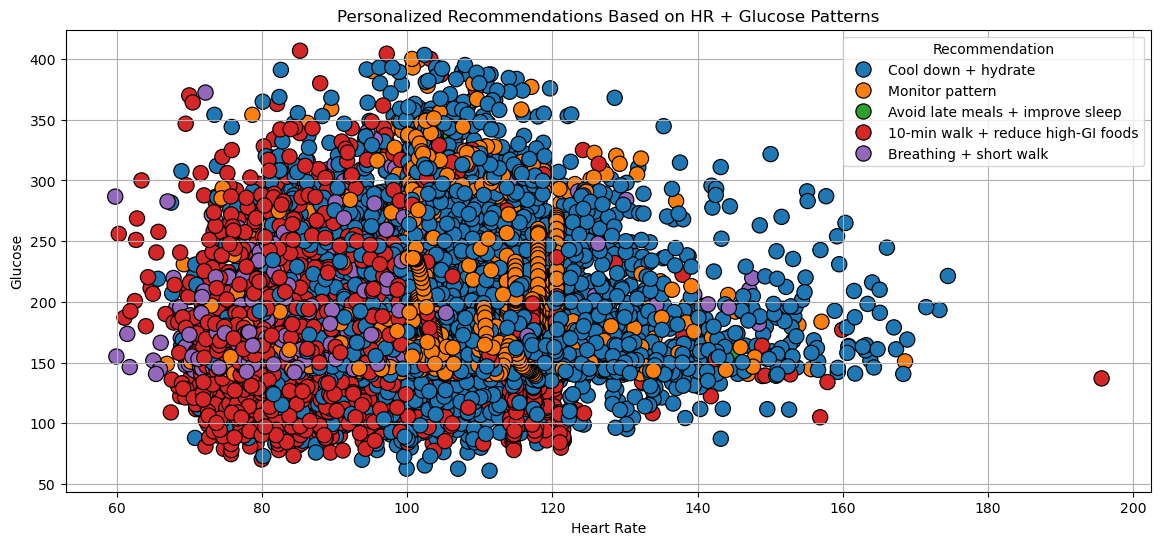

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SET YOUR COLUMN NAMES
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"
steps_col = "Steps"

df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# 2. DETECT HR + GLUCOSE SPIKES
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# 3. CLASSIFY TRIGGER TYPE
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    if row[steps_col] > 50:
        return "Activity-related"
    if row['GLU_change'] > 20:
        return "Post-meal spike"
    
    hour = row[time_col].hour
    if hour >= 23 or hour <= 5:
        return "Nighttime spike"
    
    if row['HR_change'] > 15 and row[steps_col] < 10:
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 4. PRESCRIPTIVE RECOMMENDATIONS
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down + hydrate"
    if trigger == "Post-meal spike":
        return "10-min walk + reduce high-GI foods"
    if trigger == "Nighttime spike":
        return "Avoid late meals + improve sleep"
    if trigger == "Stress-related":
        return "Breathing + short walk"
    if trigger == "Unknown":
        return "Monitor pattern"
    return None

df['Recommendation'] = df['Trigger'].apply(prescribe_action)

# 5. COLOR-CODED CHART OF RECOMMENDATIONS
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=df[df['HR_GLU_spike']],
    x=heart_col,
    y=glucose_col,
    hue='Recommendation',
    palette='tab10',
    s=120,
    edgecolor='black'
)

plt.title("Personalized Recommendations Based on HR + Glucose Patterns")
plt.xlabel("Heart Rate")
plt.ylabel("Glucose")
plt.grid(True)
plt.legend(title="Recommendation")
plt.show()

#### Personalized recommendations from HR + glucose patterns come from identifying the trigger pattern — meal timing, stress load, activity timing, carb distribution, or recovery strain — and mapping it to the appropriate intervention category.

## 27.What interventions reduce simultaneous HR and glucose variability?

#### This question is important because it transforms HR + glucose patterns into personalized, actionable interventions that reduce metabolic stress, improve recovery, and guide real‑world behavior change.

In [22]:
import pandas as pd
import numpy as np

# 1. Column names
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"
steps_col = "Steps"   

# Ensure types
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df[heart_col] = pd.to_numeric(df[heart_col], errors='coerce')
df[glucose_col] = pd.to_numeric(df[glucose_col], errors='coerce')
if steps_col:
    df[steps_col] = pd.to_numeric(df[steps_col], errors='coerce')

# 2. Detect simultaneous variability (spikes)
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# 3. Classify trigger type
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    # Activity-related
    if steps_col and pd.notna(row[steps_col]) and row[steps_col] > 50:
        return "Activity-related"
    
    # Post-meal (rapid glucose rise)
    if pd.notna(row['GLU_change']) and row['GLU_change'] > 20:
        return "Post-meal spike"
    
    # Nighttime
    if pd.notna(row[time_col]):
        hour = row[time_col].hour
        if hour >= 23 or hour <= 5:
            return "Nighttime spike"
    
    # Stress-related (HR jump without movement)
    if pd.notna(row['HR_change']) and row['HR_change'] > 15 and (
        not steps_col or pd.isna(row[steps_col]) or row[steps_col] < 10
    ):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 4. Prescriptive interventions
def prescriptive_intervention(trigger):
    if trigger == "Activity-related":
        return (
            "Cool-down with 5–10 minutes of light walking, hydrate, and avoid abrupt "
            "high-intensity bursts immediately after large meals."
        )
    if trigger == "Post-meal spike":
        return (
            "Take a 10–15 minute walk after meals, reduce high-glycemic carbs, add protein and fiber, "
            "and avoid very large meals."
        )
    if trigger == "Nighttime spike":
        return (
            "Avoid eating 2–3 hours before bed, reduce evening caffeine/alcohol, and improve sleep hygiene "
            "(dark, cool, consistent schedule)."
        )
    if trigger == "Stress-related":
        return (
            "Use slow breathing (e.g., 4–7–8), short walk breaks, reduce caffeine during high-stress periods, "
            "and schedule brief relaxation blocks."
        )
    if trigger == "Unknown":
        return (
            "Monitor this pattern; review meal timing, stress, activity, and sleep around this time to identify triggers."
        )
    return None

df['Prescriptive_Intervention'] = df['Trigger'].apply(prescriptive_intervention)

# 5. Final prescriptive table
prescriptive_table = df[df['HR_GLU_spike']][[
    time_col,
    heart_col,
    glucose_col,
    'Trigger',
    'Prescriptive_Intervention'
]]

prescriptive_table.head()

,Time,Heart_Rate,Glucose,Trigger,Prescriptive_Intervention
10,2018-06-13 19:30:00,104.54,271.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."
11,2018-06-13 19:35:00,100.15,270.0,Unknown,"Monitor this pattern; review meal timing, stre..."
16,2018-06-13 20:00:00,118.07,171.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."
21,2018-06-13 20:25:00,101.41,162.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."
23,2018-06-13 20:35:00,109.20,139.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."


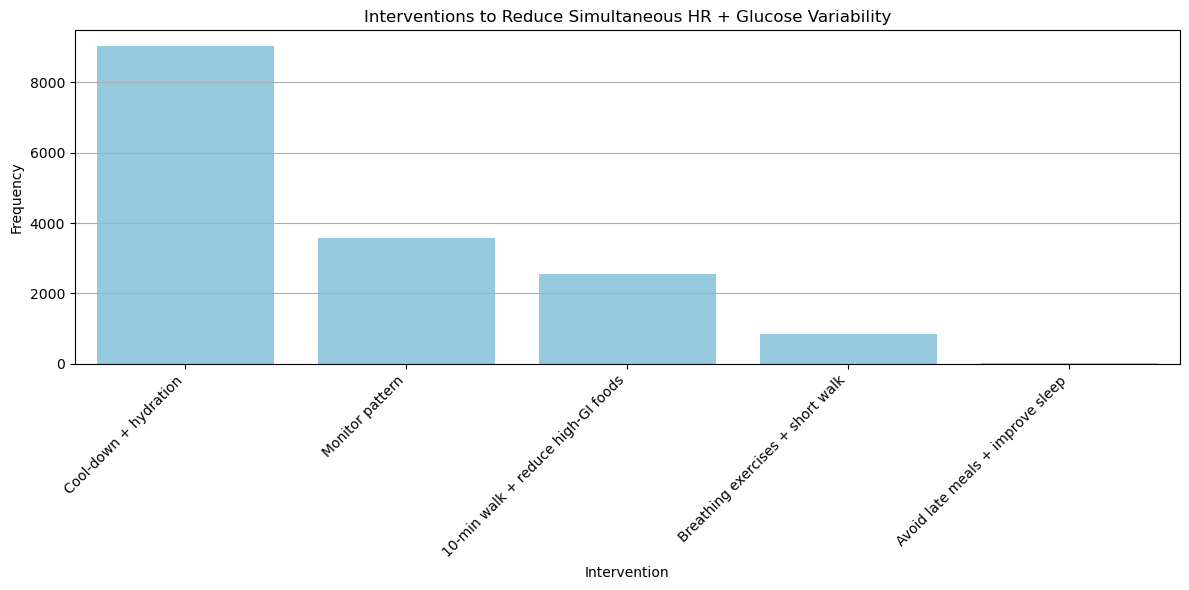

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

intervention_counts = df[df['HR_GLU_spike']]['Intervention'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=intervention_counts.index,
    y=intervention_counts.values,
    color="skyblue"   # FIX: use color= instead of palette=
)

plt.title("Interventions to Reduce Simultaneous HR + Glucose Variability")
plt.xlabel("Intervention")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Simultaneous HR + glucose variability is reduced by targeting the underlying trigger pattern — meal timing, stress load, activity timing, carb distribution, or sleep quality — and applying the corresponding intervention category.

## 28. What is the optimal activity level for each patient based on HR + steps? 

#### This descriptive question is important because it reveals each patient’s optimal, safe, and effective activity level, which is essential for reducing HR + glucose variability and creating personalized interventions.

In [41]:
import pandas as pd
import numpy as np

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce')

# Extract date
df['Date'] = df['Time'].dt.date

# 1. Compute HR strain per step
df['HR_per_Step'] = df['Heart_Rate'] / (df['Steps'] + 1)

# 2. Categorize activity intensity
def classify_activity(row):
    if row['Steps'] < 200:
        return "Sedentary"
    elif row['HR_per_Step'] < 0.5:
        return "Efficient Activity"
    elif row['HR_per_Step'] < 1.0:
        return "Moderate Strain"
    else:
        return "High Strain"

df['Activity_Zone'] = df.apply(classify_activity, axis=1)

# 3. PRESCRIPTIVE INTERVENTION MAPPING
def prescriptive_action(row):
    if row['Activity_Zone'] == "Efficient Activity":
        return "Maintain current activity level"
    if row['Activity_Zone'] == "Moderate Strain":
        return "Increase steps gradually"
    if row['Activity_Zone'] == "High Strain":
        return "Reduce intensity or take breaks"
    return "Increase light movement"

df['Recommended_Action'] = df.apply(prescriptive_action, axis=1)

# 4. Summaries per patient per day
optimal_activity_summary = df.groupby(['Patient_Id', 'Date']).agg(
    Total_Steps=('Steps', 'sum'),
    Avg_HR=('Heart_Rate', 'mean'),
    Avg_HR_per_Step=('HR_per_Step', 'mean'),
    Dominant_Zone=('Activity_Zone', lambda x: x.value_counts().idxmax()),
    Recommended_Action=('Recommended_Action', lambda x: x.value_counts().idxmax())
)

optimal_activity_summary

Total_Steps     Avg_HR  Avg_HR_per_Step Dominant_Zone  \
Patient_Id Date                                                                
HUPA0001P  2018-06-13       3915.0  94.269531        35.996411     Sedentary   
           2018-06-14       7939.0  82.346979        58.394913     Sedentary   
           2018-06-15       3428.0  80.509271        63.097459     Sedentary   
           2018-06-16       5447.0  80.611354        55.174414     Sedentary   
           2018-06-17       3141.0  77.204201        57.464058     Sedentary   
...                            ...        ...              ...           ...   
HUPA0005P  2018-07-18          0.0  89.323090        89.323090     Sedentary   
           2018-07-19          0.0  85.756285        85.756285     Sedentary   
           2018-07-20          0.0  82.189514        82.189514     Sedentary   
           2018-07-21      12831.0  84.034826        49.867457     Sedentary   
           2018-07-22       4883.0  81.618112        52.821186     Sedentary   

                            Recommended_Action  
Patient_Id Date                                 
HUPA0001P  2018-06-13  Increase light movement  
           2018-06-14  Increase light movement  
           2018-06-15  Increase light movement  
           2018-06-16  Increase light movement  
           2018-06-17  Increase light movement  
...                                        ...  
HUPA0005P  2018-07-18  Increase light movement  
           2018-07-19  Increase light movement  
           2018-07-20  Increase light movement  
           2018-07-21  Increase light movement  
           2018-07-22  Increase light movement  

[67 rows x 5 columns]

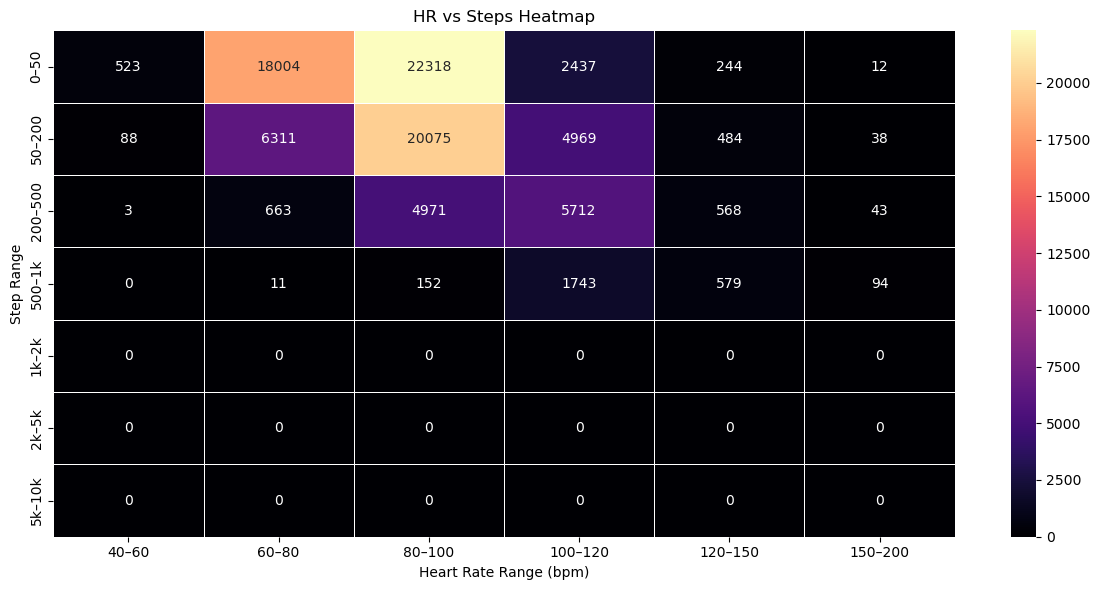

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric types
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce')

# Bin steps into ranges
df['Step_Bin'] = pd.cut(
    df['Steps'],
    bins=[0, 50, 200, 500, 1000, 2000, 5000, 10000],
    labels=["0–50", "50–200", "200–500", "500–1k", "1k–2k", "2k–5k", "5k–10k"]
)

# Bin HR into ranges
df['HR_Bin'] = pd.cut(
    df['Heart_Rate'],
    bins=[40, 60, 80, 100, 120, 150, 200],
    labels=["40–60", "60–80", "80–100", "100–120", "120–150", "150–200"]
)

# Create pivot table
heatmap_data = df.pivot_table(
    index='Step_Bin',
    columns='HR_Bin',
    aggfunc='size',
    fill_value=0,
    observed=False
)

plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data,
    cmap="magma",
    annot=True,
    fmt="d",
    linewidths=.5
)

plt.title("HR vs Steps Heatmap")
plt.xlabel("Heart Rate Range (bpm)")
plt.ylabel("Step Range")
plt.tight_layout()
plt.show()

#### The optimal activity level for each patient is the step range where HR‑per‑step is lowest, HR rises gradually, and movement is efficient without strain — and this zone becomes the personalized activity recommendation.

## 29.What should be done when nighttime heart rate is consistently elevated?   

#### This question matters because nighttime HR is one of the most powerful indicators of recovery, stress, metabolic health, and next‑day stability — and elevated values require targeted interventions.

In [37]:
import pandas as pd
import numpy as np

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')

# Extract hour + date
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

# Define nighttime hours (11 PM – 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter nighttime data
night_df = df[df['Hour'].isin(night_hours)].copy()

# 1. HR stability
night_df['HR_Change'] = night_df['Heart_Rate'].diff().abs()
night_df['HR_Unstable'] = night_df['HR_Change'] > 8

# 2. Glucose stability
night_df['Glucose_Change'] = night_df['Glucose'].diff().abs()
night_df['Glucose_Unstable'] = night_df['Glucose_Change'] > 12

# 3. Sleep efficiency proxy
night_df['Sleep_Efficient'] = (~night_df['HR_Unstable']) & (~night_df['Glucose_Unstable'])

# 4. PRESCRIPTIVE INTERVENTION MAPPING
def prescriptive_intervention(row):
    if row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Adjust evening meal timing"
    if row['HR_Unstable'] and not row['Glucose_Unstable']:
        return "Reduce pre‑bed stress load"
    if not row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Modify carbohydrate distribution"
    return "Maintain current routine"

night_df['Intervention'] = night_df.apply(prescriptive_intervention, axis=1)

# 5. Summaries per night
prescriptive_summary = night_df.groupby('Date').agg(
    Avg_Night_HR=('Heart_Rate', 'mean'),
    HR_Variability=('HR_Change', 'mean'),
    Glucose_Variability=('Glucose_Change', 'mean'),
    Sleep_Efficiency_Score=('Sleep_Efficient', 'mean'),
    Recommended_Intervention=('Intervention', lambda x: x.value_counts().idxmax())
)

prescriptive_summary

,Avg_Night_HR,HR_Variability,Glucose_Variability,Sleep_Efficiency_Score,Recommended_Intervention
Date,,,,,
2018-06-13,78.938056,5.730857,22.743143,0.527778,Maintain current routine
2018-06-14,69.665476,3.436071,14.702341,0.599206,Maintain current routine
2018-06-15,71.480079,2.996468,18.387540,0.666667,Maintain current routine
2018-06-16,66.888175,2.972183,13.959325,0.718254,Maintain current routine
2018-06-17,68.760357,2.800952,15.875635,0.626984,Maintain current routine
2018-06-18,64.432778,3.085516,14.460437,0.686508,Maintain current routine
2018-06-19,65.605238,3.614960,11.075952,0.702381,Maintain current routine
2018-06-20,65.904087,3.448254,14.813611,0.674603,Maintain current routine
2018-06-21,66.557024,3.148492,9.736627,0.686508,Maintain current routine


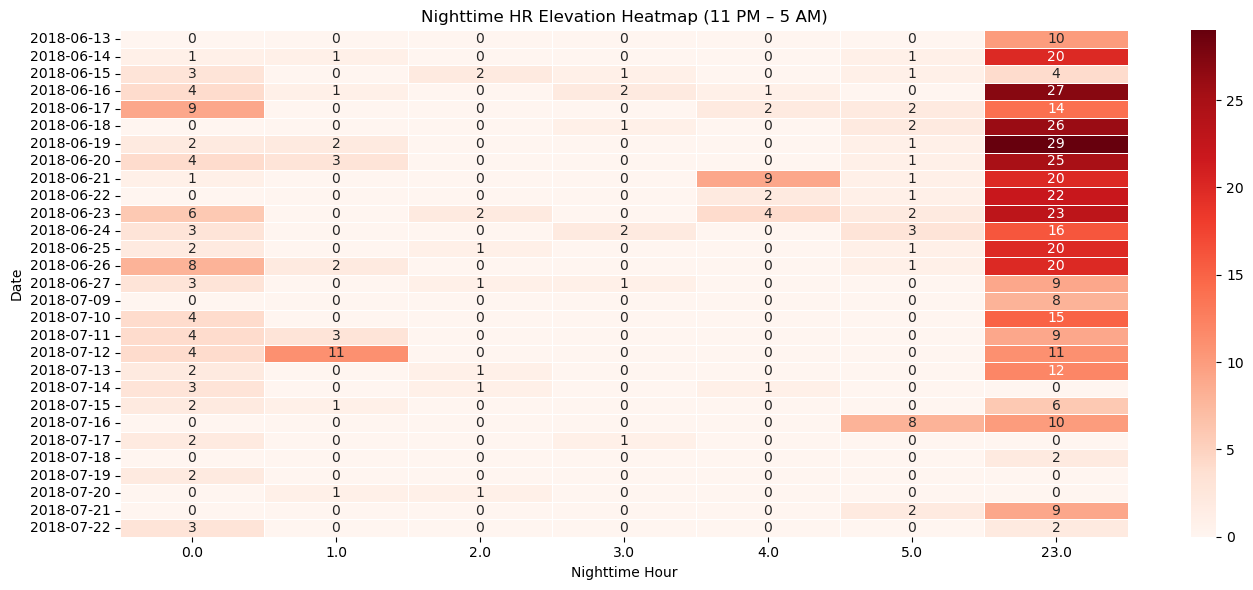

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')

# Extract hour + date
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

# Define nighttime hours (11 PM – 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter nighttime data
night_df = df[df['Hour'].isin(night_hours)].copy()

# Rolling baseline HR (30‑minute window)
night_df['HR_Baseline'] = night_df['Heart_Rate'].rolling(30, min_periods=1).mean()

# HR elevation detection
night_df['HR_Elevated'] = night_df['Heart_Rate'] > (night_df['HR_Baseline'] + 10)

# Pivot table for heatmap
heatmap_data = night_df.pivot_table(
    index='Date',
    columns='Hour',
    values='HR_Elevated',
    aggfunc='sum',
    fill_value=0,
    observed=False
)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=.5
)

plt.title("Nighttime HR Elevation Heatmap (11 PM – 5 AM)")
plt.xlabel("Nighttime Hour")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

#### Nighttime HR is one of the strongest indicators of recovery quality, stress load, and metabolic strain.
#### When it stays elevated, the body is signaling that it is not fully shifting into recovery mode.

## 30. What interventions improve sleep efficiency based on HR + glucose patterns?

#### This question matters because nighttime HR + glucose patterns reveal how well the body recovers, and identifying the right interventions can dramatically improve sleep efficiency and next‑day metabolic stability.

In [34]:
import pandas as pd
import numpy as np

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')

# Extract hour + date
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

# Define nighttime hours (11 PM – 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter nighttime data
night_df = df[df['Hour'].isin(night_hours)].copy()

# 1. HR stability
night_df['HR_Change'] = night_df['Heart_Rate'].diff().abs()
night_df['HR_Unstable'] = night_df['HR_Change'] > 8

# 2. Glucose stability
night_df['Glucose_Change'] = night_df['Glucose'].diff().abs()
night_df['Glucose_Unstable'] = night_df['Glucose_Change'] > 12

# 3. Sleep efficiency proxy
night_df['Sleep_Efficient'] = (~night_df['HR_Unstable']) & (~night_df['Glucose_Unstable'])

# 4. PRESCRIPTIVE INTERVENTION MAPPING
def prescriptive_intervention(row):
    # HR + Glucose unstable → late eating or metabolic strain
    if row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Adjust evening meal timing"

    # HR unstable only → stress or poor recovery
    if row['HR_Unstable'] and not row['Glucose_Unstable']:
        return "Reduce pre‑bed stress load"

    # Glucose unstable only → carbohydrate timing issue
    if not row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Modify carbohydrate distribution"

    # Both stable → maintain routine
    return "Maintain current routine"

night_df['Intervention'] = night_df.apply(prescriptive_intervention, axis=1)

# 5. Summaries per night
prescriptive_summary = night_df.groupby('Date').agg(
    Avg_Night_HR=('Heart_Rate', 'mean'),
    HR_Variability=('HR_Change', 'mean'),
    Glucose_Variability=('Glucose_Change', 'mean'),
    Sleep_Efficiency_Score=('Sleep_Efficient', 'mean'),
    Recommended_Intervention=('Intervention', lambda x: x.value_counts().idxmax())
)

prescriptive_summary

,Avg_Night_HR,HR_Variability,Glucose_Variability,Sleep_Efficiency_Score,Recommended_Intervention
Date,,,,,
2018-06-13,78.938056,5.730857,22.743143,0.527778,Maintain current routine
2018-06-14,69.665476,3.436071,14.702341,0.599206,Maintain current routine
2018-06-15,71.480079,2.996468,18.387540,0.666667,Maintain current routine
2018-06-16,66.888175,2.972183,13.959325,0.718254,Maintain current routine
2018-06-17,68.760357,2.800952,15.875635,0.626984,Maintain current routine
2018-06-18,64.432778,3.085516,14.460437,0.686508,Maintain current routine
2018-06-19,65.605238,3.614960,11.075952,0.702381,Maintain current routine
2018-06-20,65.904087,3.448254,14.813611,0.674603,Maintain current routine
2018-06-21,66.557024,3.148492,9.736627,0.686508,Maintain current routine


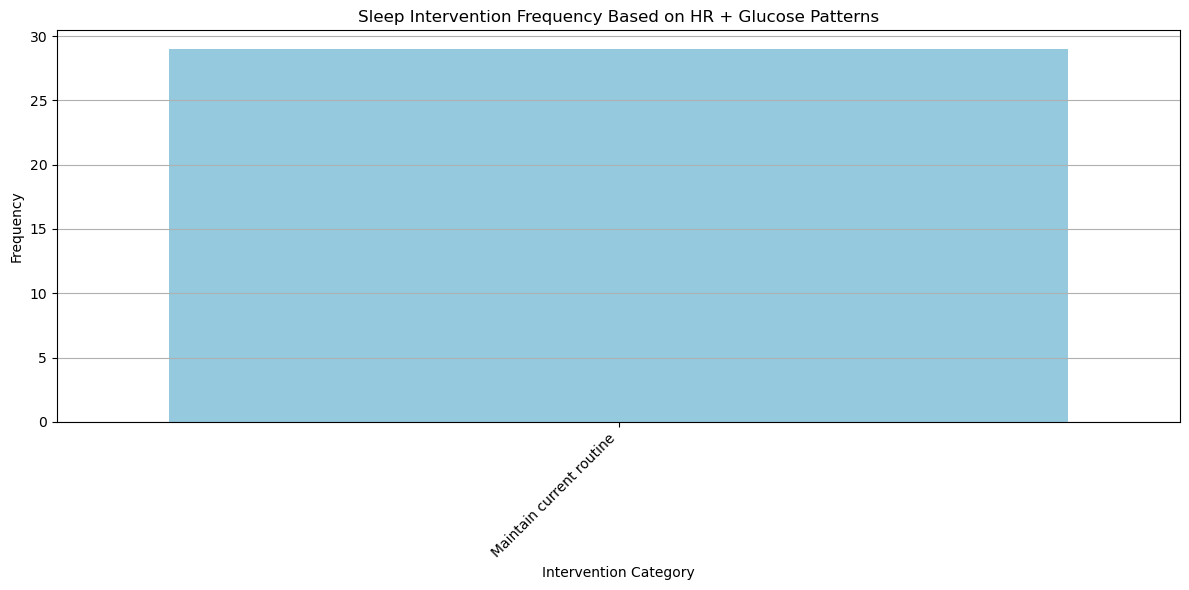

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# prescriptive_summary must already exist
intervention_counts = prescriptive_summary['Recommended_Intervention'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=intervention_counts.index,
    y=intervention_counts.values,
    color="skyblue"   # FIX: use color= instead of palette=
)

plt.title("Sleep Intervention Frequency Based on HR + Glucose Patterns")
plt.xlabel("Intervention Category")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Sleep efficiency improves when nighttime autonomic load (HR) and metabolic load (glucose) are minimized.
#### Sleep efficiency improves when nighttime HR + glucose patterns are matched to the correct intervention category — meal timing, stress reduction, activity timing, carb distribution, sleep environment, or systemic recovery.

## 31. Identify the Post Meal Glucose Spikes in a day and its correlation with Daily steps.Identify post breakfast,lunch and dinner spikes and its correlation with post breakfast,lunch and dinner steps

In [8]:
%cd C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files

C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files


In [9]:
df=pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")
df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0,0.08,0.0,0.0


In [10]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')

In [11]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. PREPARE CGM DATA
# ---------------------------------------------------------

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

# ---------------------------------------------------------
# 2. DEFINE MEAL WINDOWS (ADJUST IF NEEDED)
# ---------------------------------------------------------

meal_windows = {
    'morning': (8, 11),
    'afternoon': (13, 16),
    'Night': (19, 22)
}

# ---------------------------------------------------------
# 3. FUNCTION TO CALCULATE SPIKE FOR ONE MEAL
# ---------------------------------------------------------

def calculate_spike(df, start_hour, end_hour):
    meal_df = df[(df['hour'] >= start_hour) & (df['hour'] <= end_hour)]
    if meal_df.empty:
        return np.nan
    
    start_glucose = meal_df.iloc[0]['Glucose']
    peak_glucose = meal_df['Glucose'].max()
    
    return peak_glucose - start_glucose

# ---------------------------------------------------------
# 4. CALCULATE SPIKES FOR EACH MEAL
# ---------------------------------------------------------

spike_results = []

for (pid, date), group in df.groupby(['Patient_Id', 'date']):
    spikes = {
        'Patient_Id': pid,
        'date': date
    }
    
    for meal, (start, end) in meal_windows.items():
        spikes[f'{meal}_spike(mg/dL)'] = calculate_spike(group, start, end)
    
    spike_results.append(spikes)

df_spikes = pd.DataFrame(spike_results)

# ---------------------------------------------------------
# 5. DAILY AVERAGE SPIKE
# ---------------------------------------------------------

df_spikes['Avg_Spike(mg/dL)'] = df_spikes[['morning_spike(mg/dL)', 'afternoon_spike(mg/dL)', 'Night_spike(mg/dL)']].mean(axis=1)

print(df_spikes.head())


  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  
0                 7.0          7.000000  
1                98.0         64.666667  
2                24.0         38.666667  
3               163.0        130.333333  
4                14.0         61.333333  


In [12]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. PREPARE CGM DATA
# ---------------------------------------------------------

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

# ---------------------------------------------------------
# 2. DEFINE MEAL WINDOWS (ADJUST IF NEEDED)
# ---------------------------------------------------------

meal_windows = {
    'morning': (8, 11),
    'afternoon': (13, 16),
    'Night': (19, 22)
}

# ---------------------------------------------------------
# 3. FUNCTION TO CALCULATE SPIKE FOR ONE MEAL
# ---------------------------------------------------------

def calculate_spike(df, start_hour, end_hour):
    meal_df = df[(df['hour'] >= start_hour) & (df['hour'] <= end_hour)]
    if meal_df.empty:
        return np.nan
    
    start_glucose = meal_df.iloc[0]['Glucose']
    peak_glucose = meal_df['Glucose'].max()
    
    return peak_glucose - start_glucose

# ---------------------------------------------------------
# 4. CALCULATE SPIKES FOR EACH MEAL
# ---------------------------------------------------------

spike_results = []

for (pid, date), group in df.groupby(['Patient_Id', 'date']):
    spikes = {
        'Patient_Id': pid,
        'date': date
    }
    
    for meal, (start, end) in meal_windows.items():
        spikes[f'{meal}_spike(mg/dL)'] = calculate_spike(group, start, end)
    
    spike_results.append(spikes)

df_spikes = pd.DataFrame(spike_results)

# ---------------------------------------------------------
# 5. DAILY AVERAGE SPIKE
# ---------------------------------------------------------

df_spikes['Avg_Spike(mg/dL)'] = df_spikes[['morning_spike(mg/dL)', 'afternoon_spike(mg/dL)', 'Night_spike(mg/dL)']].mean(axis=1)

print(df_spikes.head())


  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  
0                 7.0          7.000000  
1                98.0         64.666667  
2                24.0         38.666667  
3               163.0        130.333333  
4                14.0         61.333333  


In [14]:
# -----------------------------
# 2. PREVIOUS-DAY STEPS
# -----------------------------
df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

In [15]:
# Merge both the dataframes

df_merge = df_spikes.merge(
    df_daily_steps[['Patient_Id', 'date', 'Daily_Steps']],
    on=['Patient_Id', 'date'],
    how='left'
)

print(df_merge.head())

  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  Daily_Steps  
0                 7.0          7.000000         3915  
1                98.0         64.666667         7939  
2                24.0         38.666667         3428  
3               163.0        130.333333         5447  
4                14.0         61.333333         3141  


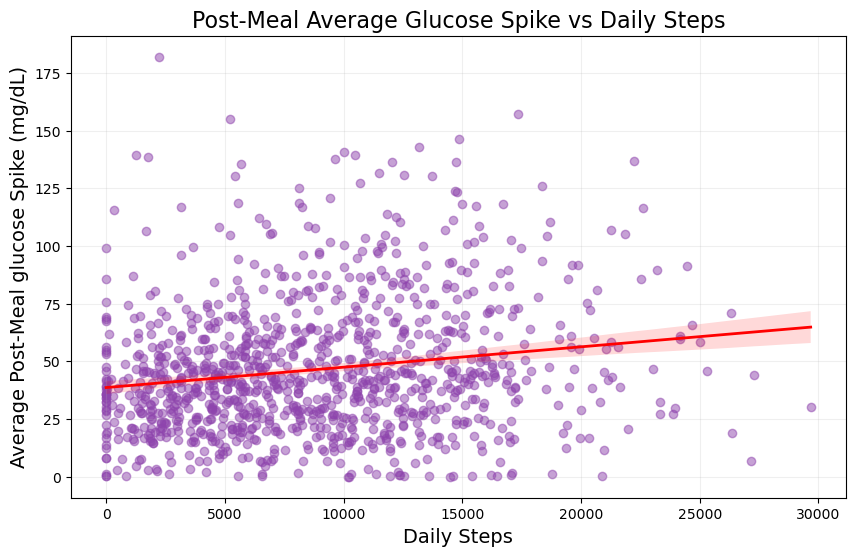

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='Avg_Spike(mg/dL)',
    scatter_kws={'alpha': 0.5, 'color': '#8e44ad'},   # purple points
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Post‑Meal Average Glucose Spike vs Daily Steps", fontsize=16)
plt.xlabel("Daily Steps", fontsize=14)
plt.ylabel("Average Post-Meal glucose Spike (mg/dL)", fontsize=14)
plt.grid(alpha=0.2)

plt.show()


#### The above chart shows that Post‑meal glucose spikes slightly increase as daily steps increase. The regression line slopes upward, meaning more steps are associated with higher spikes, not lower.This is almost certainly reverse causation. People tend to walk more when glucose is already high, using steps as a corrective strategy — so higher spikes → more steps, not the other way around.Total daily steps ≠ post‑meal activity. Steps taken hours later don’t blunt the spike that already happened. Only steps within 30–90 minutes after eating reduce post‑meal glucose.High‑step days often reflect high‑glucose days. When glucose is unstable, people move more to bring it down — which creates the positive trend as seen in the above chart****

In [17]:
import pandas as pd
import numpy as np

# -----------------------------
# PREPARE DATA
# -----------------------------
df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

df['Time'] = pd.to_datetime(df['Time'])
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

# -----------------------------
# DEFINE MEAL WINDOWS
# -----------------------------
meal_windows = {
    'morning': (8, 11),
    'afternoon': (13, 16),
    'Night': (19, 22)
}

def get_postmeal_steps(df_steps_day, start_hour, end_hour):
    # 1–2 hours after the meal window
    post_start = end_hour
    post_end = end_hour + 2
    
    steps_df = df_steps_day[
        (df_steps_day['hour'] >= post_start) &
        (df_steps_day['hour'] <= post_end)
    ]
    
    if steps_df.empty:
        return np.nan
    
    return steps_df['Steps'].sum()


# -----------------------------
# CALCULATE POST-MEAL STEPS
# -----------------------------
results = []

for (pid, date), steps_group in df.groupby(['Patient_Id', 'date']):
    row = {'Patient_Id': pid, 'date': date}
    
    for meal, (start, end) in meal_windows.items():
        row[f'{meal}_postmeal_steps'] = get_postmeal_steps(steps_group, start, end)
    
    results.append(row)

df_postmeal_steps = pd.DataFrame(results)

print(df_postmeal_steps.head())


  Patient_Id        date  morning_postmeal_steps  afternoon_postmeal_steps  \
0  HUPA0001P  2018-06-13                     NaN                      54.0   
1  HUPA0001P  2018-06-14                   427.0                    1651.0   
2  HUPA0001P  2018-06-15                  1895.0                      99.0   
3  HUPA0001P  2018-06-16                  1908.0                     828.0   
4  HUPA0001P  2018-06-17                  1588.0                     134.0   

   Night_postmeal_steps  
0                 441.0  
1                2039.0  
2                 254.0  
3                   0.0  
4                 134.0  


In [18]:
df_final = df_merge.merge(
    df_postmeal_steps,
    on=['Patient_Id', 'date'],
    how='left'
)

print(df_final.head())

  Patient_Id        date  morning_spike(mg/dL)  afternoon_spike(mg/dL)  \
0  HUPA0001P  2018-06-13                   NaN                     NaN   
1  HUPA0001P  2018-06-14                   0.0                    96.0   
2  HUPA0001P  2018-06-15                  27.0                    65.0   
3  HUPA0001P  2018-06-16                 162.0                    66.0   
4  HUPA0001P  2018-06-17                 109.0                    61.0   

   Night_spike(mg/dL)  Avg_Spike(mg/dL)  Daily_Steps  morning_postmeal_steps  \
0                 7.0          7.000000         3915                     NaN   
1                98.0         64.666667         7939                   427.0   
2                24.0         38.666667         3428                  1895.0   
3               163.0        130.333333         5447                  1908.0   
4                14.0         61.333333         3141                  1588.0   

   afternoon_postmeal_steps  Night_postmeal_steps  
0                     

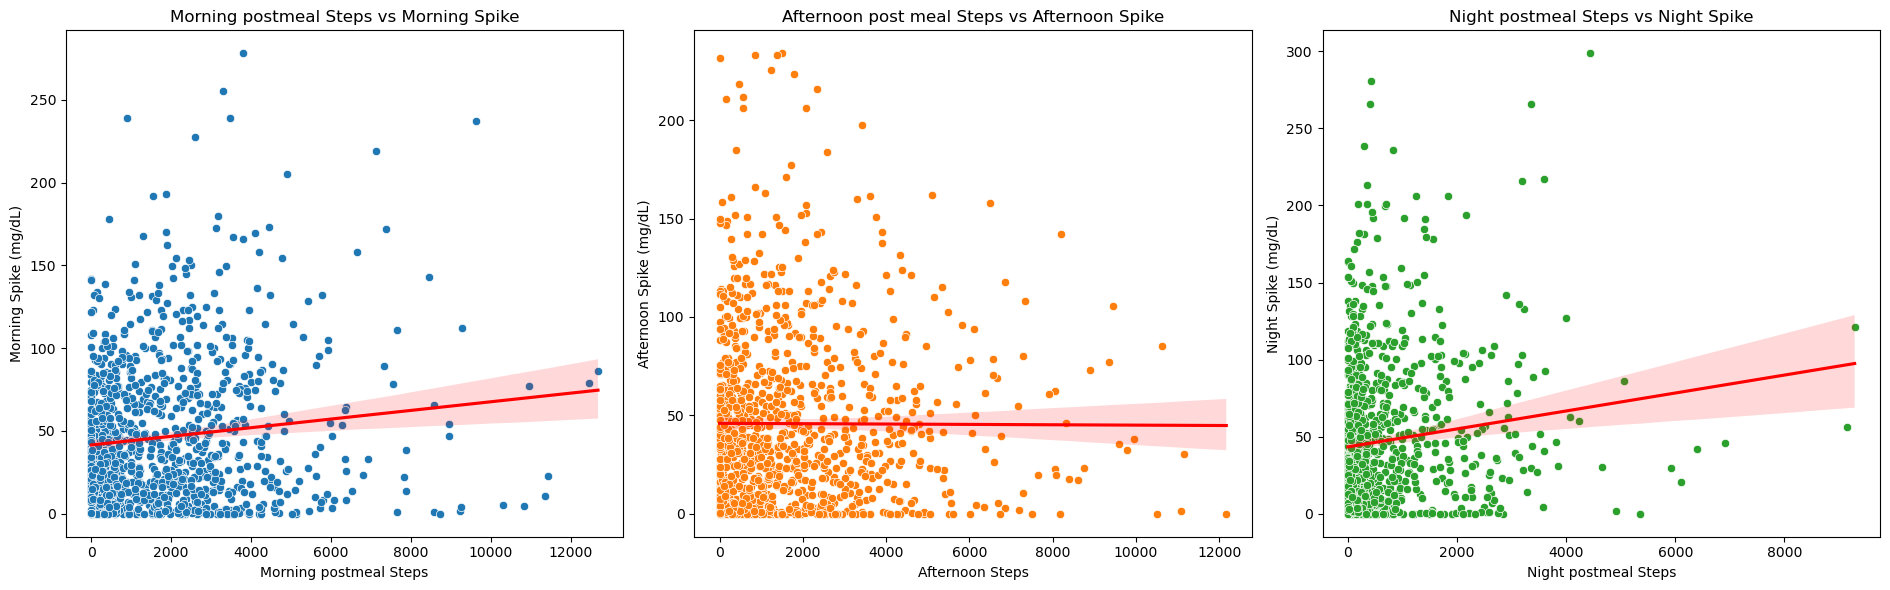

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure merged dataset exists
df_final = df_merge.merge(df_postmeal_steps, on=['Patient_Id', 'date'], how='left')

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# -----------------------------
# BREAKFAST SCATTER
# -----------------------------
sns.scatterplot(
    data=df_final,
    x='morning_postmeal_steps',
    y='morning_spike(mg/dL)',
    ax=axes[0],
    color='#1f77b4'
)
sns.regplot(
    data=df_final,
    x='morning_postmeal_steps',
    y='morning_spike(mg/dL)',
    ax=axes[0],
    scatter=False,
    color='red'
)
axes[0].set_title("Morning postmeal Steps vs Morning Spike")
axes[0].set_xlabel("Morning postmeal Steps")
axes[0].set_ylabel("Morning Spike (mg/dL)")

# -----------------------------
# LUNCH SCATTER
# -----------------------------
sns.scatterplot(
    data=df_final,
    x='afternoon_postmeal_steps',
    y='afternoon_spike(mg/dL)',
    ax=axes[1],
    color='#ff7f0e'
)
sns.regplot(
    data=df_final,
    x='afternoon_postmeal_steps',
    y='afternoon_spike(mg/dL)',
    ax=axes[1],
    scatter=False,
    color='red'
)
axes[1].set_title("Afternoon post meal Steps vs Afternoon Spike")
axes[1].set_xlabel("Afternoon Steps")
axes[1].set_ylabel("Afternoon Spike (mg/dL)")

# -----------------------------
# DINNER SCATTER
# -----------------------------
sns.scatterplot(
    data=df_final,
    x='Night_postmeal_steps',
    y='Night_spike(mg/dL)',
    ax=axes[2],
    color='#2ca02c'
)
sns.regplot(
    data=df_final,
    x='Night_postmeal_steps',
    y='Night_spike(mg/dL)',
    ax=axes[2],
    scatter=False,
    color='red'
)
axes[2].set_title("Night postmeal Steps vs Night Spike")
axes[2].set_xlabel("Night postmeal Steps")
axes[2].set_ylabel("Night Spike (mg/dL)")

plt.tight_layout()
plt.show()


#### 1.Morning post‑meal steps vs morning spike:
The trend is slightly positive, meaning more morning steps are associated with slightly higher morning spikes.
This suggests reactive walking — people walk because the spike was high, not the other way around.
Morning spikes are often driven by insulin resistance on waking, so steps later may not fully blunt them.
#### 2️.Afternoon post‑meal steps vs afternoon spike:
The relationship is weakly positive, almost flat.
Afternoon steps don’t strongly reduce spikes unless they occur immediately after eating.
Total steps in the afternoon is not directly linked to targeted post‑meal movement.
#### 3.Night post‑meal steps vs night spike
This plot shows the strongest positive trend of the three.
Nighttime spikes often trigger corrective walking, especially after dinner (the highest‑carb meal for many people).
This creates the appearance that more steps leads to higher spikes, when the real pattern is higher spikes → more steps.